# 11 · Apprentissage et raisonnement — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch11_raisonnement/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 11.Q1 à 11.Q12, 11.R1 à 11.R3, 11.1, 11.3, 11.5 à 11.8, 11.10 | vérifier tes réponses courtes | 🧠 🔁 ✏️ 📈 | ★ à ★★ | |
| A | 11.13 | Glouton pur sur trois bras : que va-t-il se passer ? | 🔮 | ★ | 10 |
| B | 11.14 | Holmes déduit-il ? Compter et citer le vocabulaire du raisonnement | 🔨 | ★★ | 25 |
|  | 11.15 | Valider un syllogisme par force brute : 256 mondes de Venn | 🔨 | ★★ | 30 |
|  | 11.16 | Reproduire la figure 11.5 : les cinq sophismes en diagrammes | 🎨 | ★★ | 25 |
| C | 11.17 | Généralisation hâtive et échantillon biaisé chez les manchots | 🔬 | ★★ | 25 |
|  | 11.18 | Des points sur un cercle : quand le modèle trahit l'induction | 🔬 | ★★ | 25 |
| D | 11.19 | BernoulliBandit et GaussianBandit | 🔨 | ★★ | 20 |
|  | 11.20 | argmax_random_tie, epsilon_greedy_action et incremental_update | 🔨 | ★★ | 25 |
|  | 11.21 | run_bandit : la boucle d'interaction et ses courbes | 🔨 | ★★★ | 40 |
|  | 11.22 | Initialisation optimiste sans ε : prédire, puis mesurer | 🔮 | ★★★ | 30 |
|  | 11.23 | ucb_action et thompson_action | 🔨 | ★★★ | 40 |
| E | 11.24 | Bandit piégé : l'agent qui n'explore jamais | 🐛 | ★★★ | 30 |
|  | 11.25 | Un journal d'expériences reproductible (JSON) | 🛠️ | ★★★ | 30 |
|  | 11.26 | Tournoi : ε-greedy, optimiste, UCB et Thompson | 🔬 | ★★★ | 45 |
|  | 11.27 | Défi : battre UCB1 sur un banc de bandits de Bernoulli | 🏆 | ★★★ | 60 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Compter et citer un vocabulaire dans un corpus, en repérant les faux positifs.
- Vérifier la validité d'un syllogisme par une recherche exhaustive de contre-exemple.
- Mesurer ce que coûtent un petit échantillon et un échantillon biaisé.
- Programmer un bandit manchot et les stratégies ε-greedy, UCB et Thompson, puis les comparer équitablement par leur regret.
- Journaliser une expérience pour pouvoir la refaire.

**Rappel express.** Un syllogisme est valide si aucun monde ne rend ses prémisses vraies et sa conclusion fausse (8 régions de Venn, $2^8 = 256$ mondes) ; erreur type d'une proportion : $\sqrt{p(1-p)/n}$ ; moyenne incrémentale : $Q \leftarrow Q + \frac{1}{n}(R - Q)$ ; ε-greedy : le meilleur bras avec la probabilité $1 - \varepsilon + \varepsilon/K$ ; UCB : $\arg\max_a Q(a) + c\sqrt{\ln t / N(a)}$, bras jamais tirés d'abord ; Thompson : tirer $\theta_a \sim \mathrm{Beta}(1 + s_a, 1 + f_a)$ et jouer le plus grand ; pseudo-regret : $\sum_t (q_* - q_*(A_t))$. En Python : `re`, `collections.Counter`, `itertools.product`, `json`, `rng.beta`, `np.flatnonzero`.

## Partie 0 · Vérifier tes réponses courtes (quiz, rappels, ✏️ 11.1, 11.3, 11.5 à 11.8 et 📈 11.10)

Fais d'abord les quiz, les rappels et les exercices de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse courte ici : **la valeur** que tu as trouvée, pas l'expression Python, sinon tu ne vérifies rien. Un nombre : `42` ou `0.375` (en Python, le séparateur décimal est un **point** ; `0,375` sans guillemets serait un couple de deux nombres) ; un vrai ou faux : `True` ou `False` ; un choix : la lettre seule, entre guillemets (`"E"`) ; plusieurs choix : les lettres collées (`"AC"`) ou séparées par des virgules ; une suite de codes, une lettre par situation (`"IDDI"` ou `"I, D, D, I"`) ; plusieurs nombres : une liste (`[2, 5]`). Les réponses pas encore remplies affichent ⏳. Les questions « dans ta copie », l'exercice 11.4, la preuve ∂ 11.2, la réflexion (🗣️ ⚖️ 📄) et l'entretien se corrigent avec `05_solutions.md`.

In [2]:
# The short answers only use the numbers of their statements (02_exercices.md)
import math

import numpy as np

# 11.5: the lighthouse; clue k clears these suspects (A Anne, B Bastien, C Chloé, D Diego, E Elsa, F Félix)
SUSPECTS_105 = "ABCDEF"
CLEARED_105 = {1: "CE", 2: "D", 3: "F", 4: "A"}


def remaining_105(after):
    """The suspects not cleared by clues 1 to `after`, in alphabetical order."""
    left = set(SUSPECTS_105)
    for clue in range(1, after + 1):
        left -= set(CLEARED_105[clue])
    return "".join(sorted(left))


# 11.6: 2,000 apples, 300 of them ripe; a basket of 40 apples drawn at random, 6 of them ripe
P_RIPE_106 = 300 / 2000
P_BASKET_106 = 6 / 40
SE_BASKET_106 = math.sqrt(P_BASKET_106 * (1 - P_BASKET_106) / 40)

# 11.8: the epsilon-greedy trace (arms 0, 1, 2; ties go to the smallest index)
EPS_108 = 0.2
MEANS_108 = np.array([0.3, 0.5, 0.8])
U_108 = [0.65, 0.12, 0.47, 0.83, 0.05, 0.71, 0.38, 0.91]
RANDOM_ARM_108 = [1, 2, 0, 1, 1, 2, 0, 1]
REWARD_108 = [0, 1, 1, 0, 1, 0, 1, 1]


def trace_108():
    """(arm, estimates, counts) after each of the 8 steps, with sample averages."""
    q, n, history = np.zeros(3), np.zeros(3, dtype=int), []
    for u, random_arm, reward in zip(U_108, RANDOM_ARM_108, REWARD_108):
        arm = random_arm if u < EPS_108 else int(np.argmax(q))      # np.argmax: the smallest index on ties
        n[arm] += 1
        q[arm] += (reward - q[arm]) / n[arm]
        history.append((arm, q.copy(), n.copy()))
    return history


TRACE_108 = trace_108()
ARMS_108 = [arm for arm, _, _ in TRACE_108]
PSEUDO_REGRET_108 = float(sum(MEANS_108.max() - MEANS_108[arm] for arm in ARMS_108))

**11.Q1 — Représentation, évaluation, optimisation : associer**

In [3]:
wb.record("11.Q1a", "OEROER", mistakes={"élément 5 (la vraisemblance) : mauvaise case ; relis la question que règle chaque ingrédient, dans le tableau du §11.2 de la fiche": "OEROOR",
          "élément 4 (l'algorithme de Lloyd) : mauvaise case ; demande-toi ce qu'il produit : une solution possible, un jugement sur une solution, ou une façon d'en trouver une ?": "OERRER",
          "élément 2 (l'erreur sur la validation) : mauvaise case ; un nombre calculé sur la validation modifie-t-il le modèle ?": "OOROER",
          "élément 6 (l'arbre de profondeur au plus 3) : mauvaise case ; relis la question que règle chaque ingrédient (fiche §11.2)": "OEROEO"})
wb.record("11.Q1b", "A", mistakes={"la mise à jour modifie les poids : c'est la méthode qui cherche, l'optimisation": "B",
          "l'hyperplan est ce que le perceptron peut exprimer : sa représentation": "C",
          "le pas règle la taille des corrections : il appartient à la méthode qui cherche": "D"})

WB_ANSWER {"hash": "90cdbbeb6e47ef49a1f8027f2c1277498074eb512d6446af9937f3f1f06b0953", "id": "11.Q1a", "kind": "str", "mistakes": {"05084100118b29bcc0ba3d4c8237927e7d1df19888e5dbd137e83fdb411abdb9": "élément 4 (l'algorithme de Lloyd) : mauvaise case ; demande-toi ce qu'il produit : une solution possible, un jugement sur une solution, ou une façon d'en trouver une ?", "0b1e1ad5ce39be37f90e72f1191dde57e8db0a5d0f8e75cf62a63c652a93c7ac": "élément 2 (l'erreur sur la validation) : mauvaise case ; un nombre calculé sur la validation modifie-t-il le modèle ?", "950357e5cf65504ed142ad9f8d629a1ce519a05a2a4c169d85d194cf64df95d7": "élément 5 (la vraisemblance) : mauvaise case ; relis la question que règle chaque ingrédient, dans le tableau du §11.2 de la fiche", "bc259811ff0bc64554765309bbb306ba3c4e5616e6dae76d05aad64d026f69e3": "élément 6 (l'arbre de profondeur au plus 3) : mauvaise case ; relis la question que règle chaque ingrédient (fiche §11.2)"}}
📝 Ex 11.Q1a : réponse enregistrée (str).
WB_A

**11.Q2 — Puissance de représentation : ce qu'un perceptron ne peut pas « savoir »**

In [4]:
wb.record("11.Q2a", "ACE", mistakes={"il te manque une règle : écris chaque frontière comme une équation (remplace « < » ou « > » par « = ») et regarde si elle est du premier degré en x₁ et x₂": "AC",
          "il te manque deux règles : une droite peut avoir n'importe quelle direction ; écris chaque frontière comme une équation": "A",
          "une règle de trop : pour chacune, dessine la zone de la classe 1, puis cherche une seule droite qui la sépare du reste du plan": "ACDE",
          "une règle de trop : écris chaque frontière comme une équation ; laquelle n'est pas du premier degré ?": "ABCE"})
wb.record("11.Q2b", "B", mistakes={"« de même signe », c'est x₁x₂ > 0 : x₁² et x₂² ne connaissent pas le signe de x₁ et de x₂, il faudrait la feature x₁x₂": "D",
          "une seule des deux règles devient représentable : écris chacune comme une somme pondérée des quatre entrées": "BD"})
wb.record("11.Q2c", False, mistakes={"plus de puissance, c'est aussi plus de risque de suivre le bruit des données d'entraînement : l'overfitting du ch. 9": True})

WB_ANSWER {"hash": "81374bf57a253e8dc49d634ae9738504a9345514183c74af724092919042d25b", "id": "11.Q2a", "kind": "str", "mistakes": {"138c2255114d05b3fb30c615989b62cdaec629740331bda7a2e9973f0bdb4e9a": "il te manque une règle : écris chaque frontière comme une équation (remplace « < » ou « > » par « = ») et regarde si elle est du premier degré en x₁ et x₂", "227c504689a262a1f041fac179198e46f3d10e16ddaba1d164bcb4c2950c3c2d": "une règle de trop : écris chaque frontière comme une équation ; laquelle n'est pas du premier degré ?", "33010751a14b332d49bc5d0e9497052f53d16b93c9bc673a5d5ccce951e26d3e": "il te manque deux règles : une droite peut avoir n'importe quelle direction ; écris chaque frontière comme une équation", "bfd81a14395cb35f23b345143e5a997d75dab46b7d338838f3c5393a4ee919e1": "une règle de trop : pour chacune, dessine la zone de la classe 1, puis cherche une seule droite qui la sépare du reste du plan"}}
📝 Ex 11.Q2a : réponse enregistrée (str).
WB_ANSWER {"hash": "50eed324b7b2838ffc5

**11.Q3 — Représentable mais pas apprenable : le problème de l'arrêt**

In [5]:
wb.record("11.Q3a", True, mistakes={"un programme précis, sur une entrée précise, s'arrête ou ne s'arrête pas : la réponse existe, même si on l'ignore": False})
wb.record("11.Q3b", True, mistakes={"c'est exactement le théorème de Turing (1936) : aucune méthode unique ne répond juste pour tous les couples": False})
wb.record("11.Q3c", False, mistakes={"pense à une boucle infinie écrite exprès : l'impossibilité porte sur une méthode qui marcherait pour tous les programmes": True})
wb.record("11.Q3d", False, mistakes={"il pourrait s'arrêter une seconde après qu'on a cessé d'attendre : observer ne prouve rien": True})
wb.record("11.Q3e", "B", mistakes={"chaque réponse tient en un oui ou un non : dans les boîtes du livre, la fonction est représentable": "A",
          "même avec des ressources illimitées, aucun algorithme ne la calcule partout : ce n'est pas une question de moyens": "C",
          "aucun algorithme ne la calcule partout, donc aucun ne l'apprend exactement": "D"})

WB_ANSWER {"hash": "4f30aa7f43fa54f676427bd790cb71598d8fd1e9c3e597b7d97a52936ab54888", "id": "11.Q3a", "kind": "bool", "mistakes": {"677f1f29b2063c441e1f17af44de4e2ae390246b81b29c1a0cc90c9eedd6eb71": "un programme précis, sur une entrée précise, s'arrête ou ne s'arrête pas : la réponse existe, même si on l'ignore"}}
📝 Ex 11.Q3a : réponse enregistrée (bool).
WB_ANSWER {"hash": "d21ef5aebb478fb41fe2ba86864243e39ed6897bbe860bc7bd32aa71bd3ba3d4", "id": "11.Q3b", "kind": "bool", "mistakes": {"376e617bdcb2b1f925f2562136bb7f4e56f503748c8b08568142d7ea737729a7": "c'est exactement le théorème de Turing (1936) : aucune méthode unique ne répond juste pour tous les couples"}}
📝 Ex 11.Q3b : réponse enregistrée (bool).
WB_ANSWER {"hash": "ab886119ca909018243c923bb3d6e4918ad66a7313918cf5c15344255c2d76d1", "id": "11.Q3c", "kind": "bool", "mistakes": {"2aca885baa34e5274a031d12efcee1660142e70fe57e7ef9d0a6d3a63984e7ae": "pense à une boucle infinie écrite exprès : l'impossibilité porte sur une méthode qui 

**11.Q4 — Loss, métrique, objectif : qui sert à quoi ?**

In [6]:
wb.record("11.Q4a", "LMOM", mistakes={"élément 4 (la precision sur la validation) : mauvaise case ; l'optimiseur s'en sert-il pendant l'entraînement ?": "LMOL",
          "élément 1 (la cross-entropy) : mauvaise case ; relis l'élément : que fait la descente de gradient avec elle ?": "MMOM",
          "élément 2 (le recall sur le test) : mauvaise case ; relis la différence entre une métrique et un objectif (fiche §11.2.2)": "LOOM",
          "élément 3 (diviser les fraudes par deux) : mauvaise case ; relis la différence entre une métrique et un objectif (fiche §11.2.2)": "LMMM"})
wb.record("11.Q4b", "A", mistakes={"l'accuracy se calcule en un passage sur les données : c'est sa forme qui gêne l'optimiseur": "B",
          "elle dépend bien des poids, mais par sauts : une petite modification ne change aucune prédiction": "C",
          "une accuracy est une proportion de bonnes réponses, entre 0 et 1": "D"})
wb.record("11.Q4c", "B", mistakes={"l'accuracy compte toutes les bonnes réponses, fraudes et transactions normales confondues": "A",
          "le recall part des vraies fraudes (quelle part en est détectée ?) ; relis le souhait : de quoi part-il ?": "C",
          "le taux de faux négatifs compte les fraudes manquées : est-ce de cela que parle le souhait ?": "D"})
wb.record("11.Q4d", "C", mistakes={"la precision part des alertes données (quelle part est justifiée ?) ; relis le souhait : de quoi part-il ?": "B",
          "l'accuracy mélange les deux classes, et la fraude est rare : un modèle qui ne détecte rien a une accuracy très élevée": "A",
          "le taux de faux négatifs mesure ce qu'on veut rendre petit, pas ce qu'on veut rendre grand": "D"})

WB_ANSWER {"hash": "5c52ca0e7fc4180b78c8ecc7dff469e56b0ffb998ba5f926b3e58eb2893d13b0", "id": "11.Q4a", "kind": "str", "mistakes": {"1dc4928d6c705e2de5c6c2d45ee59b6d5c1054e1a8577037103a1d0afbc34558": "élément 4 (la precision sur la validation) : mauvaise case ; l'optimiseur s'en sert-il pendant l'entraînement ?", "aa28b02865c5cfd2c09464c18381fab95756855fd0eecc2d8111899361c93bab": "élément 3 (diviser les fraudes par deux) : mauvaise case ; relis la différence entre une métrique et un objectif (fiche §11.2.2)", "d161239762e1556a90f4b2568be7f8fcf906a4cb8ab6c2e2d942e8b2023310b1": "élément 2 (le recall sur le test) : mauvaise case ; relis la différence entre une métrique et un objectif (fiche §11.2.2)", "f6f2b982aa0efed82a74777f9fe541d0f060c53995414913bb0f01b809bbbf2f": "élément 1 (la cross-entropy) : mauvaise case ; relis l'élément : que fait la descente de gradient avec elle ?"}}
📝 Ex 11.Q4a : réponse enregistrée (str).
WB_ANSWER {"hash": "c1b71d2b34a3ee9c44bcc727aa303e145214b795e58a3d0876

**11.Q5 — Optimiser n'est pas être optimal ; pas de repas gratuit**

In [7]:
wb.record("11.Q5a", False, mistakes={"chaque pas améliore, mais l'optimiseur peut s'arrêter dans un minimum local (ch. 5)": True})
wb.record("11.Q5b", False, mistakes={"le théorème fait la moyenne sur tous les problèmes possibles ; un problème réel a une structure, qu'un algorithme adapté exploite": True})
wb.record("11.Q5c", "B", mistakes={"le théorème dit que tout se vaut en moyenne sur tous les problèmes possibles, pas sur le tien : on peut choisir": "A",
          "le théorème dit justement qu'aucune famille de modèles ne gagne partout": "C",
          "récent ne veut pas dire adapté : seule une comparaison sur tes données le dira": "D"})

WB_ANSWER {"hash": "b5726bc996912c2348746e71f34bdc60c06201237fb26c3d62c1811da6edc8e4", "id": "11.Q5a", "kind": "bool", "mistakes": {"80f04f3430ba5de986c8178c3b85127df587b8cfe381cdcd1931a9b79603ef5d": "chaque pas améliore, mais l'optimiseur peut s'arrêter dans un minimum local (ch. 5)"}}
📝 Ex 11.Q5a : réponse enregistrée (bool).
WB_ANSWER {"hash": "ce9d81ebab620756bd2265845bd087b5c3aedf44e2764113ba93ab319391365b", "id": "11.Q5b", "kind": "bool", "mistakes": {"95ec6c8cc73ee79fdbef9b46ae3c1e1f25ae544b4c66a01dcb32e2514c93b219": "le théorème fait la moyenne sur tous les problèmes possibles ; un problème réel a une structure, qu'un algorithme adapté exploite"}}
📝 Ex 11.Q5b : réponse enregistrée (bool).
WB_ANSWER {"hash": "528b0d9ef76d85e067ac5f73c7d9d613eb13e37804d0fe954cc101128df0a779", "id": "11.Q5c", "kind": "str", "mistakes": {"81c82523039f6fb2cb8d8bee6c07ac24837cf10c7997377595fce9f8d85a91e7": "le théorème dit justement qu'aucune famille de modèles ne gagne partout", "f1e487dce2adcf8f4da

**11.Q6 — Déduction ou induction ? Six situations**

In [8]:
wb.record("11.Q6a", "IDIIDD", mistakes={"situation 3 : 140 faces en 200 lancers rendent-elles le trucage certain, ou seulement très probable ?": "IDDIDD",
          "situation 4 : trois décembres de hausse garantissent-ils le quatrième ?": "IDIDDD",
          "situation 1 : qu'est-ce qu'un entraînement tire des 50 000 e-mails étiquetés, et cette conclusion peut-elle être fausse ?": "DDIIDD",
          "situation 6 : si les deux prémisses sont vraies, la conclusion sur XOR peut-elle être fausse ?": "IDIIDI"})

WB_ANSWER {"hash": "fa9aa52dd881624280250abae573553af225ffe28c872dbb80dc9de64f71ce59", "id": "11.Q6a", "kind": "str", "mistakes": {"36011c91db0afbcae6e969d6d0a3e374c97bbaa84a61cafad92c79287e653d98": "situation 1 : qu'est-ce qu'un entraînement tire des 50 000 e-mails étiquetés, et cette conclusion peut-elle être fausse ?", "d4ef0e3926ad5b88f11d770d47f6b963e4940a991fbe24caefe3fd80eb748f02": "situation 4 : trois décembres de hausse garantissent-ils le quatrième ?", "d5e1bb4aa4ad97026ce838c137c8140bc057d2d6608c2b3acaed0a5b49a4da4a": "situation 6 : si les deux prémisses sont vraies, la conclusion sur XOR peut-elle être fausse ?", "e54bf0a777a4e0c128d40054cef9cd94c7eb31ae7d2b86a4cabf5b995187dc64": "situation 3 : 140 faces en 200 lancers rendent-elles le trucage certain, ou seulement très probable ?"}}
📝 Ex 11.Q6a : réponse enregistrée (str).


**11.Q7 — Valide, solide, ou ni l'un ni l'autre ?**

In [9]:
wb.record("11.Q7a", "SVNVNN", mistakes={"syllogisme 2 : vérifie aussi chaque prémisse dans le monde réel, pas seulement la forme": "SSNVNN",
          "syllogisme 2 : la validité ne dépend que de la forme ; relis la définition de « valide » (fiche §11.4)": "SNNVNN",
          "syllogisme 4 : vérifie aussi chaque prémisse dans le monde réel (un seul nombre suffit à réfuter une règle)": "SVNSNN",
          "syllogisme 5 : vérifie la forme avec les quatre règles de distribution (encadré 🧮 du §11.4)": "SVNVVN",
          "syllogisme 6 : compare-le aux quatre formes du syllogisme conditionnel (fiche §11.4)": "SVNVNV",
          "syllogisme 1 : relis la définition de « solide » (fiche §11.4), puis vérifie ses deux prémisses": "VVNVNN"})
wb.record("11.Q7b", True, mistakes={"la validité tient à la forme : une forme invalide peut tomber sur une conclusion vraie, par chance (le tableau des sophismes de la fiche en donne un)": False})

WB_ANSWER {"hash": "6a116d6d77fb3ef22b7c7a794b0212a5b6c10a6179d541414cbfd942da81dc1a", "id": "11.Q7a", "kind": "str", "mistakes": {"3f4e286afa61937ffbddeceb6a3328f2baff2d316f9a548121255a2d4900ade9": "syllogisme 1 : relis la définition de « solide » (fiche §11.4), puis vérifie ses deux prémisses", "6305a3a19b12925c362358a4e6bca2b95ec192682b28bdfb2e7bc2992c160c54": "syllogisme 4 : vérifie aussi chaque prémisse dans le monde réel (un seul nombre suffit à réfuter une règle)", "8bbe6d45543010ac33bfcb35e41dfb771c2607c869d7b359115b99f60bec634d": "syllogisme 5 : vérifie la forme avec les quatre règles de distribution (encadré 🧮 du §11.4)", "a45233c3fba900512f5a49a4e9ed9948688fb1178bff6fd34381f7634e4eef9d": "syllogisme 6 : compare-le aux quatre formes du syllogisme conditionnel (fiche §11.4)", "ac0c45cc89bb1b011f5ae23dadb534b6fb6ba1a8fb141a8422b20dae57edbed7": "syllogisme 2 : la validité ne dépend que de la forme ; relis la définition de « valide » (fiche §11.4)", "b24487c44a115598b9e07427a0150

**11.Q8 — Nommer le sophisme syllogistique**

In [10]:
wb.record("11.Q8a", "ACBED", mistakes={"raisonnements 1 et 3 : regarde quelle partie du « si… alors… » la seconde prémisse reprend, et si elle l'affirme ou la nie": "BCAED",
          "raisonnements 2 et 5 : dans la conclusion, quel terme est distribué sans l'être dans sa prémisse : le sujet ou le prédicat ?": "ADBEC",
          "raisonnements 4 et 5 : dans chacun, cherche le terme qui n'est jamais distribué, ou celui qui l'est à tort dans la conclusion": "ACBDE",
          "l'ordre compte : une lettre par raisonnement, dans l'ordre des raisonnements": "ABCDE"})

WB_ANSWER {"hash": "4231d4caed9c2e4806ef5c894195c8e5a1c572b6eb8021c56ca98ec79444f07b", "id": "11.Q8a", "kind": "str", "mistakes": {"7a8ebe113d53052745b65e2aa7f7bf6b14173c2529742f244d9ef99e9189f9fe": "raisonnements 2 et 5 : dans la conclusion, quel terme est distribué sans l'être dans sa prémisse : le sujet ou le prédicat ?", "c6bc1c1a00149d0f79e3af7dcbe10b950299a2f9ce69f7a6b4ecf771b172cff7": "raisonnements 1 et 3 : regarde quelle partie du « si… alors… » la seconde prémisse reprend, et si elle l'affirme ou la nie", "d1596baa75ae5bceec5e32ccca4d9e673d152001e6422779a1b953465b75512a": "l'ordre compte : une lettre par raisonnement, dans l'ordre des raisonnements", "e3860c512d603228070ca1e484322e5c9b6d683481e108f2c7ed79eb8d0b672a": "raisonnements 4 et 5 : dans chacun, cherche le terme qui n'est jamais distribué, ou celui qui l'est à tort dans la conclusion"}}
📝 Ex 11.Q8a : réponse enregistrée (str).


**11.Q9 — Généralisation, syllogisme statistique, prédiction**

In [11]:
wb.record("11.Q9a", "SGPG", mistakes={"phrase 4 : de qui parle la conclusion : d'un individu, du prochain cas observé, ou de toute la population ?": "SGPP",
          "phrase 3 : de qui parle la conclusion : de toute la population, d'un individu tiré au hasard, ou du prochain cas observé ?": "SGGG",
          "phrase 1 : de quoi part le raisonnement, et de qui parle sa conclusion ? Compare avec les trois lignes du tableau de la fiche (§11.5)": "GGPG"})
wb.record("11.Q9b", "A", mistakes={"une population finie se généralise très bien, pourvu que l'échantillon lui ressemble": "B",
          "aucun seuil magique : c'est la façon de tirer l'échantillon qui compte d'abord": "C",
          "la rareté de la propriété ne change rien au principe": "D"})
wb.record("11.Q9c", False, mistakes={"la population de 2026 n'est plus celle qu'on a échantillonnée en 2019 : la généralisation perd son fondement": True})

WB_ANSWER {"hash": "a691767be66bd6f8474ca4bb450f4aa557979713bc614573c2462ba4bafedd9e", "id": "11.Q9a", "kind": "str", "mistakes": {"26162ced32267c37f1f905f84d31d8d4003cd2ceab2cedc57125bf2169e4d647": "phrase 4 : de qui parle la conclusion : d'un individu, du prochain cas observé, ou de toute la population ?", "6c5cf264d3a409d9ccaed0e3ca06898fa12d54f3ce1d9f0df43f4e26734a3738": "phrase 3 : de qui parle la conclusion : de toute la population, d'un individu tiré au hasard, ou du prochain cas observé ?", "b36401f741002191abeed2f44d44d52fbcf435cf1150ea66cfc9aabf000c475c": "phrase 1 : de quoi part le raisonnement, et de qui parle sa conclusion ? Compare avec les trois lignes du tableau de la fiche (§11.5)"}}
📝 Ex 11.Q9a : réponse enregistrée (str).
WB_ANSWER {"hash": "e794f8d65c10fe404394e8726743161c2bc96c915f1b0b72d055f29d0e8dbde9", "id": "11.Q9b", "kind": "str", "mistakes": {"36871521ae62fa62e31a3c1e24329aa8b92ea4d38126da01dbf638cac7c5357a": "une population finie se généralise très bien, pou

**11.Q10 — Sophismes inductifs chez les data scientists**

In [12]:
wb.record("11.Q10a", "EBFADC", mistakes={"situation 1 : ce n'est pas le nombre de cas qui pose problème ; relis les définitions usuelles du tableau de la fiche (§11.5.2)": "ABFADC",
          "situation 2 : ce n'est pas le nombre d'avis qui pose problème ; relis les définitions usuelles du tableau de la fiche (§11.5.2)": "EAFADC",
          "situation 6 : les données manquent-elles vraiment ? Relis les définitions usuelles du tableau de la fiche (§11.5.2)": "EBFADA",
          "situation 5 : mauvaise lettre ; relis les définitions usuelles du tableau de la fiche (§11.5.2)": "EBFAFC",
          "situation 3 : mauvaise lettre ; pour qui l'exception est-elle demandée ? Relis les définitions usuelles (fiche §11.5.2)": "EBDADC"})

WB_ANSWER {"hash": "05fca2940beb38647e6de2c3b6ee467ccc194833c6348704b13f30d7eb2123e7", "id": "11.Q10a", "kind": "str", "mistakes": {"0b11cda7049872fbe3131b63898bf2e72a565bc994060c666947b83d6e730cc9": "situation 3 : mauvaise lettre ; pour qui l'exception est-elle demandée ? Relis les définitions usuelles (fiche §11.5.2)", "733ddcffc3da464c24c4ab4c03772c8b72358eb6002f746746a32b13b0f636ac": "situation 5 : mauvaise lettre ; relis les définitions usuelles du tableau de la fiche (§11.5.2)", "bb52181462f7c1b2e4d0d7677233cd5cf39d516b70c82723019813a73919926f": "situation 2 : ce n'est pas le nombre d'avis qui pose problème ; relis les définitions usuelles du tableau de la fiche (§11.5.2)", "be889d1ad974a06e00df3ab399f9fcd7f954fa2eb8ce598a3b8c34a191571137": "situation 1 : ce n'est pas le nombre de cas qui pose problème ; relis les définitions usuelles du tableau de la fiche (§11.5.2)", "d47c363f80497d4f6688b6390850ab9b82c7aa011832fa56d051a9f3bb49acd5": "situation 6 : les données manquent-elles vr

**11.Q11 — Prémisses rationnelles, empiriques, et la fourche de Hume**

In [13]:
wb.record("11.Q11a", "RERER", mistakes={"prémisse 2 : peut-on la savoir vraie sans rien mesurer ?": "RRRER",
          "prémisse 4 : peut-on la savoir vraie sans rien observer ?": "RERRR",
          "prémisse 5 : faut-il observer des célibataires pour la savoir vraie ?": "REREE",
          "prémisse 1 : faut-il mesurer des triangles pour l'établir ?": "EERER"})
wb.record("11.Q11b", "B", mistakes={"c'est le propre des relations d'idées (mathématiques, logique), l'autre branche de la fourche": "A",
          "Hume ne les dit pas fausses : il dit qu'elles viennent de l'expérience et qu'aucun raisonnement ne les rend certaines": "C",
          "c'est l'inverse : les relations d'idées sont certaines, les faits ne le sont jamais tout à fait": "D"})
wb.record("11.Q11c", True, mistakes={"la déduction transmet la vérité des prémisses, elle ne l'augmente pas : si la majeure est seulement probable, la conclusion aussi": False})

WB_ANSWER {"hash": "4956c5f60f5b74256282259014beacbc369d799519235a112abd0c782f3069dc", "id": "11.Q11a", "kind": "str", "mistakes": {"b0c296239c442b904ea58b29043e31c5821b2c3061055f99f3176c42b9d01f93": "prémisse 5 : faut-il observer des célibataires pour la savoir vraie ?", "c0971b40c7c6318f2e2daf5b6fdddcca9f2e365e1504fbd27a15f40a69e55e03": "prémisse 2 : peut-on la savoir vraie sans rien mesurer ?", "dc95310b94a8783dd9a2fc82686213f8b6857fc52a2393ae4ee517bf7cbf63a3": "prémisse 4 : peut-on la savoir vraie sans rien observer ?", "ee95ef7a6298354dc9776123dfac80e74992957c1f39cd85147ae773788de4dc": "prémisse 1 : faut-il mesurer des triangles pour l'établir ?"}}
📝 Ex 11.Q11a : réponse enregistrée (str).
WB_ANSWER {"hash": "9e61e38f864916ab58029375ee9fc26448e221c4abf8ef6be77202bc322f5af9", "id": "11.Q11b", "kind": "str", "mistakes": {"50bd10d54f52cb76ab339c61247a1bd107ab2e58d014113c1ed41122a7d18c9f": "c'est l'inverse : les relations d'idées sont certaines, les faits ne le sont jamais tout à fait

**11.Q12 — Holmes déduit-il vraiment ?**

In [14]:
wb.record("11.Q12a", "B", mistakes={"des entailles sur une chaussure peuvent avoir d'autres causes : la conclusion est la meilleure explication, pas une conséquence nécessaire": "A"})
wb.record("11.Q12b", "A", mistakes={"si la liste des possibles est complète, éliminer tous les possibles sauf un force la conclusion : c'est une déduction": "B"})
wb.record("11.Q12c", "A", mistakes={"partir des données pour en tirer des théories, c'est la démarche de l'induction": "B"})
wb.record("11.Q12d", False, mistakes={"suivre des regards et des expressions pour deviner une pensée donne une explication plausible, jamais certaine": True})

WB_ANSWER {"hash": "2d69a52b95541ea97f38c60e826c290e28601b2d33a095317cc8089349bac0e0", "id": "11.Q12a", "kind": "str", "mistakes": {"9d7273f39e6924717394b963e8b09b20555fa959de9af2cab505bac9538d4080": "des entailles sur une chaussure peuvent avoir d'autres causes : la conclusion est la meilleure explication, pas une conséquence nécessaire"}}
📝 Ex 11.Q12a : réponse enregistrée (str).
WB_ANSWER {"hash": "b11c742556dd70d699542ee197bc0947f9e6031bb990e6b48339c9ccdf1e7ee5", "id": "11.Q12b", "kind": "str", "mistakes": {"12aa31d3c44f605b50e08eafd35945b7c1bed53d9be3e42fd16ae01c60d40b21": "si la liste des possibles est complète, éliminer tous les possibles sauf un force la conclusion : c'est une déduction"}}
📝 Ex 11.Q12b : réponse enregistrée (str).
WB_ANSWER {"hash": "6d21ab89ca5e0f0707b8d354af07d916ba6cb4a7a55ce8ce8d6434bc0f6abcd2", "id": "11.Q12c", "kind": "str", "mistakes": {"00e550a97db87890e717944f2abb3c44e91599502c6d3bac19a8bd77f51ea212": "partir des données pour en tirer des théories, c'e

**11.R1 — Ch. 10 : la règle du perceptron et le cas XOR**

In [15]:
wb.record("11.R1a", False, mistakes={"calcule z = w·x + b, puis y·z : la règle ne corrige que si y·z ≤ 0": True})
wb.record("11.R1b", [1 + 1, -1 + 2], decimals=0, mistakes={"le label est +1 : la correction ajoute η·x, elle ne le retranche pas": [0, -3],
          "calcule z = w·x + b pour ce second exemple, puis y·z : les poids doivent-ils changer ?": [1, -1]})
wb.record("11.R1c", 0 + 1, mistakes={"le biais est corrigé lui aussi, à chaque erreur": 0,
          "le biais ne change qu'aux pas où l'exemple est mal classé": 2})
wb.record("11.R1d", False, mistakes={"XOR n'est pas linéairement séparable : la règle corrige sans fin, sans jamais tout classer": True})

WB_ANSWER {"hash": "3eb5d486654024e4b9e94b60f73149a64412771e5483fe85716a1e27a3c2bae5", "id": "11.R1a", "kind": "bool", "mistakes": {"af1b32062e46359530965194b32eb9716483dfbdd2b86b132fbd2e26b610bdec": "calcule z = w·x + b, puis y·z : la règle ne corrige que si y·z ≤ 0"}}
📝 Ex 11.R1a : réponse enregistrée (bool).
WB_ANSWER {"decimals": 0, "element_hashes": ["7e3d5bbe0d26ce821c42b20ad4f1904aeb9612c3b0d190ca7a3d63217d645412", "6d5156c4cee49afc85faa45ac0d4a2ffa2451cb3d9dbf0728f281a2d5b294761"], "hash": "e1c51760f3c6b732359bd3fb7be629da3ffe70edcf304a3a487ebb6c06092e42", "id": "11.R1b", "integer": true, "kind": "array", "mistakes": {"76bfa23c439a7884323b29cf808e4870c6286a1724feca9f686b4d1712baef54": "calcule z = w·x + b pour ce second exemple, puis y·z : les poids doivent-ils changer ?", "ebdafb93b4018faeb8b2bc712dc94ee04eb1406b09e1718bb4daf9562d1a9f3e": "le label est +1 : la correction ajoute η·x, elle ne le retranche pas"}, "shape": [2]}
📝 Ex 11.R1b : réponse enregistrée (array, 0 décimale(

**11.R2 — Ch. 8 : représentativité du jeu d'entraînement et fuite de données**

In [16]:
wb.record("11.R2a", "B", mistakes={"le test est tiré de 2015-2019 : il dit comment le modèle se comporte sur cette population, pas sur celle de 2026": "A",
          "rien ne dit dans quel sens l'erreur bougera ; on sait seulement que l'estimation n'est plus fiable": "C",
          "un test plus grand réduit le hasard du tirage, pas l'écart entre 2019 et 2026": "D"})
wb.record("11.R2b", True, mistakes={"la moyenne et l'écart-type calculés sur toutes les données contiennent de l'information du test": False})
wb.record("11.R2c", round(0.2 * 1000 * 0.3), mistakes={"c'est le nombre de malades de tout le jeu : le test n'en garde que 20 %": 300,
          "c'est la taille du jeu de test : combien de malades contient-il, si le découpage est stratifié ?": 200})
wb.record("11.R2d", "C", mistakes={"le montant est connu au moment de la transaction : aucune fuite": "A",
          "l'heure est connue au moment de la transaction : aucune fuite": "B",
          "le pays du marchand est connu au moment de la transaction : aucune fuite": "D"})

WB_ANSWER {"hash": "1babc2458514db144e0ee729e5ac0053f3ca02598070b2240cc0372a1f7aa814", "id": "11.R2a", "kind": "str", "mistakes": {"60ad14bec9dbefc2c99955b389d0262643a667b8be4e10d83da9d81e4171dffe": "le test est tiré de 2015-2019 : il dit comment le modèle se comporte sur cette population, pas sur celle de 2026", "7b9ec077c634c54771a035c99290d5f1c01a49337aa07de8a172649684f020a1": "rien ne dit dans quel sens l'erreur bougera ; on sait seulement que l'estimation n'est plus fiable", "87fbec14f12e159715e95be75d839a970e48a8c4b6e52292ee558841f8d3c50b": "un test plus grand réduit le hasard du tirage, pas l'écart entre 2019 et 2026"}}
📝 Ex 11.R2a : réponse enregistrée (str).
WB_ANSWER {"hash": "a6de910ef1fec32f71657f391ae5d2691136bffba2e4ed8a300b0d3c1a201d5f", "id": "11.R2b", "kind": "bool", "mistakes": {"5221e54e612d8e4b9421cce0065f111d5fd51d2fc87bc6dd4404876c88c5ac53": "la moyenne et l'écart-type calculés sur toutes les données contiennent de l'information du test"}}
📝 Ex 11.R2b : réponse en

**11.R3 — Ch. 4 : mettre à jour sa croyance sur une pièce avec Bayes**

In [17]:
wb.record("11.R3a", [1 + 7, 1 + 3], decimals=0, mistakes={"le prior uniforme est Beta(1, 1) : ajoute les faces à a et les piles à b": [7, 3],
          "a compte les faces, b les piles": [4, 8]})
wb.record("11.R3b", 8 / 12, decimals=2, mistakes={"c'est la proportion observée (le mode) : relis la moyenne d'une loi Beta (ch. 4)": 0.7})
wb.record("11.R3c", 7 / 10, decimals=2, mistakes={"c'est la moyenne : relis le mode d'une loi Beta, le maximum de sa densité (ch. 4)": 8 / 12})
wb.record("11.R3d", 8 / 14, decimals=2, mistakes={"les piles s'ajoutent au second paramètre, pas au premier": 10 / 14,
          "ta moyenne n'a pas bougé : les deux nouveaux lancers changent le posterior": 8 / 12,
          "c'est la proportion de faces observée : on demande la moyenne du posterior": 7 / 12})
wb.record("11.R3e", True, mistakes={"compare (h + 1)/(n + 2) − 1/2 et h/n − 1/2 : même numérateur 2h − n, dénominateurs 2(n + 2) et 2n": False})
wb.record("11.R3f", "B", mistakes={"7/10 est la proportion observée : relis la règle de succession de Laplace (ch. 4)": "A",
          "le posterior n'est plus centré sur 1/2 : les données l'ont déplacé": "C",
          "7/12 n'est pas tiré du posterior de a) : relis la règle de succession de Laplace (ch. 4)": "D"})

WB_ANSWER {"decimals": 0, "element_hashes": ["a1cdadc9cd7d02b8609ca75e6f6fc83f4649a577e9c8652e6a6d386e6ecc3f3e", "6916759a575782f3a0d86b6330cc58d11ff6c526e5bb9ea43d138b5fe3cd4d78"], "hash": "238faacc1475a0646ef0f57c130cb6457b6f18553d442f11dd28b777b0843b89", "id": "11.R3a", "integer": true, "kind": "array", "mistakes": {"24e6d868c4b561a67246bf2c3c07b8d60a43753c520ddd9ee099f4686336cd9e": "a compte les faces, b les piles", "ebebd20b5973ce02a85f59ab10aa97071084f253dfbc6663e0ebacaec701fd18": "le prior uniforme est Beta(1, 1) : ajoute les faces à a et les piles à b"}, "shape": [2]}
📝 Ex 11.R3a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "eda0244e91fcf97f336b4ff19dda32c3c26bf2850d01622deafc87fe4e80cbf8", "hash_coarse": "f0b58d010b4df72cad396a697bc080751e1da50f558858f672579762a9229375", "id": "11.R3b", "kind": "float", "magnitude": -1, "mistakes": {"90113770d757ab597ea7f92f95f5173dfd9ddfa75cd636ca4ec905749be4078f": "c'est la proportion observée (le mode) : r

**Ex 11.1 — Représentable sur n bits : compter, puis conclure**

In [18]:
wb.record("11.1a", 2 ** 8, mistakes={"c'est la plus grande valeur, pas le nombre de valeurs : 0 compte aussi": 255})
wb.record("11.1b", 2 ** 8 - 1, mistakes={"c'est le nombre de valeurs, pas la plus grande : la première vaut 0": 256})
wb.record("11.1c", -(2 ** 7), mistakes={"relis la plage des entiers signés en complément à deux (fiche §11.2.1, encadré 🧮)": -127,
          "c'est la plus grande valeur, pas la plus petite": 127})
wb.record("11.1d", math.ceil(math.log2(1001)), fractional="arrondis log₂ du nombre de valeurs à l'entier supérieur : un bit de moins ne suffit pas",
         mistakes={"9 bits n'écrivent que 2⁹ valeurs : compte celles de 0 à 1 000": 9,
          "c'est la plus grande valeur à écrire, pas le nombre de bits : combien de bits faut-il pour l'écrire ?": 1000,
          "c'est le nombre de valeurs à écrire, pas le nombre de bits : cherche la plus petite puissance de 2 qui les contient toutes": 1001})
wb.record("11.1e", 2 ** 2 ** 3, mistakes={"c'est le nombre de combinaisons d'entrées ; une fonction choisit 0 ou 1 pour chacune des 8 combinaisons": 8,
          "2 × 8 compte les sorties, pas les fonctions : chaque combinaison d'entrées a son 0 ou son 1, indépendamment des autres": 16})
wb.record("11.1f", 104 / 2 ** 2 ** 3, decimals=3, mistakes={"divise par le nombre de fonctions booléennes de 3 entrées, pas par le nombre de combinaisons d'entrées": 104 / 8})
wb.record("11.1g", 1882 / 2 ** 2 ** 4, decimals=4, mistakes={"divise par le nombre de fonctions booléennes de 4 entrées, pas par le nombre de combinaisons d'entrées (2⁴ = 16)": 1882 / 16})
wb.record("11.1h", math.log2(10), decimals=2, mistakes={"c'est un octet par chiffre, ce qui gaspille de la place : relis au ch. 6 l'information portée par un symbole parmi 10 équiprobables": 8.0,
          "c'est le nombre de bits d'un chiffre écrit seul, arrondi à l'entier : en codant les chiffres ensemble, on fait mieux (ch. 6)": 4.0})
wb.record("11.1i", True, mistakes={"compare 2^(n²) et 2^(2ⁿ) : leur rapport tend vers 0 quand n grandit": False})

WB_ANSWER {"hash": "6e07276f51a7c28ed78978e97d63b9b934ecbdf8e5833f6d419d67622a2eed43", "id": "11.1a", "kind": "int", "magnitude": 2, "mistakes": {"f9c98bd6762c12f966652720691b06567b85fb370611bbc6d95ba68fee6ba979": "c'est la plus grande valeur, pas le nombre de valeurs : 0 compte aussi"}, "sign": 1}
📝 Ex 11.1a : réponse enregistrée (int).
WB_ANSWER {"hash": "1ad8aa656dd34c71ce23f59f882faea3b7143711771d5b8bab99be81f4af708e", "id": "11.1b", "kind": "int", "magnitude": 2, "mistakes": {"51927d86cb069d6723d15cab5765e4a2b4f1af14839663066ecda2ee7a49118f": "c'est le nombre de valeurs, pas la plus grande : la première vaut 0"}, "sign": 1}
📝 Ex 11.1b : réponse enregistrée (int).
WB_ANSWER {"hash": "cf936ef7d69ff888ff98583c46178c382100c88cdbf89df0c6ef4c934a17f443", "id": "11.1c", "kind": "int", "magnitude": 2, "mistakes": {"1cfae4e71a4b94df165761f0db01d6a1db5ec7690a2f624e7386cd7899dd9548": "c'est la plus grande valeur, pas la plus petite", "c1cdddec61c4c5e0c051076b3a719a167a0ba323fb1e29f297cd23117

**Ex 11.3 — Syllogismes : valides ? solides ?**

In [19]:
wb.record("11.3a", "CAB", mistakes={"le sujet et le prédicat : relis leur définition, à partir de la conclusion (fiche §11.4)": "CBA",
          "le moyen terme est le seul terme absent de la conclusion : vérifie ta première lettre": "ACB",
          "l'ordre demandé est : moyen terme, sujet, prédicat": "ABC"})
wb.record("11.3b", "SNSNVNN", mistakes={"S6 : une conclusion vraie ne suffit pas ; vérifie la forme avec les règles de distribution": "SNSNVSN",
          "S5 : vérifie aussi chaque prémisse dans le monde réel, pas seulement la forme": "SNSNSNN",
          "S3 : refais la vérification de la forme, règle par règle (encadré 🧮 du §11.4)": "SNNNVNN",
          "S7 : refais la vérification de la forme, règle par règle (encadré 🧮 du §11.4)": "SNSNVNV",
          "S2 : refais la vérification de la forme, règle par règle (encadré 🧮 du §11.4)": "SVSNVNN",
          "S4 : refais la vérification de la forme, règle par règle (encadré 🧮 du §11.4)": "SNSVVNN"})
wb.record("11.3c", "ABAD", mistakes={"S4 : refais l'inventaire des termes distribués, dans la conclusion puis dans chaque prémisse": "AAAD",
          "S7 : chaque terme distribué dans la conclusion l'est aussi dans sa prémisse ; cherche une autre règle": "ABAB",
          "S6 : chaque terme distribué dans la conclusion l'est aussi dans sa prémisse ; cherche une autre règle": "ABBD"})
wb.record("11.3d", False, mistakes={"une conclusion vraie ne rend pas la forme valide : remplace les manchots par les moineaux, avec les mêmes prémisses vraies": True})
wb.record("11.3e", 2, mistakes={"l'intersection de M et de P : regarde comment le cercle S la découpe, sur la figure (a) de la fiche": 1,
          "compte seulement les régions qui sont à la fois dans M et dans P, sur la figure (a) de la fiche": 4,
          "relis quelles régions cette prémisse vide : celles qui sont à la fois dans M et dans P, et seulement elles": 3})

WB_ANSWER {"hash": "72260c5a774fb9c986c39d7505c2c2d6fbcc4288250471eb697db2ce97d4e4c3", "id": "11.3a", "kind": "str", "mistakes": {"320e819af7bc2adbeef864a3d231aa942c34d8dd223db2da06adbc8f0068110a": "l'ordre demandé est : moyen terme, sujet, prédicat", "6a0c80db05cf65e17a86aa16f94bfbcf56f3c14bfcd7caf2e740e0d5e35529fb": "le sujet et le prédicat : relis leur définition, à partir de la conclusion (fiche §11.4)", "6d50ba991c2813c076cb2e63154e4a4ea8a6b1cd830bd62e0bb9181d3fb6dcac": "le moyen terme est le seul terme absent de la conclusion : vérifie ta première lettre"}}
📝 Ex 11.3a : réponse enregistrée (str).
WB_ANSWER {"hash": "756e648354f7e6821e39c56e8c0cb495421dd4303d2401923f44b55532032f23", "id": "11.3b", "kind": "str", "mistakes": {"18d2ed031b9b063edc5235c1a0e4bf4a5fa33ec7f30f7b3a6d04195351800761": "S7 : refais la vérification de la forme, règle par règle (encadré 🧮 du §11.4)", "21937b22e3a0dbe616a5eedefc77b808e92108b1c8a5f77ad6b5fdffb9b69431": "S5 : vérifie aussi chaque prémisse dans le

**Ex 11.5 — Enquête au phare : réduire le domaine du discours**

In [20]:
wb.record("11.5a", remaining_105(3), mistakes={"relis l'indice 2 : qui innocente-t-il ?": "ABD",
          "relis l'indice 3 : qui innocente-t-il ?": "ABF",
          "relis l'indice 1 : combien de personnes innocente-t-il ?": "ABCE"})
wb.record("11.5b", "B", mistakes={"modus ponens part du « si » pour conclure le « alors » : la seconde prémisse de l'indice 2 affirme-t-elle le « si » ?": "A",
          "affirmer le conséquent est un sophisme : relis ce que la seconde prémisse de l'indice 2 dit du « alors »": "C",
          "un syllogisme disjonctif part d'un « ou » ; l'indice 2 part d'un « si… alors… »": "D"})
wb.record("11.5c", False, mistakes={"les indices disent seulement que les autres sont innocents : rien n'établit une complicité": True})
wb.record("11.5d", True, mistakes={"s'il y a au moins un coupable parmi les six, et que quatre sont innocents, il est forcément parmi les deux autres": False})
wb.record("11.5e", remaining_105(4), mistakes={"relis l'indice 4 : combien de temps faut-il à Anne pour descendre, et à quelle heure la lampe s'éteint-elle ?": "A"})
wb.record("11.5f", "A", mistakes={"un mobile n'innocente ni n'accuse personne dans l'élimination": "B",
          "la manette a été abaissée à la main : la tempête n'y est pour rien dans l'énoncé": "C",
          "l'élimination de Félix ne repose pas sur son sommeil, mais sur sa taille": "D"})
wb.record("11.5g", 2 ** 6 - 1, mistakes={"une hypothèse peut compter plusieurs complices : compte les groupes non vides de 1 à 6 personnes, pas les personnes": 6,
          "le groupe vide n'est pas une hypothèse (il y a au moins un coupable)": 64})
wb.record("11.5h", 2 ** 2 - 1, mistakes={"n'oublie pas les groupes de plusieurs coupables (des complices)": 2,
          "le groupe vide n'est pas une hypothèse": 4})
wb.record("11.5i", 1, mistakes={"relis l'indice 4 : combien de suspects reste-t-il, et donc combien de groupes non vides ?": 2,
          "il reste au moins un suspect, et un groupe formé de lui seul est une hypothèse": 0})

WB_ANSWER {"hash": "7ffb0b485a78e8c44b4e204d4ccbfd682d927a77ce711feffe5d49d511cdaa98", "id": "11.5a", "kind": "str", "mistakes": {"5aed0283315e088170c5ffdd6450c798a0a0a1458868acfbb44f558f54b16f59": "relis l'indice 1 : combien de personnes innocente-t-il ?", "9f6b2e6f46cc1a91eacb6aa32f46051cda75af41df9de28054185559301cf29e": "relis l'indice 3 : qui innocente-t-il ?", "b3b5c904c078fd76f90290d63105366180810fd91e60c903847097ebf2cc7d75": "relis l'indice 2 : qui innocente-t-il ?"}}
📝 Ex 11.5a : réponse enregistrée (str).
WB_ANSWER {"hash": "831bce53486f01a9d76a84386faba3c02102d45f9ffb92e59e0449dd31edbfb2", "id": "11.5b", "kind": "str", "mistakes": {"461adb5d6917b66f213c2b246e2a82f3aa4d9a10db289283e4e1cbacef3eca2d": "un syllogisme disjonctif part d'un « ou » ; l'indice 2 part d'un « si… alors… »", "a5b7973a02e5a7df2c35182dd277c8bdbf23c6abcb82048d69b9a5bcd4d741d1": "modus ponens part du « si » pour conclure le « alors » : la seconde prémisse de l'indice 2 affirme-t-elle le « si » ?", "acf4f398

**Ex 11.6 — Syllogisme statistique et prédiction : 15 % de pommes mûres**

In [21]:
wb.record("11.6a", P_RIPE_106, decimals=2)
wb.record("11.6b", 300 / 2000 * 299 / 1999, decimals=5, mistakes={"c'est le tirage avec remise : sans remise, la première pomme ne revient pas dans le stock": 0.15 ** 2})
wb.record("11.6c", 0.15 ** 2, decimals=5, mistakes={"c'est le tirage sans remise : avec remise, la première pomme revient dans le stock avant le second tirage": 300 / 2000 * 299 / 1999})
wb.record("11.6d", 1 - 0.85 ** 5, decimals=3, mistakes={"c'est la probabilité qu'aucune ne soit mûre : on demande l'inverse": 0.85 ** 5,
          "on n'additionne pas les probabilités d'événements qui peuvent arriver ensemble : passe par le contraire, « aucune n'est mûre »": 0.75})
wb.record("11.6e", P_BASKET_106, decimals=2)
wb.record("11.6f", SE_BASKET_106, decimals=4, mistakes={"c'est la variance p(1 − p)/n : l'erreur type en est la racine": SE_BASKET_106 ** 2,
          "la taille du panier manque dans ton calcul": math.sqrt(0.15 * 0.85),
          "tu as divisé par n − 1, comme pour un écart-type d'échantillon : relis la formule de l'erreur type d'une proportion (ch. 8)": math.sqrt(0.15 * 0.85 / 39)})
wb.record("11.6g", round(0.15 * 0.85 / 0.01 ** 2), fractional="arrondis à l'entier supérieur : il faut au moins ce nombre de pommes",
         mistakes={"l'erreur type contient une racine : en isolant n, le seuil 0,01 se retrouve au carré": math.ceil(0.15 * 0.85 / 0.01),
          "tu as appliqué la correction pour une population finie : l'énoncé tire avec remise": 779})
wb.record("11.6h", (6 + 1) / (40 + 2), decimals=3, mistakes={"c'est la proportion du panier : relis la règle de succession de Laplace (fiche §11.5, encadré 🧮)": 0.15,
          "relis le dénominateur de la règle de succession": 7 / 41})
wb.record("11.6i", True, mistakes={"le client puise dans la partie du présentoir où les pommes mûres sont concentrées : son panier en contient plus que la moyenne": False})
wb.record("11.6j", False, mistakes={"l'erreur type mesure le hasard du tirage ; un biais de collecte reste le même quelle que soit la taille du panier": True})

WB_ANSWER {"alt_coarse": ["9e98f003d622ad392ac2e9ac8735dbd811a1ddf25e0937383b485007f5cd3982"], "decimals": 2, "hash": "6f51bfe445803c1599e51962f7df19aa29697e9cf52e24fff3fd44256b17539d", "hash_coarse": "94f34d43ae6f5aa1c0bc832da80001296af88126f48babbbd837c1b7e7ac86e6", "id": "11.6a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 11.6a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 5, "hash": "e86a3862588bab2739d3e5af54622ed0f7997c818184280288f6cd1021c7d9bb", "hash_coarse": "7e1c1e26cb6997ad19853efa0baeb426e4c28aef6990f1afc94a523b64a8eb94", "id": "11.6b", "kind": "float", "magnitude": -2, "mistakes": {"50d5acf460c5942ace49feeaf8f79b436b024b441df5662587c66078d3c14745": "c'est le tirage avec remise : sans remise, la première pomme ne revient pas dans le stock"}, "sign": 1}
📝 Ex 11.6b : réponse enregistrée (float, 5 décimale(s)).
WB_ANSWER {"decimals": 5, "hash": "fb8820cf1611f85f6bee6bab109b3b91337087affaba43b143b54bd409d4b315", "hash_coarse": "3176b4b36274a04da58

**Ex 11.7 — Renforcement ou punition, positif ou négatif : classer huit situations**

In [22]:
wb.record("11.7a", "ABDDCABC", mistakes={"situation 3 : l'amende ajoute-t-elle ou retire-t-elle quelque chose au conducteur ?": "ABCDCABC",
          "situation 2 : le bip est-il ajouté ou retiré quand on boucle sa ceinture ? Et le geste devient-il plus fréquent ou plus rare ?": "ACDDCABC",
          "situation 7 : ce qui suit la prise du médicament, est-ce un stimulus ajouté ou un stimulus retiré ?": "ABDDCAAC",
          "situation 7 : la prise du médicament devient-elle plus fréquente ou plus rare ?": "ABDDCACC",
          "situation 4 : la privation de téléphone ajoute-t-elle ou retire-t-elle quelque chose ?": "ABDCCABC",
          "situation 8 : le jet d'eau est-il ajouté ou retiré ?": "ABDDCABD"})
wb.record("11.7b", "C", mistakes={"relis la fin du §11.7 de la fiche : selon le livre, la correction rend-elle les erreurs plus fréquentes ou plus rares ?": "A",
          "le livre parle d'ajouter une correction, pas d'en retirer une": "D"})
wb.record("11.7c", False, mistakes={"positif veut dire « on ajoute », négatif « on retire » : rien à voir avec agréable ou désagréable": True})
wb.record("11.7d", "A", mistakes={"la récompense de 1 est-elle ajoutée ou retirée ?": "B"})

WB_ANSWER {"hash": "67b22033de1ae4a65ce55211d8e084d515a9a833c6570a94546194af99cee990", "id": "11.7a", "kind": "str", "mistakes": {"1fea144bf58d55e089ce04a2f4586c4428f10993c65bdc1dc0f5b37b806c4076": "situation 8 : le jet d'eau est-il ajouté ou retiré ?", "3bde424da6edbcdefb570772ff230b626b4db72c0a412535def82b71fa090104": "situation 3 : l'amende ajoute-t-elle ou retire-t-elle quelque chose au conducteur ?", "52d91e4d20d3a1e4caad5622e0bed056cbc06e9f1b286eb5a6ac3f3ea3410feb": "situation 2 : le bip est-il ajouté ou retiré quand on boucle sa ceinture ? Et le geste devient-il plus fréquent ou plus rare ?", "cb72a0cf18ac2b32c08023857d6a5281a0f9a6b2a56919dbcf844220aad7f79d": "situation 4 : la privation de téléphone ajoute-t-elle ou retire-t-elle quelque chose ?", "d949410a74282b368b44ff9de0fa1450e6ece5b36fd05092bc64c7b0fcb42867": "situation 7 : ce qui suit la prise du médicament, est-ce un stimulus ajouté ou un stimulus retiré ?", "e212239b93ff74d4fab7827f76896ceb6eb5bd97f79a49d7b760e249ccaa2a3

**Ex 11.8 — Un bandit à la main : ε-greedy, moyennes et regret**

In [23]:
wb.record("11.8a", ARMS_108[0], mistakes={"u₁ ≥ ε : l'agent n'explore pas, la colonne « bras au hasard » ne sert pas ; relis la règle des égalités dans l'énoncé": 1})
wb.record("11.8b", TRACE_108[3][1].tolist(), decimals=3, mistakes={"le bras 2 : compte ses tirages jusqu'au pas 4, explorations comprises, et divise par ce nombre": [0, 0, 0.5],
          "relis le pas 4 : u₄ ≥ ε, la colonne « bras au hasard » ne sert pas": [0, 0, 1]})
wb.record("11.8c", ARMS_108[5], mistakes={"refais le pas 5 : u₅ < ε, l'agent explore ; quelle estimation ce pas change-t-il ?": 2,
          "au pas 6, l'agent exploite : quel bras a la plus grande estimation après le pas 5 ?": 0})
wb.record("11.8d", TRACE_108[7][1].tolist(), decimals=3, mistakes={"le bras 2 : as-tu compté le pas 8 ?": [0, 0.5, 0.75],
          "le bras 1 : refais sa mise à jour au pas 6": [0, 1, 0.8]})
wb.record("11.8e", TRACE_108[7][2].tolist(), mistakes={"compte les tirages de chaque bras sur les 8 pas, explorations comprises": [1, 1, 6]})
wb.record("11.8f", PSEUDO_REGRET_108, decimals=1, mistakes={"c'est le regret réalisé, calculé avec les récompenses tirées : le pseudo-regret compare les moyennes q*": 8 * 0.8 - sum(REWARD_108),
          "compte chaque tirage d'un bras médiocre, même quand le même bras revient": 0.8})
wb.record("11.8g", 8 * 0.8 - sum(REWARD_108), decimals=1, mistakes={"c'est le pseudo-regret, calculé avec les moyennes : le regret réalisé compare 8 × 0,8 aux récompenses reçues": PSEUDO_REGRET_108})
wb.record("11.8h", 1 - EPS_108 + EPS_108 / 3, decimals=3, mistakes={"en explorant, l'agent peut aussi tomber sur le meilleur bras": 1 - EPS_108,
          "vérifie la valeur de ε de cet agent": 1 - 0.1 + 0.1 / 3})
wb.record("11.8i", EPS_108 * np.mean(MEANS_108.max() - MEANS_108), decimals=3, mistakes={"le bras d'exploration est tiré parmi les 3 bras, le meilleur compris": EPS_108 * (0.5 + 0.3) / 2,
          "l'agent n'explore pas à chaque pas": np.mean(MEANS_108.max() - MEANS_108),
          "le bras d'exploration est tiré au hasard : chaque bras médiocre ne sort qu'une fois sur K": EPS_108 * (0.5 + 0.3)})
wb.record("11.8j", True, mistakes={"sans exploration, que deviennent les estimations des bras 1 et 2 ? Celle du bras 0 peut-elle devenir négative ?": False})

WB_ANSWER {"hash": "e57083029e01cb94340660135e6ac8890939e5feba204ef0e54c062a699f24e9", "id": "11.8a", "kind": "int", "magnitude": null, "mistakes": {"5d6e2188fc253f6910c9c3f836079915bcc91f279751aaa695ba0eab55d2bdd7": "u₁ ≥ ε : l'agent n'explore pas, la colonne « bras au hasard » ne sert pas ; relis la règle des égalités dans l'énoncé"}, "sign": 0}
📝 Ex 11.8a : réponse enregistrée (int).
WB_ANSWER {"decimals": 3, "element_coarse": [["2c52fd30d9d5aa2ec55390693ea4243c7e91e2fdf7d9873550fccdd6638144f6"], ["ccca3249e612c134e41dafd34a2fbf28a53d412296bccf81f365775108cb6c8e"], ["b981b87f1c08b00ced2596727b663b732110a21f6a4a7c9f455c4511c64024ff"]], "element_hashes": ["3a79f3bf871b7489445e78c3c352c63cadb590a78533dba0fbf911d0bd08ede6", "99c386558c4e3fe0904e8927bbb7f3dcf284888b5ea0ef2808b61e10125f8bee", "2ebf72257ace8ac40268305c06bb9edbe9c556edfde21c3c72018027f77b60dd"], "hash": "d15e47bb7920ef3cadb44fd963c1d78de7ee73368c7783afd067e0800b1942c9", "id": "11.8b", "kind": "array", "mistakes": {"2c700f20

**Ex 11.10 — Lire les courbes d'un bandit : ε = 0, 0,01 et 0,1**

In [24]:
wb.record("11.10a", 0.1, decimals=2, choices=[0, 0.01, 0.1], mistakes={"relis la courbe du haut exactement au pas 1 000 : compare les trois courbes à cet endroit": 0.01,
          "relis la courbe du haut au pas 1 000 : laquelle est la plus haute à cet endroit précis ?": 0.0})
wb.record("11.10b", "A", mistakes={"relis la courbe du bas du glouton sur ses derniers pas, avec la graduation de l'axe": "B"})
wb.record("11.10c", "C", mistakes={"relis la courbe du bas de ε = 0,1 exactement au pas 1 000 : on demande ce que la figure montre, pas un calcul": "D",
          "relis la courbe du bas de ε = 0,1 au pas 1 000, avec la graduation de l'axe": "B"})
wb.record("11.10d", 1 - 0.1 + 0.1 / 10, decimals=2, mistakes={"en explorant, l'agent peut aussi tomber sur le meilleur bras": 0.9})
wb.record("11.10e", 1 - 0.01 + 0.01 / 10, decimals=3, mistakes={"en explorant, l'agent peut aussi tomber sur le meilleur bras": 0.99})
wb.record("11.10f", 0.01, decimals=2, choices=[0, 0.01, 0.1], mistakes={"pense à ce que devient chaque courbe bien au-delà du pas 1 000": 0.1,
          "le glouton reste bloqué : son plafond ne monte jamais": 0.0})
wb.record("11.10h", "B", mistakes={"lis les deux valeurs sur la courbe du haut (le glouton au pas 1 000, la ligne en tirets), puis fais le rapport": "A",
          "lis les deux valeurs sur la courbe du haut, puis fais le rapport : vérifie ta lecture de la ligne en tirets": "C"})

WB_ANSWER {"choices": ["0.00", "0.01", "0.10"], "decimals": 2, "hash": "588e3ad454a9e55dbc778a3f0ea43d74c5add66d7e278ab448c8fb1aa574d1d6", "hash_coarse": "45640c5023b7a955ee8f8912f26b14f4be6e73dbe6c5e2a70d37705e40587f31", "id": "11.10a", "kind": "float", "magnitude": -1, "mistakes": {"326104a8a911c3489659b5b5825fbaf548ffcdd81dab12b25982f5bd817bb7bb": "relis la courbe du haut exactement au pas 1 000 : compare les trois courbes à cet endroit", "80d61823e3cb9ad377712bbfda0f75e5080f8605fbae427ba5cd90bc4d1e02a0": "relis la courbe du haut au pas 1 000 : laquelle est la plus haute à cet endroit précis ?"}, "sign": 1}
📝 Ex 11.10a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"hash": "4e2cc56c691799785a858f5a2aa884db97d86b629ff8379e5ee5dcd8c821092d", "id": "11.10b", "kind": "str", "mistakes": {"b517794429f2782c1bd9741212c6bf011959358c113409e7106ab1fe73e37ee4": "relis la courbe du bas du glouton sur ses derniers pas, avec la graduation de l'axe"}}
📝 Ex 11.10b : réponse enregistrée (st

## Partie A · Prédire avant de coder : un agent glouton

Un seul exercice, sans librairie : avant de programmer des stratégies d'exploration, prédis ce que fait un agent qui n'explore jamais. La cellule suivante définit les outils des parties A à E et l'agent glouton de 11.13, déjà écrit (une simulation vectorisée de 1 000 parties à la fois).

In [25]:
# Tools for the notebook exercises (parts A to E)
import collections
import itertools
import json
import math
import re
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def filled(*values):
    """True when none of the values is still `...` (or None): the answer has been written."""
    return all(value is not ... and value is not None for value in values)


def fr(x, digits=3):
    """A number written the French way, with a decimal comma (for the messages in French)."""
    return f"{x:.{digits}f}".replace(".", ",")


def returned(ex_id, name, value):
    """False, with a ❌ message, when the function `name` returned None (a forgotten return); True otherwise."""
    if value is None:
        print(f"❌ Ex {ex_id} : {name} renvoie None : as-tu oublié le return ?")
        return False
    return True


def print_answer(ex_id, value, **_):
    """Solutions notebook: show the value that the exercise notebook checks with wb.check."""
    print(f"{ex_id}:", np.round(value, 4).tolist() if isinstance(value, (np.ndarray, list)) else value)


TEST_FILE = "tests/test_ch11_bandit.py"


def run_mylearn_tests(keyword, impl="learner"):
    """Run the tests of mylearn.bandit selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", TEST_FILE, "-k", keyword, "-q", "-p", "no:cacheprovider",
               "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    if any("'NoneType' object has no attribute" in line for line in failed):
        print("💡 un attribut est lu sur None : une fonction oublie-t-elle son return ?")
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix(f"FAILED {TEST_FILE}::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


MEANS_13 = np.array([0.2, 0.5, 0.7])     # three Bernoulli arms: arm 2 is the best


def greedy_runs_13(means, n_runs=1000, n_steps=500, seed=13):
    """A pure greedy agent (epsilon = 0) plays n_runs independent games against the same Bernoulli arms, all the
    games at once: every estimate starts at 0, sample averages, ties broken at random. Returns the arms played and
    the rewards, both of shape (n_runs, n_steps)."""
    rng = np.random.default_rng(seed)
    n_arms = len(means)
    q, n = np.zeros((n_runs, n_arms)), np.zeros((n_runs, n_arms))
    rows = np.arange(n_runs)
    arms, rewards = np.zeros((n_runs, n_steps), dtype=int), np.zeros((n_runs, n_steps))
    for t in range(n_steps):
        ties = q == q.max(axis=1, keepdims=True)
        a = np.argmax(ties * rng.random((n_runs, n_arms)), axis=1)    # a random arm among the best estimates
        r = (rng.random(n_runs) < means[a]).astype(float)
        n[rows, a] += 1
        q[rows, a] += (r - q[rows, a]) / n[rows, a]
        arms[:, t], rewards[:, t] = a, r
    return arms, rewards

### Ex 11.13 — Glouton pur sur trois bras : que va-t-il se passer ? 🔮 ★ ⏱️ 10 min
**Objectif :** prévoir le comportement d'un agent qui exploite toujours, avant de le voir.  
**Prérequis :** Ex 11.8 · fiche §11.7 (le bandit manchot, encadré 🧮) · **Fil rouge :** bandit · **Parcours :** C

Un bandit a trois bras de Bernoulli, de probabilités de succès 0,2, 0,5 et 0,7 (le bras 2 est le meilleur ; l'agent ne le sait pas). Un agent **glouton** ($\varepsilon = 0$) part d'estimations nulles, met à jour des moyennes et joue toujours le bras de plus grande estimation, en tirant au sort entre les ex aequo. La fonction `greedy_runs_13` lui fait jouer 1 000 parties indépendantes de 500 pas.

Prédis, **avant** d'exécuter quoi que ce soit :
a) `best_share_13` : dans quelle part des 1 000 parties le meilleur bras est-il le bras le plus joué ? `"A"` plus de 90 % ; `"B"` environ 75 % ; `"C"` environ 50 % ; `"D"` moins de 25 % ;
b) `switches_13` : une partie qui joue un bras au pas 100 jouera-t-elle un autre bras avant le pas 500 ? (`True` : oui, au moins de temps en temps ; `False` : jamais) ;
c) `last_reward_13` : la récompense moyenne des 100 derniers pas, toutes parties confondues : 0.47, 0.56, 0.63 ou 0.70.

Puis exécute l'expérience.

In [26]:
best_share_13, switches_13, last_reward_13 = "C", False, 0.56   # the answers, for the record

share of the games where each arm is the most played: [0.145, 0.371, 0.484]
games that play another arm after step 100: 0 of 1000
mean reward over the last 100 steps (all games): 0.553


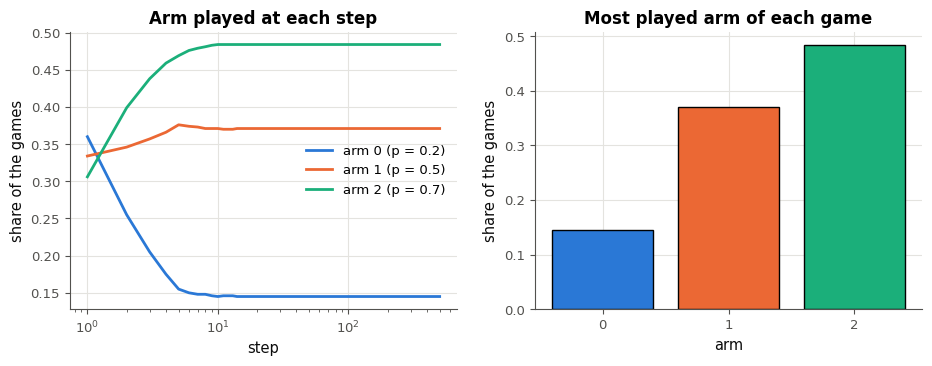

In [27]:
if any(answer is ... or answer is None for answer in [best_share_13, switches_13, last_reward_13]):
    print("⏳ Ex 11.13 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    arms_13, rewards_13 = greedy_runs_13(MEANS_13)
    counts_13 = np.stack([(arms_13 == arm).sum(axis=1) for arm in range(3)], axis=1)
    most_13 = counts_13.argmax(axis=1)                       # the most played arm of each game
    share_13 = np.bincount(most_13, minlength=3) / len(most_13)
    switch_13 = (arms_13[:, 100:] != arms_13[:, [100]]).any(axis=1)
    print("share of the games where each arm is the most played:", np.round(share_13, 3).tolist())
    print("games that play another arm after step 100:", int(switch_13.sum()), "of", len(switch_13))
    print("mean reward over the last 100 steps (all games):", round(float(rewards_13[:, -100:].mean()), 3))
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for arm in range(3):
        axes[0].plot(np.arange(1, arms_13.shape[1] + 1), (arms_13 == arm).mean(axis=0),
                     label=f"arm {arm} (p = {MEANS_13[arm]})")
    axes[0].set(xscale="log", xlabel="step", ylabel="share of the games", title="Arm played at each step")
    axes[0].legend()
    axes[1].bar(range(3), share_13, color=["C0", "C1", "C2"], edgecolor="black")   # the colours of the left panel
    axes[1].set(xticks=range(3), xlabel="arm", ylabel="share of the games", title="Most played arm of each game")
    plt.show()

Dans tes notes : compare avec tes prédictions. Explique chacun des trois résultats à partir de la règle du glouton. Peux-tu retrouver par le calcul les parts de a) et la valeur de c) ?

💡 Le meilleur bras n'est le plus joué que dans environ la moitié des parties (C), et une partie ne change **jamais** de bras après les premiers pas (b : `False`). Tout se joue au premier succès. Tant qu'aucun bras n'a rapporté 1, les trois estimations valent 0 et l'agent tire au sort ; dès qu'un bras rapporte 1, son estimation devient positive et le reste pour toujours (une moyenne de 0 et de 1 avec au moins un 1), alors que les autres restent à 0 : l'agent ne les tirera plus. À chaque pas avant ce premier succès, le bras $a$ est tiré avec la probabilité 1/3 et réussit avec la probabilité $p_a$ : le premier succès tombe sur $a$ avec la probabilité $p_a / (0{,}2 + 0{,}5 + 0{,}7)$, soit 1/7, 5/14 et 1/2 (on mesure 0,145, 0,371 et 0,484). La récompense moyenne finale vaut donc $(0{,}2^2 + 0{,}5^2 + 0{,}7^2)/1{,}4 \approx 0{,}557$ (on mesure 0,553 ; c : 0,56), loin des 0,7 du meilleur bras. Le glouton n'apprend pas quel bras est le meilleur : il retient le premier qui l'a récompensé. Il faut explorer (ε-greedy, valeurs optimistes, UCB, Thompson : parties D et E).

## Partie B · Raisonner avec du code : Holmes, Venn et les sophismes

Trois exercices sur la déduction : compter le vocabulaire du raisonnement chez Holmes et chez Verne (11.14), vérifier des syllogismes par force brute (11.15), puis dessiner les sophismes (11.16). La cellule suivante charge les deux corpus du ch. 6 et la fonction `words` de ce chapitre, et découpe les *Aventures* en douze nouvelles (`STORIES[11]` donne le titre et le texte de la onzième).

In [28]:
# The corpora of ch. 6: the Adventures of Sherlock Holmes (1892) and Verne's Le Tour du monde en quatre-vingts jours
holmes, verne = wb.datasets.load_holmes(), wb.datasets.load_verne()


def words(text):
    """The words of a text, in lower case: runs of letters (accented ones included); the rest separates them (ch. 6)."""
    return re.findall(r"[^\W\d_]+", text.lower())


ROMAN = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5, "VI": 6, "VII": 7, "VIII": 8, "IX": 9, "X": 10, "XI": 11, "XII": 12}


def split_stories(text):
    """The twelve stories of the Adventures: {number: (title, text)}, cut at the headings such as
    "XI. THE ADVENTURE OF THE BERYL CORONET"."""
    heads = list(re.finditer(r"(?m)^([IVX]+)\. ([A-Z][A-Z’\- ]+)$", text))
    ends = [head.start() for head in heads[1:]] + [len(text)]
    return {ROMAN[head.group(1)]: (head.group(2).title(), text[head.end():end]) for head, end in zip(heads, ends)}


STORIES = split_stories(holmes)
print(f"Holmes: {len(words(holmes)):,} words in {len(STORIES)} stories · Verne: {len(words(verne)):,} words")
print({number: title for number, (title, _) in STORIES.items()})

Holmes: 105,849 words in 12 stories · Verne: 72,367 words
{1: 'A Scandal In Bohemia', 2: 'The Red-Headed League', 3: 'A Case Of Identity', 4: 'The Boscombe Valley Mystery', 5: 'The Five Orange Pips', 6: 'The Man With The Twisted Lip', 7: 'The Adventure Of The Blue Carbuncle', 8: 'The Adventure Of The Speckled Band', 9: 'The Adventure Of The Engineer’S Thumb', 10: 'The Adventure Of The Noble Bachelor', 11: 'The Adventure Of The Beryl Coronet', 12: 'The Adventure Of The Copper Beeches'}


### Ex 11.14 — Holmes déduit-il ? Compter et citer le vocabulaire du raisonnement 🔨 ★★ ⏱️ 25 min
**Objectif :** compter des familles de mots avec des expressions régulières, en repérant les faux positifs, et retrouver une citation dans un corpus.  
**Prérequis :** 0A (module re, collections.Counter) · ch. 6 (les corpus, words) · fiche §11.3, §11.6.1 · **Fil rouge :** Holmes/Verne · **Parcours :** C

Holmes « déduit »-il plus qu'il n'« observe » ? Et Phileas Fogg, le héros de Verne, raisonne-t-il avec les mêmes mots ? Écris :
- `family_counts_14(text, stem)` : un `collections.Counter` des mots de `text` qui **commencent** par `stem`, en minuscules, sans tenir compte des majuscules (pour `"deduc"` : `deduce`, `deduction`, `deduced`…). Une expression régulière avec `\b` (début de mot) et `re.IGNORECASE`, ou un filtre sur `words(text)`, conviennent ;
- `story_of_14(stories, phrase)` : le numéro de la nouvelle qui contient `phrase`, sans tenir compte des majuscules ; attention, dans le texte, une phrase peut être coupée par un **retour à la ligne** : chaque espace de `phrase` doit pouvoir correspondre à un ou plusieurs blancs (`\s+`).

La vérification contrôle, pour Holmes :
a) le nombre de mots de la famille « deduc » ;
b) `infer_false_positive_14` : le mot de la famille « infer » qui n'a **rien à voir** avec une inférence (regarde les mots trouvés) ;
c) le nombre de mots de la famille « infer » sans ce faux positif ;
d) la fréquence de la famille « deduc » pour 10 000 mots (`words(holmes)` compte les mots) ;
puis, pour Verne, dont le texte est en français (avec des lettres accentuées) :
e) le nombre de mots de la famille « infér » (regarde lesquels : parlent-ils d'inférence ?) ;
f) la fréquence de la famille « observ » pour 10 000 mots ;
et enfin le numéro de la nouvelle qui contient :
g) « excluded the impossible » ;
h) « capital mistake to theorise ».

Dans tes notes : compare « deduc » et « observ » chez Holmes. Qu'en conclus-tu sur sa méthode, à la lumière du §11.6.1 de la fiche ? Pourquoi la comparaison entre Holmes et Verne demande-t-elle de la prudence (langue, genre, traduction des mots) ? Quel autre faux positif guette la famille « fact » ?

In [29]:
def family_counts_14(text, stem):
    """Counter of the words of `text` that start with `stem` (upper or lower case), written in lower case."""
    return collections.Counter(word.lower() for word in re.findall(rf"\b{re.escape(stem)}\w*", text, flags=re.IGNORECASE))


def story_of_14(stories, phrase):
    """The number (a key of `stories`) of the story whose text contains `phrase`, upper or lower case, where a line
    break or several spaces of the text may stand for a space of `phrase`; None if no story contains it."""
    pattern = r"\s+".join(re.escape(part) for part in phrase.split())
    for number, (_, story) in stories.items():
        if re.search(pattern, story, flags=re.IGNORECASE):
            return number
    return None


infer_false_positive_14 = "infernal"   # "an infernal noise": nothing to do with an inference

if True:
    deduc_14 = family_counts_14(holmes, "deduc")
    if returned("11.14", "family_counts_14", deduc_14):
        deduc_14 = collections.Counter(deduc_14)
        print("Holmes, the deduc family:", dict(deduc_14.most_common()))
        print_answer("11.14a", sum(deduc_14.values()), computed=True)
        infer_14 = collections.Counter(family_counts_14(holmes, "infer"))
        print("Holmes, the infer family:", dict(infer_14.most_common()))
        print_answer("11.14b", infer_false_positive_14)
        if filled(infer_false_positive_14):
            print_answer("11.14c", sum(n for word, n in infer_14.items() if word != str(infer_false_positive_14).strip().lower()),
                     computed=True)
        print_answer("11.14d", sum(deduc_14.values()) / len(words(holmes)) * 10_000, computed=True)
        print("Holmes:", {stem: sum(family_counts_14(holmes, stem).values()) for stem in ("observ", "reason", "theor", "induc", "fact")})
        verne_14 = {stem: sum(family_counts_14(verne, stem).values())
                    for stem in ("déduc", "dédui", "induc", "observ", "raisonn", "conclu", "infér")}
        print("Verne:", verne_14)
        print("Verne, the infér family:", dict(collections.Counter(family_counts_14(verne, "infér")).most_common()))
        print_answer("11.14e", verne_14["infér"], computed=True)
        print_answer("11.14f", verne_14["observ"] / len(words(verne)) * 10_000, computed=True)
    for letter_14, phrase_14 in (("g", "excluded the impossible"), ("h", "capital mistake to theorise")):
        number_14 = story_of_14(STORIES, phrase_14)
        print(f"« {phrase_14} » : story {number_14}" + (f", {STORIES[number_14][0]}" if number_14 in STORIES else ""))
        print_answer(f"11.14{letter_14}", number_14, computed=True)

Holmes, the deduc family: {'deduce': 13, 'deduction': 6, 'deduced': 5, 'deductions': 4, 'deductive': 1}
11.14a: 29
Holmes, the infer family: {'inferences': 4, 'infer': 2, 'inferred': 1, 'inference': 1, 'infernal': 1}
11.14b: infernal
11.14c: 8
11.14d: 2.739751910740772
Holmes: {'observ': 57, 'reason': 54, 'theor': 18, 'induc': 2, 'fact': 65}
Verne: {'déduc': 0, 'dédui': 0, 'induc': 0, 'observ': 24, 'raisonn': 4, 'conclu': 7, 'infér': 2}
Verne, the infér family: {'inférieurs': 1, 'inférieures': 1}
11.14e: 2
11.14f: 3.3164287589647214
« excluded the impossible » : story 11, The Adventure Of The Beryl Coronet
11.14g: 11
« capital mistake to theorise » : story 1, A Scandal In Bohemia
11.14h: 1


In [30]:
deduc_ref_14 = family_counts_14(holmes, "deduc")
infer_ref_14 = family_counts_14(holmes, "infer")
wb.record("11.14a", sum(deduc_ref_14.values()), mistakes={"tu ne comptes que le mot « deduce » : la famille compte aussi deduction, deduced, deductions, deductive": deduc_ref_14["deduce"],
                                                         "tu ne comptes que le mot « deduction » : la famille compte aussi deduce, deduced, deductions, deductive": deduc_ref_14["deduction"]})
wb.record("11.14b", infer_false_positive_14, mistakes={"une inférence est bien une inférence : regarde le sens des autres mots de la famille": "inference",
                                                      "« inferences » est le pluriel d'inference : regarde le sens des autres mots de la famille": "inferences"})
wb.record("11.14c", sum(infer_ref_14.values()) - infer_ref_14["infernal"], mistakes={"retire le faux positif du total : un seul mot, compté une fois": sum(infer_ref_14.values())})
wb.record("11.14d", sum(deduc_ref_14.values()) / len(words(holmes)) * 10_000, decimals=5,
          mistakes={"c'est pour 1 000 mots : on demande pour 10 000": sum(deduc_ref_14.values()) / len(words(holmes)) * 1_000})
wb.record("11.14e", sum(family_counts_14(verne, "infér").values()),
          mistakes={"aucun mot trouvé : ton expression, ou ton découpage en mots, gère-t-il les lettres accentuées (é) ?": 0})
wb.record("11.14f", sum(family_counts_14(verne, "observ").values()) / len(words(verne)) * 10_000, decimals=4,
          mistakes={"divise par le nombre de mots de Verne, pas par celui de Holmes": sum(family_counts_14(verne, "observ").values()) / len(words(holmes)) * 10_000})
wb.record("11.14g", story_of_14(STORIES, "excluded the impossible"))
wb.record("11.14h", story_of_14(STORIES, "capital mistake to theorise"))

WB_ANSWER {"hash": "0573384457e93de71bb3e33acf10ec32b1285e6dd0a55bb35601bbd20a9e8764", "id": "11.14a", "kind": "int", "magnitude": 1, "mistakes": {"3e498c1194acebb17aec6484c21d9dbf911d4933a436b3b4c478f0da905d763b": "tu ne comptes que le mot « deduce » : la famille compte aussi deduction, deduced, deductions, deductive", "d9f90b0241dd2ce8b7abdae5f2bf95fa8812b5e2e369d1e5febf46fe9494d671": "tu ne comptes que le mot « deduction » : la famille compte aussi deduce, deduced, deductions, deductive"}, "sign": 1}
📝 Ex 11.14a : réponse enregistrée (int).
WB_ANSWER {"hash": "325797fcbad350541df5725b165b1d093109c81217c001bf2977e233123890e9", "id": "11.14b", "kind": "str", "mistakes": {"688a3259e904f7e71fffb15c88a95ef9a433a645c2c814b760ec4be1ec8fd082": "« inferences » est le pluriel d'inference : regarde le sens des autres mots de la famille", "a34d182f0ca7b634a139ccd13af4d4d0931ee0aba30b2ce1a9e24e93da47cbe7": "une inférence est bien une inférence : regarde le sens des autres mots de la famille"}}
📝

WB_ANSWER {"decimals": 5, "hash": "fb66200debfa1851a201cba7089c4137c7242c52a2717fe084646f75c12fe38d", "hash_coarse": "180ea111ea7e1a4aaf860d303d4f9a1325ba73d392a11b56db8583402f777f2f", "id": "11.14d", "kind": "float", "magnitude": 0, "mistakes": {"99c6fd0876f7bf387e774e52139f2b6d175985228e91548862924de4befd109a": "c'est pour 1 000 mots : on demande pour 10 000"}, "sign": 1}
📝 Ex 11.14d : réponse enregistrée (float, 5 décimale(s)).
WB_ANSWER {"hash": "4a6e2110b403790d5c9ff2800debb8ff50bf0516f9924a7bec1bce1bb90dceca", "id": "11.14e", "kind": "int", "magnitude": 0, "mistakes": {"8dd64dc62ae8d35486d676b1071f0395ada6f2e7826d61aa93d02beb82cf2892": "aucun mot trouvé : ton expression, ou ton découpage en mots, gère-t-il les lettres accentuées (é) ?"}, "sign": 1}
📝 Ex 11.14e : réponse enregistrée (int).
WB_ANSWER {"decimals": 4, "hash": "4f5dbd53bf74ad6fb00ed5f404ee8160a54919b673740c35a19ef91fd4cb529f", "hash_coarse": "82bf7dbde15aede12b023e840cab214fb971789ab18ccefab5549e5592257cfe", "id": "11

💡 Holmes emploie 29 mots de la famille « deduc » (13 *deduce*, 6 *deduction*, 5 *deduced*, 4 *deductions*, 1 *deductive*), soit 2,74 pour 10 000 mots, mais 57 de la famille « observ » et 54 de la famille « reason » : il parle presque deux fois plus d'observer que de déduire, ce qui est le signe d'une méthode inductive (ou abductive, fiche §11.6.1). La famille « infer » compte 9 mots, dont un intrus, *infernal* (« un bruit infernal ») : 8 vraies inférences. La famille « fact » piège aussi : *factor*, *factory*, *factories*. Verne n'emploie jamais « déduction » ni « déduire », et sa famille « infér » ne compte que deux mots (e : 2), *inférieurs* et *inférieures*, sans rapport avec une inférence ; mais il emploie 24 mots de la famille « observ » (3,32 pour 10 000 mots), dont 10 « observer ». Un découpage en mots qui ne garde que les lettres a à z coupe « inférieurs » en deux morceaux et n'en trouve aucun. La comparaison demande de la prudence : un roman d'aventures n'est pas un recueil d'enquêtes, et les familles ne se correspondent pas exactement d'une langue à l'autre (*reason* couvre « raison » et « raisonner »). La maxime de l'impossible est dans « The Beryl Coronet » (11), avec le verbe *excluded* au lieu du *eliminated* du *Signe des quatre* ; « It is a capital mistake to theorise before one has data » est dans « A Scandal in Bohemia » (1), coupée par un retour à la ligne après *has*, d'où le `\s+`.

### Ex 11.15 — Valider un syllogisme par force brute : 256 mondes de Venn 🔨 ★★ ⏱️ 30 min
**Objectif :** vérifier la validité d'un syllogisme en cherchant un contre-exemple parmi tous les mondes possibles.  
**Prérequis :** Ex 11.3 · 0A (itertools.product, ensembles, compréhensions) · fiche §11.4 (encadrés 🧮 sur les formes et sur le diagramme de Venn) · **Parcours :** M, C

Un « monde » dit, pour chacune des 8 régions du diagramme de Venn à trois cercles $S$, $M$, $P$, si elle contient au moins un élément. `REGIONS_15` liste les régions : un triplet de booléens (dans $S$ ?, dans $M$ ?, dans $P$ ?). Un monde est un `frozenset` des régions **non vides** ; il y en a $2^8 = 256$. Une proposition s'écrit `(forme, x, y)`, par exemple `("A", "M", "P")` pour « tout $M$ est $P$ ». Écris :
- `worlds_15()` : la liste des 256 mondes (`itertools.product([False, True], repeat=8)` donne les 256 façons de garder ou non chaque région) ;
- `holds_15(proposition, world)` : la vérité de la proposition dans le monde. « Tout $x$ est $y$ » est vrai si aucune région non vide n'est dans $x$ et hors de $y$ ; « quelque $x$ est $y$ », s'il existe une région non vide dans $x$ et dans $y$ ; à toi les deux autres ;
- `counterexamples_15(premises, conclusion)` : les mondes où toutes les prémisses sont vraies et la conclusion fausse. Le syllogisme est valide s'il n'y en a aucun ;
- `SYLLOGISMS_15` : les syllogismes S2, S3, S6 et S7 de ✏️ 11.3, codés avec $S$ = sujet de la conclusion, $P$ = son prédicat, $M$ = moyen terme (une liste de 4 paires `([majeure, mineure], conclusion)`) ;
- `valid_forms_15(existence=False)` : les formes valides parmi les 256 formes de syllogismes catégoriques. Une **forme** associe une forme à chaque prémisse et à la conclusion (A, E, I ou O, soit $4^3 = 64$ modes) et une **figure**, la place du moyen terme, donnée par `FIGURES_15` (4 figures) : par exemple « AAA-1 » est « tout $M$ est $P$ ; tout $S$ est $M$ ; donc tout $S$ est $P$ ». Avec `existence=True`, ajoute aux prémisses « $S$, $M$ et $P$ ont chacun au moins un membre » (« quelque $X$ est $X$ »).

La vérification contrôle :
a) le nombre de mondes où les deux prémisses du syllogisme des chats carnivores de la fiche (« tout $M$ est $P$ ; tout $S$ est $M$ ») sont vraies ;
b) le nombre de contre-exemples du moyen terme non distribué de la fiche (« tout $P$ est $M$ ; tout $S$ est $M$ ; donc tout $S$ est $P$ ») ;
c) le nombre de contre-exemples de « tout $M$ est $P$ ; tout $M$ est $S$ ; donc quelque $S$ est $P$ » (puis la cellule ajoute la prémisse « $M$ a au moins un membre ») ;
d) la liste des nombres de contre-exemples de S2, S3, S6 et S7 ;
e) le nombre de formes valides ;
f) le même nombre avec `existence=True`.

Dans tes notes : que montre c) sur l'hypothèse d'Aristote (fiche, encadré sur la distribution) ? Retrouves-tu tes réponses de ✏️ 11.3 ? Pourquoi le même nombre 256 apparaît-il deux fois dans cet exercice, pour deux choses différentes ?

In [31]:
REGIONS_15 = list(itertools.product([False, True], repeat=3))   # (in S, in M, in P): the 8 regions of the diagram
TERMS_15 = {"S": 0, "M": 1, "P": 2}                              # the position of each term in a region
FIGURES_15 = {1: (("M", "P"), ("S", "M")), 2: (("P", "M"), ("S", "M")),
              3: (("M", "P"), ("M", "S")), 4: (("P", "M"), ("M", "S"))}   # (major, minor) premises' terms
print(len(REGIONS_15), "regions, e.g.", REGIONS_15[5], "= in S, not in M, in P")

8 regions, e.g. (True, False, True) = in S, not in M, in P


In [32]:
def worlds_15():
    """The 256 worlds: each world is a frozenset of the regions of REGIONS_15 that are NOT empty."""
    return [frozenset(region for region, kept in zip(REGIONS_15, mask) if kept)
            for mask in itertools.product([False, True], repeat=len(REGIONS_15))]


def holds_15(proposition, world):
    """Truth of a proposition (form, x, y) in `world`: form "A" every x is y, "E" no x is y, "I" some x is y,
    "O" some x is not y; x and y are "S", "M" or "P"."""
    form, x, y = proposition
    i, j = TERMS_15[x], TERMS_15[y]
    some_x_y = any(region[i] and region[j] for region in world)
    some_x_not_y = any(region[i] and not region[j] for region in world)
    return {"A": not some_x_not_y, "E": not some_x_y, "I": some_x_y, "O": some_x_not_y}[form]


def counterexamples_15(premises, conclusion):
    """The worlds (among the 256) where every premise holds and the conclusion does not."""
    return [world for world in worlds_15()
            if all(holds_15(premise, world) for premise in premises) and not holds_15(conclusion, world)]


SYLLOGISMS_15 = [([("I", "M", "P"), ("A", "S", "M")], ("I", "S", "P")),    # S2: M = confidential, P = drafts
                 ([("E", "M", "P"), ("I", "S", "M")], ("O", "S", "P")),    # S3: M = linear models, P = compute XOR
                 ([("O", "M", "P"), ("A", "S", "M")], ("O", "S", "P")),    # S6: M = birds, P = fly
                 ([("E", "P", "M"), ("E", "S", "M")], ("E", "S", "P"))]    # S7: M = mammals, P = fish


def valid_forms_15(existence=False):
    """The valid forms among the 4 × 4³ = 256 forms of categorical syllogisms, written like "AAA-1" (the forms of
    the major premise, of the minor premise and of the conclusion "S ... P", then the figure); existence=True adds
    three premises: S, M and P each have at least one member."""
    extra = [("I", term, term) for term in "SMP"] if existence else []
    valid = []
    for figure, ((x1, y1), (x2, y2)) in FIGURES_15.items():
        for f1, f2, f3 in itertools.product("AEIO", repeat=3):
            if not counterexamples_15([(f1, x1, y1), (f2, x2, y2)] + extra, (f3, "S", "P")):
                valid.append(f"{f1}{f2}{f3}-{figure}")
    return valid

if True:
    worlds_15_ = worlds_15()
    if returned("11.15", "worlds_15", worlds_15_):
        verdict("11.15", len(worlds_15_) == 256 and len(set(worlds_15_)) == 256,
                "256 mondes, tous différents.",
                f"attendu 256 mondes différents (chaque région vide ou non) ; reçu {len(worlds_15_)} mondes, dont "
                f"{len(set(worlds_15_))} différents.")
        barbara_15 = [("A", "M", "P"), ("A", "S", "M")]
        print_answer("11.15a", sum(all(holds_15(p, world) for p in barbara_15) for world in worlds_15_), computed=True)
        print_answer("11.15b", len(counterexamples_15([("A", "P", "M"), ("A", "S", "M")], ("A", "S", "P"))), computed=True)
        darapti_15 = [("A", "M", "P"), ("A", "M", "S")]
        print_answer("11.15c", len(counterexamples_15(darapti_15, ("I", "S", "P"))), computed=True)
        print("with the premise « M has a member »:",
              len(counterexamples_15(darapti_15 + [("I", "M", "M")], ("I", "S", "P"))), "counterexample(s)")
        if filled(SYLLOGISMS_15):
            print_answer("11.15d", [len(counterexamples_15(premises, conclusion)) for premises, conclusion in SYLLOGISMS_15],
                     computed=True)
        else:
            print_answer("11.15d", None)                  # ⏳ while SYLLOGISMS_15 is not written
        start_15 = time.perf_counter()
        valid_15 = valid_forms_15()
        print(len(valid_15), "valid forms:", valid_15, f"({time.perf_counter() - start_15:.1f} s)")
        print_answer("11.15e", len(valid_15), computed=True)
        print_answer("11.15f", len(valid_forms_15(existence=True)), computed=True)

✅ Ex 11.15 : 256 mondes, tous différents.
11.15a: 16
11.15b: 16
11.15c: 8
with the premise « M has a member »: 0 counterexample(s)
11.15d: [16, 0, 16, 16]


15 valid forms: ['AAA-1', 'AII-1', 'EAE-1', 'EIO-1', 'AEE-2', 'AOO-2', 'EAE-2', 'EIO-2', 'AII-3', 'EIO-3', 'IAI-3', 'OAO-3', 'AEE-4', 'EIO-4', 'IAI-4'] (0.2 s)
11.15e: 15


11.15f: 24


In [33]:
worlds_ref_15 = worlds_15()
wb.record("11.15a", sum(all(holds_15(p, world) for p in [("A", "M", "P"), ("A", "S", "M")]) for world in worlds_ref_15),
          mistakes={"c'est le nombre de mondes où une seule prémisse est vraie : il faut les deux à la fois": sum(holds_15(("A", "M", "P"), world) for world in worlds_ref_15)})
wb.record("11.15b", len(counterexamples_15([("A", "P", "M"), ("A", "S", "M")], ("A", "S", "P"))))
wb.record("11.15c", len(counterexamples_15([("A", "M", "P"), ("A", "M", "S")], ("I", "S", "P"))))
wb.record("11.15d", [len(counterexamples_15(premises, conclusion)) for premises, conclusion in SYLLOGISMS_15],
          mistakes={"S3 : relis son codage (la forme, le sujet et le prédicat de chaque proposition) et compare avec ton verdict de ✏️ 11.3": [16, 16, 16, 16]})
wb.record("11.15e", len(valid_forms_15()), mistakes={"c'est le résultat attendu avec existence=True : ta fonction ajoute-t-elle les prémisses d'existence même quand existence vaut False ?": 24})
wb.record("11.15f", len(valid_forms_15(existence=True)), mistakes={"c'est le résultat attendu sans l'hypothèse d'existence : ta fonction ajoute-t-elle les trois prémisses quand existence vaut True ?": 15})

WB_ANSWER {"hash": "4d864acadbf2bbdd5d54518adb9fd27e14d0f5ea1911c6e5e6e452ef20695439", "id": "11.15a", "kind": "int", "magnitude": 1, "mistakes": {"c7b0bba17e81da2d286b4d4de55c2cbf7c50f5021e6daf10d23f21d2230b23e2": "c'est le nombre de mondes où une seule prémisse est vraie : il faut les deux à la fois"}, "sign": 1}
📝 Ex 11.15a : réponse enregistrée (int).
WB_ANSWER {"hash": "982269ee93a14fc7bb94c7bfb4eb26da37338291e7bfbeb9a0f27a47dec5c804", "id": "11.15b", "kind": "int", "magnitude": 1, "sign": 1}
📝 Ex 11.15b : réponse enregistrée (int).
WB_ANSWER {"hash": "a995e682721989a5973de6cad8139c316f1287b6ab63fdc6cd548419c2e8183b", "id": "11.15c", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 11.15c : réponse enregistrée (int).


WB_ANSWER {"decimals": 0, "element_hashes": ["82e7103e181760e3576ea340884dd35f1427339924591e64534f7a16858388c4", "24c2752c09f5d76d1fcfb2204ab061caf25a42d8a00b4f7e93ea3f42d068629f", "fc9244b53dea86158e9fcf50ebdb473316b588d533ce584597351d6fe4642404", "ac42373ee50a367dfc3254992d8a7828fc1262d95f2f2364715be91c2aa4efb3"], "hash": "277e59d86d136933e61471b3d76702793a292b0b584f658660249308ec7938a8", "id": "11.15d", "integer": true, "kind": "array", "mistakes": {"b4531c0b0e723d99849164c4e69ac372d7af46390fc20dd5d3237b4c59e6fdb3": "S3 : relis son codage (la forme, le sujet et le prédicat de chaque proposition) et compare avec ton verdict de ✏️ 11.3"}, "shape": [4]}
📝 Ex 11.15d : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"hash": "7eeffd91bc60047289e40e312fc6c7500b88fa68a1ad02d6db27e7197a97cbde", "id": "11.15e", "kind": "int", "magnitude": 1, "mistakes": {"ae374e58d7eac294ade9c90f54f3ae59fd3641cf25bf8571b636a9b3a9a6609d": "c'est le résultat attendu avec existence=True : ta fonction ajou

WB_ANSWER {"hash": "634545cfc4ccba61ea9b1d4e3f7100de96cd59638fcb497cdfcf6023b7797ff8", "id": "11.15f", "kind": "int", "magnitude": 1, "mistakes": {"717cb2f7769cecf3485bcb8c60c08fbe6acfd09d6cfad946ac1610a3d0eb8a05": "c'est le résultat attendu sans l'hypothèse d'existence : ta fonction ajoute-t-elle les trois prémisses quand existence vaut True ?"}, "sign": 1}
📝 Ex 11.15f : réponse enregistrée (int).


💡 Les prémisses du syllogisme des chats sont vraies dans 16 mondes, et la conclusion dans tous les 16 : valide. Le moyen terme non distribué a 16 contre-exemples (le point violet de la fiche en est un). « Tout $M$ est $P$ ; tout $M$ est $S$ ; donc quelque $S$ est $P$ » (la forme Darapti) a 8 contre-exemples, tous des mondes où $M$ est vide (parmi les 16 où $M$ est vide, ceux où, de plus, aucun $S$ n'est $P$). Dès qu'on ajoute « $M$ a au moins un membre », il n'y en a plus : c'est l'hypothèse d'Aristote, que la logique moderne ne fait pas. S2, S6 et S7 ont 16 contre-exemples chacun, S3 aucun : les réponses de ✏️ 11.3. Sur les 256 formes, 15 sont valides dans la lecture moderne et 24 avec l'hypothèse d'existence : ce sont les nombres classiques des manuels de logique. Le nombre 256 apparaît deux fois par coïncidence : $2^8$ mondes (8 régions vides ou non) et $4^3 \times 4$ formes (trois propositions à 4 formes, 4 figures). Le calcul, environ 200 000 vérifications de mondes, prend une fraction de seconde : la force brute suffit parce que le nombre de mondes est petit.

### Ex 11.16 — Reproduire la figure 11.5 : les cinq sophismes en diagrammes 🎨 ★★ ⏱️ 25 min
**Objectif :** traduire chaque sophisme syllogistique en un diagramme où un contre-exemple rend les prémisses vraies et la conclusion fausse.  
**Prérequis :** Ex 11.4 · fiche §11.4.1 (le tableau des sophismes) · livre figure 11.5 · **Parcours :** C

La figure 11.5 du livre dessine cinq sophismes avec des ensembles emboîtés et un point violet, un contre-exemple. Refais-la avec les exemples du tableau de la fiche (§11.4.1) : le cadre « animaux et meubles » (tout ce dont parlent les exemples), la boîte « à quatre pattes », l'ellipse « chats », et selon le sophisme une ellipse « chiens », « mammifères » ou « tables ». Les fonctions fournies dessinent une boîte ou une ellipse (`region_16`) et le point violet (`counterexample_16`) ; `blank_16(ax)` prépare des axes de 0 à 1.

Écris `draw_fallacy_16(ax, name)`, qui dessine le sophisme `name` (l'un de `FALLACIES_16`). Pour chaque diagramme, les **prémisses** doivent y être vraies (« tout chat a quatre pattes » : l'ellipse des chats est entièrement dans la boîte) et le point violet doit rendre la **conclusion** fausse. Pour le mineur illicite, l'ellipse « mammifères » contient les chats, mais déborde de la boîte « à quatre pattes » (la baleine).

La vérification dessine les cinq diagrammes et compte les points violets. Elle ne juge pas le dessin : c'est à toi de vérifier, pour chaque diagramme, que les deux prémisses sont vraies et que le point violet contredit la conclusion.

Dans tes notes : pour les deux premiers sophismes, le livre dessine la même figure, à un détail près. Pourquoi une seule figure suffit-elle ? Quel diagramme montrerait le sophisme des prémisses exclusives (aucun chat n'est un poisson ; aucun poisson n'est un mammifère) ?

In [34]:
from matplotlib.patches import Ellipse, Rectangle

FALLACIES_16 = ["affirmer le conséquent", "nier l'antécédent", "majeur illicite", "mineur illicite",
                "moyen terme non distribué"]


def region_16(ax, shape, xy, width, height, label, color, label_xy=None):
    """Draw a set: shape "box" (a rectangle) or "blob" (an ellipse), centred at xy, with its label (by default near
    the top of a box, at the centre of a blob; label_xy moves it)."""
    x, y = xy
    if shape == "box":
        ax.add_patch(Rectangle((x - width / 2, y - height / 2), width, height, facecolor=color, edgecolor="black",
                               alpha=0.35, lw=1.2))
        lx, ly = label_xy or (x - width / 2 + 0.03, y + height / 2 - 0.03)
        ax.text(lx, ly, label, va="top", fontsize=8.5)
    else:
        ax.add_patch(Ellipse((x, y), width, height, facecolor=color, edgecolor="black", alpha=0.45, lw=1.2))
        lx, ly = label_xy or (x, y + 0.03)
        ax.text(lx, ly, label, ha="center", fontsize=8.5)


def counterexample_16(ax, xy):
    """The purple dot: one element that makes both premises true and the conclusion false."""
    ax.scatter(*xy, s=90, color="#8e24aa", edgecolor="black", zorder=5, gid="counterexample")


def blank_16(ax):
    """Empty axes from 0 to 1, without ticks."""
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=[], yticks=[], aspect="equal")

✅ Ex 11.16 : cinq diagrammes, un contre-exemple violet dans chacun.


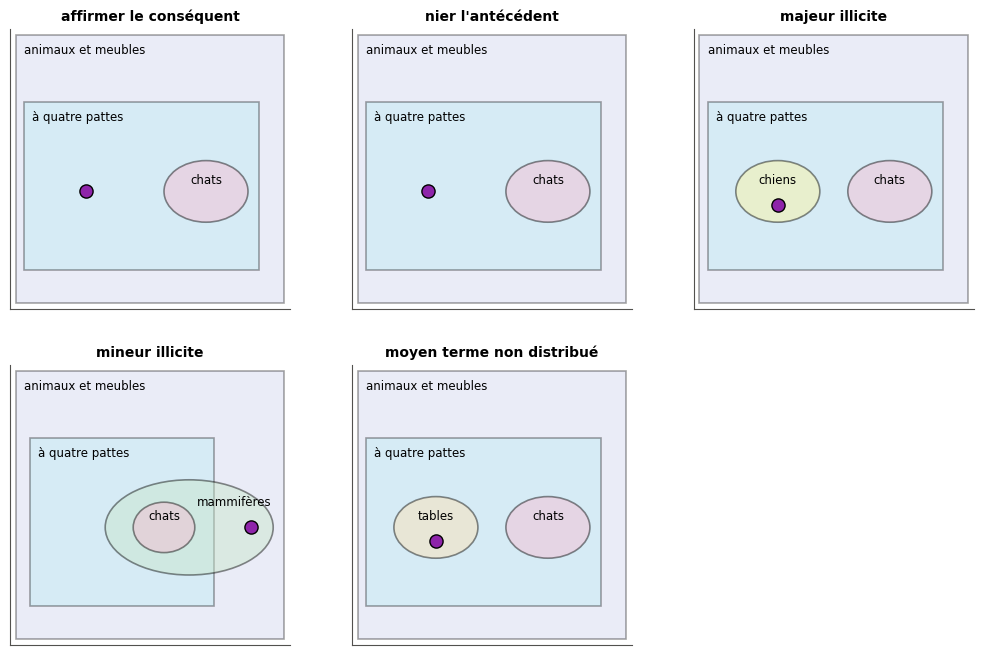

In [35]:
def draw_fallacy_16(ax, name):
    """Draw in `ax` the diagram of the fallacy `name` (one of FALLACIES_16), with the example of the course sheet:
    the sets (the frame "animaux et meubles", those with four legs, cats, then dogs, mammals or tables depending on
    the fallacy) and the purple counterexample."""
    blank_16(ax)
    region_16(ax, "box", (0.5, 0.5), 0.96, 0.96, "animaux et meubles", "#c5cae9")
    if name == "mineur illicite":                     # every cat has four legs; every cat is a mammal
        region_16(ax, "box", (0.4, 0.44), 0.66, 0.6, "à quatre pattes", "#b2ebf2")
        region_16(ax, "blob", (0.64, 0.42), 0.6, 0.34, "mammifères", "#c8e6c9", label_xy=(0.8, 0.5))
        region_16(ax, "blob", (0.55, 0.42), 0.22, 0.18, "chats", "#f8bbd0")
        counterexample_16(ax, (0.86, 0.42))           # a mammal without four legs (a whale), outside the box
        return
    region_16(ax, "box", (0.47, 0.44), 0.84, 0.6, "à quatre pattes", "#b2ebf2")
    region_16(ax, "blob", (0.7, 0.42), 0.3, 0.22, "chats", "#f8bbd0")
    if name in ("affirmer le conséquent", "nier l'antécédent"):
        counterexample_16(ax, (0.27, 0.42))           # a four-legged animal that is not a cat (a dog)
    elif name == "majeur illicite":                   # every cat has four legs; no dog is a cat
        region_16(ax, "blob", (0.3, 0.42), 0.3, 0.22, "chiens", "#fff59d")
        counterexample_16(ax, (0.3, 0.37))            # a dog (not a cat) that has four legs
    else:                                             # undistributed middle: tables have four legs too
        region_16(ax, "blob", (0.3, 0.42), 0.3, 0.22, "tables", "#ffe0b2")
        counterexample_16(ax, (0.3, 0.37))            # a table that is not a cat

if True:
    fig_16, axes_16 = plt.subplots(2, 3, figsize=(12.5, 8))
    dots_16 = []
    try:
        for ax_16, name_16 in zip(axes_16.ravel(), FALLACIES_16):
            draw_fallacy_16(ax_16, name_16)
            ax_16.set_title(name_16, fontsize=10)
            dots_16.append(sum(1 for item in ax_16.collections if item.get_gid() == "counterexample"))
    except BaseException:
        plt.close(fig_16)                             # no empty figure while the function is not written
        raise
    axes_16.ravel()[-1].axis("off")
    verdict("11.16", dots_16 == [1] * 5, "cinq diagrammes, un contre-exemple violet dans chacun.",
            f"il faut un point violet (counterexample_16) par diagramme ; reçu {dots_16}.")
    plt.show()

💡 Les deux premiers sophismes ont le même contre-exemple : un animal à quatre pattes qui n'est pas un chat (un chien). Dans l'affirmation du conséquent, il réfute « c'est un chat » ; dans la négation de l'antécédent, « il n'a pas quatre pattes ». Une seule figure suffit, parce que les deux sophismes oublient la même chose : la boîte « à quatre pattes » contient d'autres animaux que les chats. Le livre ne change que la place du point. Pour le majeur illicite, le contre-exemple est un chien (pas un chat, mais à quatre pattes) ; pour le mineur illicite, une baleine (un mammifère sans pattes) ; pour le moyen terme non distribué, une table (à quatre pattes, mais pas un chat). Pour les prémisses exclusives, dessine trois ellipses disjointes « chats », « poissons », « mammifères », puis remarque que rien n'interdit à l'ellipse des chats d'être dans celle des mammifères : le point violet est un chat, qui est un mammifère.

## Partie C · Induire : échantillons, biais et sophismes

Deux expériences sur l'induction : un échantillon trop petit ou mal collecté chez les manchots (11.17), puis la figure 11.10 du livre mise en équations, avec des points sur un cercle (11.18). La cellule suivante charge les 333 manchots complets du ch. 1, qui jouent ici le rôle de la population. Les valeurs que tu calcules dans une cellule à compléter ne s'arrondissent pas : la vérification s'en charge.

In [36]:
# The 333 complete penguins of ch. 1: the population of 11.17
penguins = wb.datasets.load_penguins(dropna=True)
species = penguins["species"].to_numpy()
island = penguins["island"].to_numpy()
mass = penguins["body_mass_g"].to_numpy(dtype=float)
is_gentoo = species == "Gentoo"
print(len(penguins), "penguins;", penguins.groupby(["island", "species"]).size().to_dict())

333 penguins; {('Biscoe', 'Adelie'): 44, ('Biscoe', 'Gentoo'): 119, ('Dream', 'Adelie'): 55, ('Dream', 'Chinstrap'): 68, ('Torgersen', 'Adelie'): 47}


### Ex 11.17 — Généralisation hâtive et échantillon biaisé chez les manchots 🔬 ★★ ⏱️ 25 min
**Objectif :** mesurer ce que coûte un petit échantillon, et ce que coûte un échantillon mal collecté, qu'aucune taille ne corrige.  
**Prérequis :** ch. 2 (échantillonnage), ch. 8 (erreur type) · Ex 11.6 · fiche §11.5, §11.5.2 · **Fil rouge :** Penguins · **Parcours :** R, C

Les 333 manchots complets du ch. 1 sont ici toute la population, et la propriété étudiée est « être un Gentoo ». Écris :
- `p_gentoo_17` : la part de Gentoo dans la population, calculée sans l'arrondir ;
- `standard_error_17(p, n)` : l'erreur type d'une proportion mesurée sur un échantillon de taille $n$ tiré **avec remise** (ch. 8) ;
- `sample_shares_17(n, n_samples, rng)` : la part de Gentoo dans chacun de `n_samples` échantillons de $n$ manchots tirés au hasard avec remise (`rng.integers` ou `rng.choice`) ;
- `p_biscoe_17` : la part de Gentoo si l'on n'a pu débarquer que sur l'île Biscoe (un échantillon **biaisé** par la collecte), calculée elle aussi ;
- `size_biased_mean_17(masses)` : une autre collecte biaisée. Les manchots lourds sont plus faciles à attraper : la probabilité qu'un manchot de masse $m$ soit capturé est proportionnelle à $m$, soit $m / \sum m$. Calcule l'espérance de la masse d'un manchot capturé ;
- `more_data_fixes_bias_17` : en pesant dix fois plus de manchots, capturés de la même façon, l'estimation de la masse moyenne deviendrait-elle juste ? (`True` ou `False`)

La vérification contrôle :
a) la part de Gentoo dans la population ;
b) l'erreur type pour $n = 5$ ;
c) l'erreur type pour $n = 100$ ;
puis tire 4 000 échantillons de 5, 20 et 100 manchots et compare leur dispersion à l'erreur type ;
d) la part de Gentoo à Biscoe ;
e) l'espérance de la masse d'un manchot capturé, comparée ensuite à une simulation et à la masse moyenne de la population ;
f) ta réponse sur les dix fois plus de manchots.

Dans tes notes : quelle part des échantillons de 5 manchots se trompe de plus de 10 points ? Quel sophisme inductif guette celui qui conclut à partir d'un tel échantillon, et celui qui n'a visité que Biscoe ? Pourquoi l'erreur type ne dit-elle rien du biais de Biscoe ?

11.17a: 0.35735735735735735
11.17b: 0.21431429093736298
11.17c: 0.04792213230856108
n =   5: std of the 4,000 estimates 0.2159 (standard error 0.2143); 66% of them are more than 10 points away
n =  20: std of the 4,000 estimates 0.1058 (standard error 0.1072); 35% of them are more than 10 points away
n = 100: std of the 4,000 estimates 0.0470 (standard error 0.0479); 3% of them are more than 10 points away


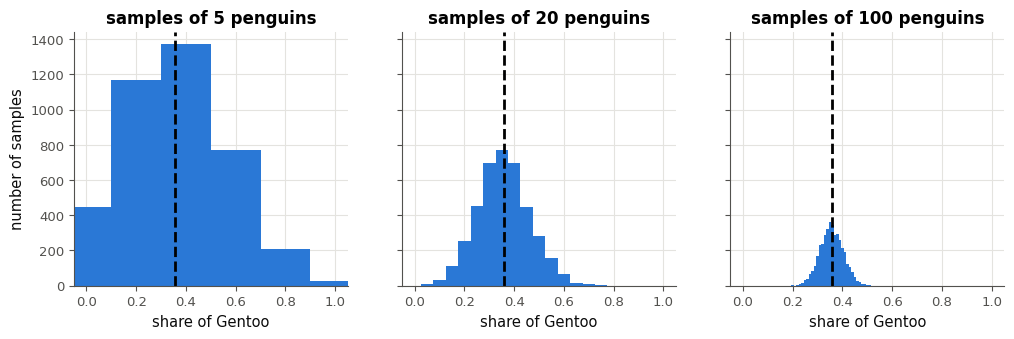

✅ Ex 11.17 : pour n = 100, la dispersion des estimations colle à l'erreur type.
11.17d: 0.7300613496932515
Torgersen only: 0.0 · Dream only: 0.0
11.17e: 4360.709696991327
population mean 4207.1 g · mean of the caught penguins 4360.4 g
✅ Ex 11.17 : la simulation retrouve ta formule : les manchots capturés sont plus lourds que la moyenne.
11.17f: False


In [37]:
p_gentoo_17 = float(is_gentoo.mean())


def standard_error_17(p, n):
    """Standard error of a share p measured on a random sample of n individuals drawn WITH replacement (ch. 8)."""
    return math.sqrt(p * (1 - p) / n)


def sample_shares_17(n, n_samples, rng):
    """The share of Gentoo in each of n_samples samples of n penguins drawn at random WITH replacement."""
    picks = rng.integers(len(is_gentoo), size=(n_samples, n))
    return is_gentoo[picks].mean(axis=1)


p_biscoe_17 = float(is_gentoo[island == "Biscoe"].mean())


def size_biased_mean_17(masses):
    """Expected mass of ONE penguin caught with a probability proportional to its mass."""
    masses = np.asarray(masses, dtype=float)
    return float(np.sum(masses * masses / masses.sum()))     # sum of m × P(m), with P(m) = m / sum(m)


more_data_fixes_bias_17 = False

if True:
    print_answer("11.17a", p_gentoo_17)
    true_p_17 = float(is_gentoo.mean())
    se_17 = {n: standard_error_17(true_p_17, n) for n in (5, 20, 100)}
    if returned("11.17", "standard_error_17", se_17[5]):
        print_answer("11.17b", se_17[5], computed=True)
        print_answer("11.17c", se_17[100], computed=True)
        rng_17 = np.random.default_rng(1117)
        all_shares_17 = {n_17: np.asarray(sample_shares_17(n_17, 4000, rng_17), dtype=float) for n_17 in (5, 20, 100)}
        fig_17, axes_17 = plt.subplots(1, 3, figsize=(12, 3.3), sharey=True)
        for ax_17, (n_17, shares_17) in zip(axes_17, all_shares_17.items()):
            far_17 = np.mean(np.abs(shares_17 - true_p_17) > 0.10)
            print(f"n = {n_17:3d}: std of the 4,000 estimates {shares_17.std():.4f} (standard error {se_17[n_17]:.4f}); "
                  f"{far_17:.0%} of them are more than 10 points away")
            ax_17.hist(shares_17, bins=(np.arange(n_17 + 2) - 0.5) / n_17, color="C0")   # one bar per possible share k/n
            ax_17.axvline(true_p_17, color="black", ls="--")
            ax_17.set(title=f"samples of {n_17} penguins", xlabel="share of Gentoo", xlim=(-0.05, 1.05))
        axes_17[0].set_ylabel("number of samples")
        plt.show()
        verdict("11.17", abs(shares_17.std() / se_17[100] - 1) < 0.1,
                "pour n = 100, la dispersion des estimations colle à l'erreur type.",
                "pour n = 100, l'écart-type des estimations s'éloigne de plus de 10 % de l'erreur type : tires-tu bien "
                "avec remise, n manchots par échantillon ?")

if True:
    print_answer("11.17d", p_biscoe_17)
    print("Torgersen only:", float(is_gentoo[island == "Torgersen"].mean()), "· Dream only:", float(is_gentoo[island == "Dream"].mean()))

if True:
    biased_17 = size_biased_mean_17(mass)
    if returned("11.17", "size_biased_mean_17", biased_17):
        print_answer("11.17e", biased_17, computed=True)
        rng_17 = np.random.default_rng(2117)
        caught_17 = rng_17.choice(mass, size=(2000, 50), p=mass / mass.sum())   # 2,000 samples of 50 caught penguins
        print(f"population mean {mass.mean():.1f} g · mean of the caught penguins {caught_17.mean():.1f} g")
        verdict("11.17", abs(caught_17.mean() - float(biased_17)) < 15,
                "la simulation retrouve ta formule : les manchots capturés sont plus lourds que la moyenne.",
                "la simulation s'éloigne de ta formule : la probabilité d'être capturé vaut m / (somme des masses), "
                "et l'espérance d'une masse capturée est la somme des m × P(m).")

print_answer("11.17f", more_data_fixes_bias_17)

In [38]:
wb.record("11.17a", p_gentoo_17, decimals=4, mistakes={"c'est la part des Adélie : on demande celle des Gentoo": float(np.mean(species == "Adelie")),
                                                           "c'est le nombre de Gentoo : on demande leur part": int(is_gentoo.sum()),
                                                           "ta valeur est arrondie à 2 décimales : écris le calcul lui-même, sans arrondir": round(p_gentoo_17, 2),
                                                           "ta valeur est arrondie à 3 décimales : écris le calcul lui-même, sans arrondir": round(p_gentoo_17, 3)})
wb.record("11.17b", standard_error_17(p_gentoo_17, 5), decimals=4, mistakes={"c'est la variance p(1 − p)/n : l'erreur type en est la racine": p_gentoo_17 * (1 - p_gentoo_17) / 5})
wb.record("11.17c", standard_error_17(p_gentoo_17, 100), decimals=4, mistakes={"ta fonction divise après la racine : n est sous la racine dans la formule": math.sqrt(p_gentoo_17 * (1 - p_gentoo_17)) / 100})
wb.record("11.17d", p_biscoe_17, decimals=4, mistakes={"c'est la part de toute la population : ne garde que les manchots de Biscoe": p_gentoo_17,
                                                      "c'est la part des Adélie à Biscoe : on demande celle des Gentoo": float(np.mean(species[island == "Biscoe"] == "Adelie")),
                                                      "ta valeur est arrondie : écris le calcul lui-même, sans arrondir": round(p_biscoe_17, 2)})
wb.record("11.17e", size_biased_mean_17(mass), decimals=4, mistakes={"c'est la masse moyenne de la population : les manchots lourds sont plus souvent capturés": float(mass.mean())})
wb.record("11.17f", more_data_fixes_bias_17, mistakes={"un biais de collecte ne diminue pas avec la taille de l'échantillon : seule la dispersion diminue": True})

WB_ANSWER {"decimals": 4, "hash": "e177ebef57324fc94b6b83ed99824653576782307b5a623f9042a4d280b336fa", "hash_coarse": "e37c7e6a21479957187e926d0c16191cfd6a64628a0690af388f094719e63a85", "id": "11.17a", "kind": "float", "magnitude": -1, "mistakes": {"203f0fbae6102c2c2fce851daf4ccef728dad8a670b14c034abed7780eb52b8b": "ta valeur est arrondie à 2 décimales : écris le calcul lui-même, sans arrondir", "a4f472cc88691f9b5154b99afb00050bcf8522f99ce542155f74356761186de3": "c'est le nombre de Gentoo : on demande leur part", "c2a620a5e5005d5804753de4832c06eb1c06ca630c6b59c4a9264f5f2d8359f4": "ta valeur est arrondie à 3 décimales : écris le calcul lui-même, sans arrondir", "c7a179ff82659cb594720dd722ebf13f5b39bf0babd95666c0a8e4959e1a1acf": "c'est la part des Adélie : on demande celle des Gentoo"}, "sign": 1}
📝 Ex 11.17a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "19aecea09d405a320c92c3eaf921d304e24a1cb6be80d46c1180670e908e08de", "hash_coarse": "cff7efa04dc0664035

💡 La population compte 119 Gentoo sur 333, soit 0,357. L'erreur type vaut 0,214 pour 5 manchots, 0,107 pour 20 et 0,048 pour 100 : elle est divisée par $\sqrt{20} \approx 4{,}5$ quand l'échantillon est multiplié par 20. Avec 5 manchots, deux échantillons sur trois se trompent de plus de 10 points (66 % dans la simulation : seule la part 2/5 tombe à moins de 10 points de 0,357), 35 % avec 20 manchots, et 3 % avec 100 : tirer une règle de 5 manchots est une **généralisation hâtive**. À Biscoe, la part de Gentoo monte à 0,730, et à Torgersen elle tombe à 0 : c'est un **échantillon biaisé**, et l'erreur type, qui ne mesure que le hasard du tirage, n'en dit rien. Avec une capture proportionnelle à la masse, l'espérance d'une masse capturée vaut $\sum m^2 / \sum m \approx 4\,361$ g, contre 4 207 g pour la population : 154 g de trop. Peser dix fois plus de manchots capturés de la même façon rendrait l'estimation plus **stable**, autour de 4 361 g, mais pas plus **juste** (f : `False`). La parade est dans la collecte (tirer au hasard dans toute la population, ou stratifier par île, ch. 8) ou dans une correction explicite (pondérer chaque manchot par $1/m$, l'inverse de sa probabilité d'être capturé).

### Ex 11.18 — Des points sur un cercle : quand le modèle trahit l'induction 🔬 ★★ ⏱️ 25 min
**Objectif :** voir, sur la figure 11.10 du livre mise en équations, ce que coûtent un échantillon trop petit, un échantillon mal placé et un modèle mal choisi.  
**Prérequis :** ch. 9 (régression polynomiale, moindres carrés) · fiche §11.2.1, §11.5.2 · **Fil rouge :** synth · **Parcours :** C

La population est le cercle unité ; les données sont des points de ce cercle, un peu bruités. Quatre scénarios (`SCENARIOS_18`) : 3 points proches les uns des autres, 4 points répartis tout autour, 30 points d'un petit arc, 30 points tout autour. Sur chacun, on ajuste trois modèles : une droite et un polynôme de degré 3 (avec `np.polyfit`, comme au ch. 9 : $y$ en fonction de $x$ ; le polynôme de degré 3 demande au moins 4 points, il n'est donc pas tracé pour le premier scénario), et un **cercle**, le modèle de la bonne famille.

Écris `fit_circle_18(points)`. L'équation d'un cercle s'écrit $x^2 + y^2 + Dx + Ey + F = 0$ : elle est **linéaire** en $D$, $E$ et $F$. Résous-la au sens des moindres carrés (`np.linalg.lstsq`, avec une colonne $x$, une colonne $y$ et une colonne de 1, et le second membre $-(x^2 + y^2)$), puis renvoie le centre $(-D/2, -E/2)$ et le rayon $\sqrt{c_x^2 + c_y^2 - F}$.

La vérification teste ton ajustement sur des points exacts, puis dessine les quatre scénarios avec les trois modèles et calcule l'**erreur** du cercle ajusté : la distance moyenne entre le vrai cercle et le cercle trouvé.

Dans tes notes : pour chaque scénario, quel sophisme inductif de la fiche le dessin illustre-t-il (pour le modèle qui se trompe) ? Pourquoi 4 points bien répartis suffisent-ils au cercle, alors que 30 points d'un petit arc ne suffisent pas ? Les scénarios 1 et 3 ont-ils le même défaut ? Tirer plus de points du même arc le corrigerait-il ? Que conclure sur la représentation (§11.2.1) et sur l'échantillon (§11.5) ?

In [39]:
def arc_points_18(n, start, stop, noise, seed):
    """n points of the unit circle with angles drawn uniformly between start and stop (radians), plus Gaussian noise
    of standard deviation `noise` on each coordinate."""
    rng = np.random.default_rng(seed)
    angles = rng.uniform(start, stop, size=n)
    return np.column_stack([np.cos(angles), np.sin(angles)]) + rng.normal(0.0, noise, size=(n, 2))


SCENARIOS_18 = {"3 points proches": arc_points_18(3, 0.3, 0.7, 0.01, 1),
                "4 points répartis": arc_points_18(4, 0.0, 2 * np.pi, 0.01, 2),
                "30 points d'un petit arc": arc_points_18(30, 0.3, 0.9, 0.03, 5),
                "30 points tout autour": arc_points_18(30, 0.0, 2 * np.pi, 0.03, 4)}
ANGLES_18 = np.linspace(0.0, 2 * np.pi, 400, endpoint=False)
CIRCLE_18 = np.column_stack([np.cos(ANGLES_18), np.sin(ANGLES_18)])   # the population: the whole unit circle


def circle_error_18(cx, cy, r):
    """Mean distance between the points of the true circle and a fitted circle of centre (cx, cy) and radius r."""
    return float(np.mean(np.abs(np.hypot(CIRCLE_18[:, 0] - cx, CIRCLE_18[:, 1] - cy) - r)))

✅ Ex 11.18 : sur des points exacts, le cercle de centre (1, −3) et de rayon 2 est retrouvé.


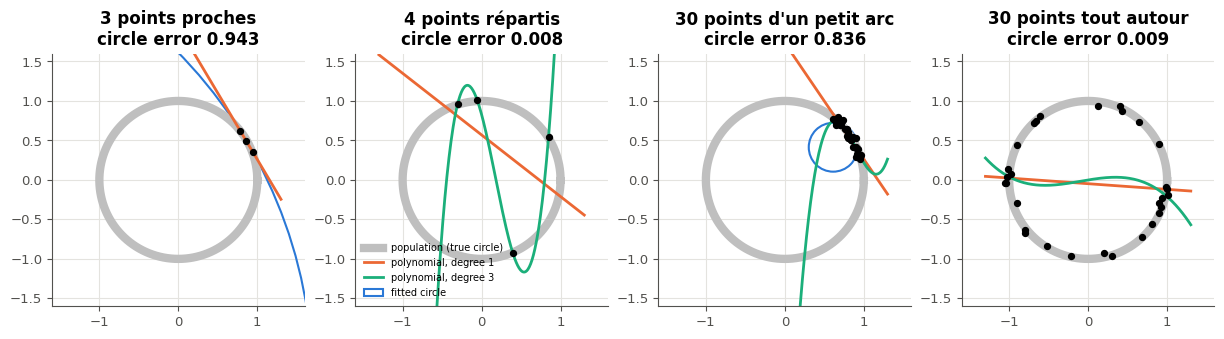

{'3 points proches': 0.943, '4 points répartis': 0.008, "30 points d'un petit arc": 0.836, '30 points tout autour': 0.009}
✅ Ex 11.18 : le bon modèle généralise avec un échantillon représentatif, pas avec un échantillon biaisé.


In [40]:
def fit_circle_18(points):
    """The circle (cx, cy, r) that fits the points best in the algebraic sense: solve x² + y² + D x + E y + F = 0
    by least squares for D, E, F, then cx = -D/2, cy = -E/2, r = sqrt(cx² + cy² - F)."""
    points = np.asarray(points, dtype=float)
    x, y = points[:, 0], points[:, 1]
    A = np.column_stack([x, y, np.ones_like(x)])
    (D, E, F), *_ = np.linalg.lstsq(A, -(x ** 2 + y ** 2), rcond=None)
    cx, cy = -D / 2, -E / 2
    return float(cx), float(cy), float(np.sqrt(cx ** 2 + cy ** 2 - F))

if True:
    exact_18 = fit_circle_18(CIRCLE_18[::50] * 2.0 + np.array([1.0, -3.0]))   # 8 exact points of a circle (1, -3), r = 2
    if returned("11.18", "fit_circle_18", exact_18):
        verdict("11.18", np.allclose(exact_18, (1.0, -3.0, 2.0), atol=1e-8),
                "sur des points exacts, le cercle de centre (1, −3) et de rayon 2 est retrouvé.",
                f"sur 8 points exacts du cercle de centre (1, −3) et de rayon 2, reçu {np.round(exact_18, 4).tolist()}.")
        fig_18, axes_18 = plt.subplots(1, 4, figsize=(15, 4))
        xs_18 = np.linspace(-1.3, 1.3, 300)
        errors_18 = {}
        for ax_18, (name_18, points_18) in zip(axes_18, SCENARIOS_18.items()):
            cx_18, cy_18, r_18 = fit_circle_18(points_18)
            errors_18[name_18] = circle_error_18(cx_18, cy_18, r_18)
            ax_18.plot(CIRCLE_18[:, 0], CIRCLE_18[:, 1], color="0.75", lw=6, label="population (true circle)")
            for degree_18, color_18 in ((1, "C1"), (3, "C2")):
                if len(points_18) > degree_18:
                    coefs_18 = np.polyfit(points_18[:, 0], points_18[:, 1], degree_18)
                    ax_18.plot(xs_18, np.polyval(coefs_18, xs_18), color=color_18, label=f"polynomial, degree {degree_18}")
            ax_18.add_patch(plt.Circle((cx_18, cy_18), r_18, fill=False, color="C0", lw=1.5, label="fitted circle"))
            ax_18.scatter(points_18[:, 0], points_18[:, 1], color="black", zorder=4, s=18)
            ax_18.set(xlim=(-1.6, 1.6), ylim=(-1.6, 1.6), aspect="equal",
                      title=f"{name_18}\ncircle error {errors_18[name_18]:.3f}")
        axes_18[1].legend(fontsize=7, loc="lower left")    # the panel where all three models are drawn
        plt.show()
        print({name: round(error, 3) for name, error in errors_18.items()})
        verdict("11.18", errors_18["30 points tout autour"] < 0.03 and errors_18["30 points d'un petit arc"] > 0.3,
                "le bon modèle généralise avec un échantillon représentatif, pas avec un échantillon biaisé.",
                "les erreurs ne ressemblent pas à celles attendues : vérifie ton ajustement sur chaque scénario.")

💡 Avec 3 points proches, le cercle ajusté a un rayon de près de 6 (erreur 0,94) : le bruit, minuscule, suffit à tordre la courbure, et la droite paraît même plus convaincante (une **généralisation hâtive** : trop peu de points, tous au même endroit). Avec 4 points répartis, le cercle est retrouvé à moins d'un centième, mais le polynôme de degré 3 passe par les 4 points en dessinant une courbe en S : avec une représentation inadaptée, peu de points mènent à une **généralisation abusive** (la figure 11.10 (b) du livre). Avec 30 points d'un petit arc, le cercle se trompe lourdement (rayon 0,31, erreur 0,84) : c'est un **échantillon biaisé**. Avec 30 points tout autour, l'erreur tombe sous 0,01. Les scénarios 1 et 3 ont le même défaut, un arc trop court : avec cet ajustement, 300 ou 3 000 points tirés du même arc laissent l'erreur vers 0,86 pour l'arc du scénario 1 et vers 0,94 pour celui du scénario 3 (médianes sur 200 tirages), car les points ajoutés répètent la même information, celle d'un petit morceau du cercle. Deux leçons : une représentation adaptée (le cercle) généralise à partir de peu de points bien placés (scénario 2), et aucune représentation ne sauve un échantillon qui ne couvre pas la population. Plus de données réduisent le hasard du tirage ; elles ne remplacent pas les parties de la population qu'on n'observe jamais.

## Partie D · Les bandits dans mylearn

Tu écris `mylearn/bandit.py` : deux bandits (11.19), les briques d'un agent (11.20), la boucle d'interaction (11.21) et deux stratégies d'exploration (11.23). Entre les deux, une prédiction sur les valeurs initiales optimistes (11.22). Les tests comparent tes fonctions à NumPy et SciPy (lois des grands nombres, tests du χ² sur des fréquences de choix, formule d'UCB écrite à part).

### Ex 11.19 — BernoulliBandit et GaussianBandit 🔨 ★★ ⏱️ 20 min
**Objectif :** programmer deux bandits manchots dont les tirages sont reproductibles.  
**Prérequis :** ch. 2 (loi de Bernoulli, loi normale, graine) · fiche §11.7 (le bandit manchot) · **Fil rouge :** bandit · **mylearn :** `bandit.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/bandit.py` (créé par `python tools/start_chapter.py 11`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy seulement : NumPy et SciPy sont les **oracles** des tests (lois des grands nombres, test du χ² sur des fréquences de choix, formules écrites à part). La cellule de vérification recharge ta librairie, montre quelques résultats, puis lance les tests de tes fonctions ; `python -m pytest tests/test_ch11_bandit.py -q` les lance tous dans un terminal.

Les constructeurs sont **fournis** (ils vérifient les moyennes et rangent `means`, `n_arms`, `best_arm`, `best_mean` et un générateur `self._rng` créé à partir de `random_state`). Écris la méthode `pull(arm)` de chaque classe :
- `BernoulliBandit.pull(arm)` : `1.0` avec la probabilité `means[arm]`, sinon `0.0` (une comparaison avec `self._rng.random()` suffit) ;
- `GaussianBandit.pull(arm)` : un tirage de la loi normale de moyenne `means[arm]` et d'écart-type `self.std` ;
- les deux renvoient un `float` Python et lèvent une `IndexError` si `arm` n'est pas un bras (de 0 à `n_arms - 1`) : en Python, un indice négatif serait accepté en silence.

La vérification essaie l'exemple de la docstring, tire 4 000 fois chaque bras et compare les moyennes aux vraies valeurs, puis lance les tests.

Dans tes notes : pourquoi chaque bandit a-t-il son propre générateur, au lieu du `np.random` global ? Pourquoi refuser `arm = -1` ?

In [41]:
if True:
    bandit_19 = mylearn.bandit.BernoulliBandit([0.2, 0.5, 0.9], random_state=0)
    print("n_arms, best_arm, best_mean:", bandit_19.n_arms, bandit_19.best_arm, bandit_19.best_mean)
    print("10 pulls of arm 2:", [bandit_19.pull(2) for _ in range(10)])
    means_19 = [float(np.mean([bandit_19.pull(arm) for _ in range(4000)])) for arm in range(3)]
    print("mean of 4,000 pulls of each arm:", np.round(means_19, 3).tolist())
    gauss_19 = mylearn.bandit.GaussianBandit([0.0, 1.5, -0.5], std=1.0, random_state=0)
    draws_19 = np.array([gauss_19.pull(1) for _ in range(4000)])
    print(f"Gaussian bandit, arm 1: mean {draws_19.mean():.3f}, standard deviation {draws_19.std():.3f} (expected 1.5 and 1)")
    verdict("11.19", all(abs(m - p) < 0.03 for m, p in zip(means_19, (0.2, 0.5, 0.9))) and abs(draws_19.mean() - 1.5) < 0.06
            and abs(draws_19.std() - 1.0) < 0.06,
            "les moyennes des tirages s'approchent des vraies valeurs (loi des grands nombres, ch. 2).",
            "les moyennes des tirages s'éloignent trop des vraies valeurs : un bras de Bernoulli de paramètre p rapporte 1 "
            "avec la probabilité p, un bras gaussien N(mean, std²).")
    run_mylearn_tests(impl="ref", keyword="test_bernoulli_bandit_ or test_gaussian_bandit_")

n_arms, best_arm, best_mean: 3 2 0.9
10 pulls of arm 2: [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0]
mean of 4,000 pulls of each arm: [0.208, 0.494, 0.9]
Gaussian bandit, arm 1: mean 1.485, standard deviation 0.998 (expected 1.5 and 1)
✅ Ex 11.19 : les moyennes des tirages s'approchent des vraies valeurs (loi des grands nombres, ch. 2).


pytest: 14 passed, 57 deselected in 0.89s


💡 `pull` vérifie `0 <= arm < self.n_arms` (sinon `IndexError`), puis renvoie `float(self._rng.random() < self.means[arm])` ou `float(self._rng.normal(self.means[arm], self.std))`. Un générateur propre à chaque bandit rend les expériences reproductibles et indépendantes du reste du programme : deux bandits créés avec la même graine donnent les mêmes récompenses, quoi qu'aient tiré les autres parties du code. Refuser `-1` évite une erreur silencieuse : `means[-1]` existe en Python (c'est le dernier bras), et une politique boguée qui renverrait $-1$ jouerait le dernier bras sans que rien ne le signale.

### Ex 11.20 — argmax_random_tie, epsilon_greedy_action et incremental_update 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire les trois briques d'un agent : choisir le meilleur sans favoritisme, explorer avec la probabilité ε, mettre à jour une estimation.  
**Prérequis :** Ex 11.2 · Ex 11.19 · fiche §11.7 (encadré 🧮 sur les bandits) · **Fil rouge :** bandit · **mylearn :** `bandit.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/bandit.py`, mêmes règles qu'en 11.19 (NumPy seulement). Enregistre, puis relance la cellule de vérification.

Écris :
- `argmax_random_tie(values, rng=None)` : l'indice d'un maximum, tiré **uniformément** parmi les ex aequo (`np.flatnonzero(values == values.max())`, puis `rng.choice`) ; une `ValueError` si `values` est vide ou contient `nan` ;
- `epsilon_greedy_action(q_values, epsilon, rng=None)` : avec la probabilité `epsilon` (un tirage `rng.random() < epsilon`), un bras uniforme parmi **tous** les bras ; sinon `argmax_random_tie(q_values, rng)` ; une `ValueError` si `epsilon` n'est pas entre 0 et 1, `nan` compris (une comparaison avec `nan` est toujours fausse : teste-le à part, avec `math.isnan` ou `np.isnan`) ;
- `incremental_update(estimate, target, step_size)` : `estimate + step_size * (target - estimate)` ; une `ValueError` si `step_size` n'est pas dans $]0, 1]$. Avec `step_size = 1/n`, c'est la moyenne incrémentale de ∂ 11.2.

Si `rng` vaut `None`, crée un générateur avec `np.random.default_rng()`. La vérification montre quelques appels (des égalités, 10 000 choix ε-greedy, la moyenne courante de 4, 2, 6), puis lance les tests.

Dans tes notes : pourquoi `np.argmax` seul ne convient-il pas au début d'une partie ? Avec $\varepsilon = 0{,}2$ et 4 bras, pourquoi le meilleur bras est-il choisi 85 % du temps, et pas 80 % ?

In [42]:
if True:
    rng_20 = np.random.default_rng(0)
    print("argmax_random_tie([1, 3, 2]) =", mylearn.bandit.argmax_random_tie([1.0, 3.0, 2.0], rng_20))
    ties_20 = collections.Counter(int(mylearn.bandit.argmax_random_tie([0.5, 0.9, 0.9, 0.1, 0.9], rng_20)) for _ in range(3000))
    print("ties between arms 1, 2 and 4, 3,000 calls:", dict(sorted(ties_20.items())))
    choices_20 = collections.Counter(int(mylearn.bandit.epsilon_greedy_action([0.2, 0.9, 0.5, 0.1], 0.2, rng_20))
                                     for _ in range(10_000))
    print("epsilon-greedy (epsilon = 0.2, best arm 1), 10,000 choices:", dict(sorted(choices_20.items())))
    q_20 = 0.0
    for n_20, reward_20 in enumerate([4.0, 2.0, 6.0], start=1):
        q_20 = mylearn.bandit.incremental_update(q_20, reward_20, 1 / n_20)
        print(f"after reward {reward_20:g}: estimate {q_20:g}")
    verdict("11.20", set(ties_20) == {1, 2, 4} and min(ties_20.values()) > 850
            and abs(choices_20[1] / 10_000 - 0.85) < 0.02 and abs(q_20 - 4.0) < 1e-12,
            "égalités tirées au sort, meilleur bras choisi 85 % du temps (1 − ε + ε/K), moyenne courante juste.",
            "un des trois résultats est faux : égalités réparties entre 1, 2 et 4 ? meilleur bras environ 85 % du "
            "temps ? moyenne courante de 4, 2, 6 égale à 4 ?")
    run_mylearn_tests(impl="ref", keyword="test_argmax_random_tie_ or test_epsilon_greedy_action_ or test_incremental_update_")

argmax_random_tie([1, 3, 2]) = 1
ties between arms 1, 2 and 4, 3,000 calls: {1: 962, 2: 995, 4: 1043}
epsilon-greedy (epsilon = 0.2, best arm 1), 10,000 choices: {0: 493, 1: 8473, 2: 519, 3: 515}
after reward 4: estimate 4
after reward 2: estimate 3
after reward 6: estimate 4
✅ Ex 11.20 : égalités tirées au sort, meilleur bras choisi 85 % du temps (1 − ε + ε/K), moyenne courante juste.


pytest: 27 passed, 44 deselected in 1.66s


💡 `np.argmax` renvoie toujours le **premier** maximum : au début, quand toutes les estimations valent 0, un agent glouton jouerait toujours le bras 0, et ✏️ 11.8 j) montre qu'il peut y rester. Tirer au sort parmi les ex aequo évite ce favoritisme. En ε-greedy, l'exploration tire un bras parmi **les 4**, meilleur compris : le meilleur est choisi avec la probabilité $1 - \varepsilon + \varepsilon/K = 0{,}8 + 0{,}05 = 0{,}85$. `incremental_update` tient en une ligne ; c'est exactement la forme d'une mise à jour par différence temporelle du ch. 26 : nouvelle estimation = ancienne + pas × (cible − ancienne).

### Ex 11.21 — run_bandit : la boucle d'interaction et ses courbes 🔨 ★★★ ⏱️ 40 min
**Objectif :** programmer la boucle agent-environnement d'un bandit, puis retrouver les courbes de 📈 11.10 avec son propre code.  
**Prérequis :** Ex 11.20 · Ex 11.10 · fiche §11.7 (encadré 🧮 : estimer, choisir, mesurer le regret) · **Fil rouge :** bandit · **mylearn :** `bandit.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/bandit.py`, mêmes règles qu'en 11.19 (NumPy seulement). Enregistre, puis relance la cellule de vérification.

Écris `run_bandit(bandit, select_action, n_steps=1000, step_size=None, initial_value=0.0, rng=None)`, la boucle d'interaction (lis sa docstring). À chaque pas $t = 1, \dots, n$ :
1. `arm = select_action(q_values, counts, t, rng)` : la politique reçoit les estimations et les compteurs **avant** le pas (et ne doit pas les modifier) ; lève une `ValueError` si elle renvoie un bras inexistant ;
2. `reward = bandit.pull(arm)`, puis `counts[arm] += 1` ;
3. `q_values[arm] = incremental_update(q_values[arm], reward, step)` avec `step = 1 / counts[arm]` si `step_size` vaut `None`, sinon `step = step_size`.

Le dictionnaire renvoyé contient les bras joués, les récompenses, `optimal` (le bras joué avait-il la meilleure moyenne ?), le **pseudo-regret cumulé** (`np.cumsum` des écarts $q_* - q_*(A_t)$, calculés avec `bandit.means`), et les estimations et compteurs finaux.

Écris ensuite `testbed_21(epsilon, n_runs, n_steps, seed)`, qui fait jouer l'agent ε-greedy de **ta** librairie sur `n_runs` bandits gaussiens à 10 bras, dont les moyennes sont tirées de $\mathcal{N}(0, 1)$, et renvoie la récompense moyenne et la part d'action optimale à chaque pas (moyennes sur les parties). Tire les moyennes, la graine de chaque bandit et celle de chaque politique du générateur `rng` créé au début : la courbe est alors reproductible.

La vérification essaie l'exemple de la docstring et lance les tests ; la cellule suivante trace tes courbes pour $\varepsilon = 0$, $0{,}01$ et $0{,}1$ (200 parties en FAST_MODE, 2 000 sinon).

Dans tes notes : compare tes courbes à la figure de 📈 11.10. Pourquoi la politique reçoit-elle les compteurs, alors qu'ε-greedy ne s'en sert pas ? Pourquoi calculer le regret avec les moyennes plutôt qu'avec les récompenses tirées ?

In [43]:
N_RUNS_21 = wb.by_mode(fast=200, full=2000)


def testbed_21(epsilon, n_runs=N_RUNS_21, n_steps=1000, seed=21):
    """The epsilon-greedy agent of YOUR mylearn.bandit (run_bandit, epsilon_greedy_action) on n_runs Gaussian bandits
    with 10 arms whose means are drawn from N(0, 1) (rewards of standard deviation 1). Returns two arrays of shape
    (n_steps,): the mean reward and the share of optimal actions at each step, over the n_runs games."""
    rng = np.random.default_rng(seed)       # draw the means, the seed of each bandit and of each policy from it
    policy = lambda q, n, t, g: mylearn.bandit.epsilon_greedy_action(q, epsilon, g)
    rewards, optimal = np.zeros(n_steps), np.zeros(n_steps)
    for _ in range(n_runs):
        bandit = mylearn.bandit.GaussianBandit(rng.normal(0.0, 1.0, size=10), std=1.0,
                                               random_state=int(rng.integers(2 ** 32)))
        history = mylearn.bandit.run_bandit(bandit, policy, n_steps=n_steps,
                                            rng=np.random.default_rng(int(rng.integers(2 ** 32))))
        rewards += history["rewards"]
        optimal += history["optimal"]
    return rewards / n_runs, optimal / n_runs

if True:
    history_21 = mylearn.bandit.run_bandit(mylearn.bandit.BernoulliBandit([0.25, 0.75], random_state=0),
                                           lambda q, n, t, g: 0, n_steps=4)
    if returned("11.21", "run_bandit", history_21):
        print("docstring example: counts", history_21["counts"], "· regret", history_21["regret"])
    run_mylearn_tests(impl="ref", keyword="test_run_bandit_")

docstring example: counts [4 0] · regret [0.5 1.  1.5 2. ]


pytest: 13 passed, 58 deselected in 0.53s


200 games of 1,000 steps for each epsilon (6 s)
epsilon = 0.0: mean reward over the last 100 steps 1.006, optimal actions 30.0%
epsilon = 0.01: mean reward over the last 100 steps 1.245, optimal actions 53.4%
epsilon = 0.1: mean reward over the last 100 steps 1.324, optimal actions 78.2%


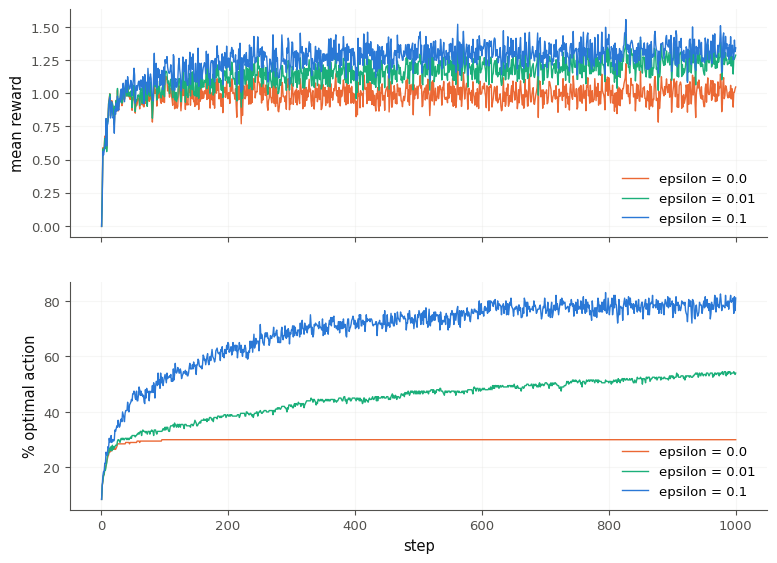

✅ Ex 11.21 : les courbes ressemblent à celles de 📈 11.10 : ε = 0,1 dépasse 70 % d'action optimale, le glouton reste sous 45 %.


In [44]:
with wb.attempt("11.21"):
    start_21 = time.perf_counter()
    curves_21 = {epsilon: testbed_21(epsilon) for epsilon in (0.0, 0.01, 0.1)}
    print(f"{N_RUNS_21} games of 1,000 steps for each epsilon ({time.perf_counter() - start_21:.0f} s)")
    fig_21, axes_21 = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
    colors_21 = {0.0: "C1", 0.01: "C2", 0.1: "C0"}             # the colours of the figure of 📈 11.10
    for epsilon, (reward_21, optimal_21) in curves_21.items():
        axes_21[0].plot(np.arange(1, 1001), reward_21, lw=1, color=colors_21[epsilon], label=f"epsilon = {epsilon}")
        axes_21[1].plot(np.arange(1, 1001), 100 * np.asarray(optimal_21), lw=1, color=colors_21[epsilon],
                        label=f"epsilon = {epsilon}")
        print(f"epsilon = {epsilon}: mean reward over the last 100 steps {np.mean(reward_21[-100:]):.3f}, "
              f"optimal actions {np.mean(optimal_21[-100:]):.1%}")
    axes_21[0].set(ylabel="mean reward")
    axes_21[1].set(xlabel="step", ylabel="% optimal action")
    for ax_21 in axes_21:
        ax_21.legend()
        ax_21.grid(alpha=0.3)
    plt.show()
    final_21 = {epsilon: float(np.mean(optimal_21[-100:])) for epsilon, (_, optimal_21) in curves_21.items()}
    verdict("11.21", final_21[0.1] > 0.7 and final_21[0.0] < 0.45,
            "les courbes ressemblent à celles de 📈 11.10 : ε = 0,1 dépasse 70 % d'action optimale, le glouton reste "
            "sous 45 %.",
            f"parts d'action optimale sur les 100 derniers pas : {final_21} ; attendu plus de 0,7 pour ε = 0,1 et moins de "
            "0,45 pour ε = 0 (compare avec la figure de 📈 11.10).")

💡 La boucle de la référence suit la docstring à la lettre ; le regret se calcule à la fin, en une ligne : `np.cumsum(bandit.best_mean - means[actions])`. Les courbes ressemblent à celles de 📈 11.10 (le glouton plafonne vers un tiers d'action optimale, ε = 0,1 approche 80 % au pas 1 000), avec plus de bruit en FAST_MODE (200 parties au lieu de 2 000). La politique reçoit les compteurs parce qu'UCB en a besoin (11.23), et Thompson aussi : une même boucle sert ainsi toutes les stratégies. Le regret calculé avec les moyennes (*pseudo-regret*) ne dépend pas de la chance des tirages : il mesure la qualité des **décisions**, et il ne décroît jamais.

### Ex 11.22 — Initialisation optimiste sans ε : prédire, puis mesurer 🔮 ★★★ ⏱️ 30 min
**Objectif :** prévoir l'effet d'estimations initiales optimistes sur l'exploration d'un agent glouton, avant de le mesurer.  
**Prérequis :** Ex 11.21 · Ex 11.2 · fiche §11.7 (encadré 🧮 : initialisation optimiste) · **Fil rouge :** bandit · **Parcours :** C

On compare trois agents sur des bandits gaussiens à 10 bras (moyennes tirées de $\mathcal{N}(0, 1)$, récompenses d'écart-type 1), avec ta fonction `run_bandit` :
- l'agent **optimiste** : estimations initiales $Q_1 = 5$ (bien au-dessus de toute moyenne plausible), **aucune** exploration ($\varepsilon = 0$, ex aequo tirés au sort), pas constant $\alpha = 0{,}1$ ;
- l'agent **réaliste** : $Q_1 = 0$, ε-greedy avec $\varepsilon = 0{,}1$, pas constant $\alpha = 0{,}1$ ;
- l'agent optimiste, mais avec des **moyennes exactes** (`step_size=None`) au lieu du pas constant.

Prédis, **avant** d'exécuter quoi que ce soit :
a) `optimistic_wins_22` : au pas 1 000, l'agent optimiste choisit-il l'action optimale plus souvent que l'agent réaliste ? (`True` ou `False`) ;
b) `spike_step_22` : pendant les premiers pas, la part d'action optimale de l'agent optimiste présente un pic très net. À quel pas ? (un entier) ;
c) `sample_average_22` : au pas 1 000, la part d'action optimale de l'agent optimiste à moyennes exactes est d'environ : `"A"` 35 % ; `"B"` 70 % ; `"C"` 86 % ; `"D"` 91 %.

Puis exécute l'expérience (300 parties par agent en FAST_MODE).

In [45]:
N_RUNS_22 = wb.by_mode(fast=300, full=2000)

AGENTS_22 = {   # name: (policy, keyword arguments of run_bandit)
    "optimistic: Q1 = 5, epsilon = 0, step 0.1": (lambda q, n, t, g: mylearn.bandit.argmax_random_tie(q, g),
                                                  {"initial_value": 5.0, "step_size": 0.1}),
    "realistic: Q1 = 0, epsilon = 0.1, step 0.1": (lambda q, n, t, g: mylearn.bandit.epsilon_greedy_action(q, 0.1, g),
                                                   {"initial_value": 0.0, "step_size": 0.1}),
    "optimistic: Q1 = 5, epsilon = 0, sample averages": (lambda q, n, t, g: mylearn.bandit.argmax_random_tie(q, g),
                                                         {"initial_value": 5.0, "step_size": None}),
}


def share_optimal_22(policy, run_kwargs, n_runs=N_RUNS_22, n_steps=1000, seed=22):
    """Share of optimal actions at each step over n_runs Gaussian 10-armed bandits (means from N(0, 1))."""
    rng = np.random.default_rng(seed)
    optimal = np.zeros(n_steps)
    for _ in range(n_runs):
        bandit = mylearn.bandit.GaussianBandit(rng.normal(0.0, 1.0, size=10), std=1.0,
                                               random_state=int(rng.integers(2 ** 32)))
        history = mylearn.bandit.run_bandit(bandit, policy, n_steps=n_steps,
                                            rng=np.random.default_rng(int(rng.integers(2 ** 32))), **run_kwargs)
        optimal += history["optimal"]
    return optimal / n_runs

In [46]:
optimistic_wins_22, spike_step_22, sample_average_22 = True, 11, "B"   # the answers, for the record

300 games of 1,000 steps per agent (8 s)
optimistic: Q1 = 5, epsilon = 0, step 0.1          optimal actions: step 10 10%, step 11 47%, step 12 26%, last 100 steps 83.5%
realistic: Q1 = 0, epsilon = 0.1, step 0.1         optimal actions: step 10 31%, step 11 33%, step 12 31%, last 100 steps 72.3%
optimistic: Q1 = 5, epsilon = 0, sample averages   optimal actions: step 10 10%, step 11 47%, step 12 49%, last 100 steps 68.7%


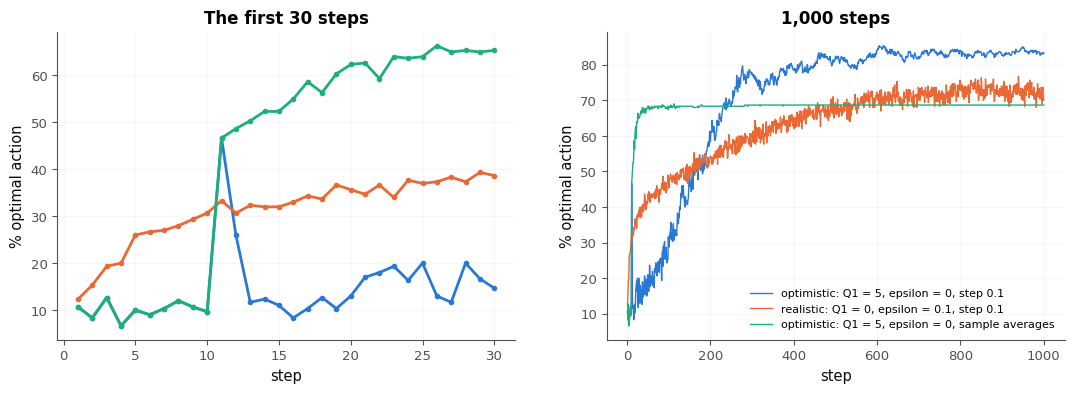

In [47]:
if any(answer is ... or answer is None for answer in [optimistic_wins_22, spike_step_22, sample_average_22]):
    print("⏳ Ex 11.22 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    with wb.attempt("11.22"):
        start_22 = time.perf_counter()
        curves_22 = {name: share_optimal_22(policy, kwargs) for name, (policy, kwargs) in AGENTS_22.items()}
        print(f"{N_RUNS_22} games of 1,000 steps per agent ({time.perf_counter() - start_22:.0f} s)")
        for name, curve in curves_22.items():
            print(f"{name:50s} optimal actions: step 10 {curve[9]:.0%}, step 11 {curve[10]:.0%}, step 12 {curve[11]:.0%}, "
                  f"last 100 steps {np.mean(curve[-100:]):.1%}")
        fig_22, axes_22 = plt.subplots(1, 2, figsize=(13, 4))
        for name, curve in curves_22.items():
            axes_22[0].plot(np.arange(1, 31), 100 * curve[:30], marker="o", ms=3, label=name)
            axes_22[1].plot(np.arange(1, 1001), 100 * curve, lw=1, label=name)
        axes_22[0].set(xlabel="step", ylabel="% optimal action", title="The first 30 steps")
        axes_22[1].set(xlabel="step", ylabel="% optimal action", title="1,000 steps")
        for ax_22 in axes_22:
            ax_22.grid(alpha=0.3)
        axes_22[1].legend(fontsize=8)
        plt.show()

Dans tes notes : compare avec tes prédictions. Pour chaque agent, explique la forme de sa courbe à partir de ce que deviennent ses estimations. Dans quel genre de problème l'initialisation optimiste serait-elle un mauvais choix ?

💡 L'agent optimiste gagne (a : `True`) : environ 84 % d'action optimale sur les 100 derniers pas, contre 72 % pour l'agent réaliste (300 parties en FAST_MODE), qui continue d'explorer au hasard 10 % du temps. Pendant les 10 premiers pas, l'agent optimiste essaie chaque bras une fois : chaque tirage fait baisser l'estimation du bras tiré, d'environ $5 \to 4{,}5$, sous celle des bras jamais tirés, qui restent à 5 ; la part d'action optimale vaut 10 % à chacun de ces pas. Au pas 11, il choisit le bras dont la première récompense était la plus forte, très souvent le meilleur : le pic (b : 11, environ 47 % d'action optimale). Le tirage suivant fait encore baisser ce bras sous les autres, et l'exploration reprend, jusqu'à ce que les estimations soient redescendues vers les vraies valeurs. Avec les moyennes exactes, le premier tirage de chaque bras **efface** la valeur initiale (le pas $1/1$ donne tout son poids à la récompense, ∂ 11.2) : l'agent explore une fois chaque bras, puis devient glouton sur des estimations d'un seul tirage, et plafonne vers 69 % (c : B). C'est déjà bien mieux que le glouton de 📈 11.10 (environ un tiers). L'initialisation optimiste n'explore qu'au début : elle ne convient pas à un problème **non stationnaire**, où les bras changent avec le temps et où il faut continuer d'explorer (Sutton et Barto, §2.6).

### Ex 11.23 — ucb_action et thompson_action 🔨 ★★★ ⏱️ 40 min
**Objectif :** programmer deux stratégies d'exploration dirigée : par une borne de confiance, puis par tirage dans le posterior.  
**Prérequis :** Ex 11.21 · ch. 4 (posterior Beta d'une pièce) · fiche §11.7 (encadré 🧮 : UCB et Thompson) · **Fil rouge :** bandit · **mylearn :** `bandit.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/bandit.py`, mêmes règles qu'en 11.19 (NumPy seulement). Enregistre, puis relance la cellule de vérification.

Écris :
- `ucb_action(q_values, counts, t, c=2.0)` : un bras jamais tiré d'abord (le plus petit indice) ; sinon l'indice du maximum de $Q(a) + c\sqrt{\ln t \,/\, N(a)}$ (le **premier** maximum en cas d'égalité : la règle est déterministe) ; une `ValueError` si les deux tableaux n'ont pas la même forme, si $t < 1$ ou si $c < 0$ ;
- `thompson_action(successes, failures, rng=None)` : tire $\theta_a \sim \mathrm{Beta}(1 + s_a, 1 + f_a)$ pour chaque bras (`rng.beta` accepte des tableaux) et renvoie l'indice du plus grand tirage ; une `ValueError` si les formes diffèrent ou si un compteur est négatif.

La vérification essaie les exemples de la docstring, compare les fréquences de choix de Thompson à celles de la figure de la fiche (trois bras : 6 succès et 4 échecs, 1 et 1, 18 et 22), puis lance les tests. La cellule suivante fait jouer ε-greedy, UCB1 et Thompson sur un bandit difficile (quatre bras proches).

Dans tes notes : avec `run_bandit` et des moyennes exactes, comment retrouver le nombre de succès d'un bras à partir de `q_values` et `counts` ? Pourquoi arrondir ? Sur le bandit difficile, quelle stratégie tire le plus le meilleur bras, et laquelle explore le plus longtemps ?

In [48]:
if True:
    print("ucb_action docstring examples:",
          mylearn.bandit.ucb_action([0.5, 0.0, 0.0], counts=[3, 0, 0], t=4),
          mylearn.bandit.ucb_action([0.5, 0.4], counts=[10, 1], t=11),
          mylearn.bandit.ucb_action([0.5, 0.4], counts=[10, 1], t=11, c=0.0), "(expected 1, 1, 0)")
    rng_23 = np.random.default_rng(23)
    picks_23 = collections.Counter(int(mylearn.bandit.thompson_action([6, 1, 18], [4, 1, 22], rng_23)) for _ in range(20_000))
    print("Thompson, the three arms of the course sheet (20,000 draws):", {arm: round(picks_23[arm] / 20_000, 3) for arm in range(3)})
    verdict("11.23", abs(picks_23[0] / 20_000 - 0.54) < 0.02 and abs(picks_23[1] / 20_000 - 0.36) < 0.02,
            "chaque bras est joué avec la probabilité qu'il soit le meilleur, comme sur la figure de la fiche "
            "(0,54, 0,36, 0,10).",
            "les fréquences s'éloignent de celles de la figure de la fiche (0,54, 0,36, 0,10) : le posterior d'un bras "
            "est Beta(1 + succès, 1 + échecs), et l'on joue le plus grand tirage.")
    run_mylearn_tests(impl="ref", keyword="test_ucb_action_ or test_thompson_action_")

ucb_action docstring examples: 1 1 0 (expected 1, 1, 0)


Thompson, the three arms of the course sheet (20,000 draws): {0: 0.545, 1: 0.356, 2: 0.099}
✅ Ex 11.23 : chaque bras est joué avec la probabilité qu'il soit le meilleur, comme sur la figure de la fiche (0,54, 0,36, 0,10).


pytest: 17 passed, 54 deselected in 4.18s


epsilon-greedy (0.1)   pulls of each arm: [66, 51, 1714, 169], final regret 100.7
UCB1 (c = sqrt 2)      pulls of each arm: [159, 283, 633, 925], final regret 83.8
Thompson               pulls of each arm: [39, 50, 312, 1599], final regret 26.5


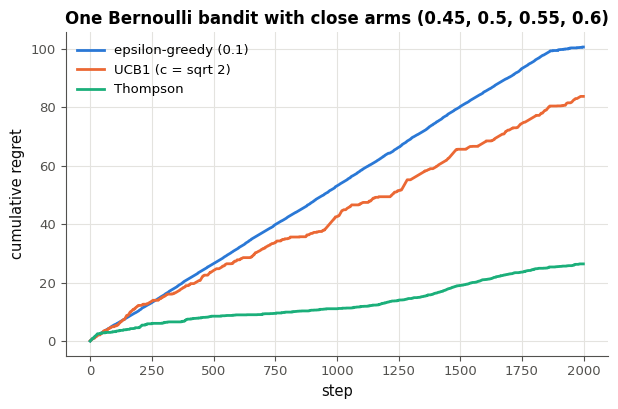

In [49]:
with wb.attempt("11.23"):
    demo_bandit_23 = lambda: mylearn.bandit.BernoulliBandit([0.45, 0.5, 0.55, 0.6], random_state=2323)
    agents_23 = {"epsilon-greedy (0.1)": lambda q, n, t, g: mylearn.bandit.epsilon_greedy_action(q, 0.1, g),
                 "UCB1 (c = sqrt 2)": lambda q, n, t, g: mylearn.bandit.ucb_action(q, n, t, c=math.sqrt(2)),
                 "Thompson": lambda q, n, t, g: mylearn.bandit.thompson_action(np.rint(q * n), n - np.rint(q * n), g)}
    for name_23, agent_23 in agents_23.items():
        history_23 = mylearn.bandit.run_bandit(demo_bandit_23(), agent_23, n_steps=2000, rng=np.random.default_rng(0))
        plt.plot(history_23["regret"], label=name_23)
        print(f"{name_23:22s} pulls of each arm: {history_23['counts'].tolist()}, final regret {history_23['regret'][-1]:.1f}")
    plt.xlabel("step")
    plt.ylabel("cumulative regret")
    plt.title("One Bernoulli bandit with close arms (0.45, 0.5, 0.55, 0.6)")
    plt.legend()
    plt.show()

💡 UCB : `untried = np.flatnonzero(counts == 0)` ; s'il y en a, on renvoie le premier ; sinon `np.argmax(q + c * np.sqrt(np.log(t) / counts))`. Le bonus ne divise jamais par zéro grâce au premier cas. Thompson : `np.argmax(rng.beta(1 + successes, 1 + failures))`. Avec des récompenses 0 ou 1 et des moyennes exactes, $Q(a) \times N(a)$ est le nombre de succès du bras ; on l'arrondit (`np.rint`) parce que la moyenne incrémentale accumule de petites erreurs d'arrondi (2,9999999 au lieu de 3). Sur le bandit difficile, Thompson tire le meilleur bras 1 599 fois sur 2 000 (regret 26,5) ; UCB1, dont le bonus décroît lentement (en $\sqrt{\ln t / N}$), répartit encore ses tirages entre les quatre bras (925 pour le meilleur, regret 83,8) ; ε-greedy s'est fixé sur le deuxième meilleur bras (1 714 tirages, regret 100,7) et n'en sortira que par hasard, en explorant. Le tournoi de 11.26 le mesure sur 100 bandits.

## Partie E · Déboguer, journaliser, comparer, et le défi

Quatre exercices de pratique : réparer l'agent d'un collègue (11.24), journaliser une expérience pour pouvoir la refaire (11.25), organiser un tournoi équitable entre stratégies (11.26), puis battre UCB1 (11.27). Les deux derniers utilisent des bandits « à bande » (`TapeBandit`, défini en 11.26) : leurs récompenses sont écrites d'avance, si bien que deux agents qui tirent les mêmes bras reçoivent les mêmes récompenses, ce qui rend la comparaison plus juste.

### Ex 11.24 — Bandit piégé : l'agent qui n'explore jamais 🐛 ★★★ ⏱️ 30 min
**Objectif :** diagnostiquer et corriger un agent ε-greedy bogué, en lisant son comportement plutôt que son code.  
**Prérequis :** Ex 11.20 · Ex 11.21 · fiche §11.7 (encadré 🧮 sur les bandits, tableau des pièges) · **Fil rouge :** bandit · **Parcours :** C

Un collègue a écrit un agent ε-greedy (`BuggyAgent24`, ci-dessous). Il affirme qu'il explore 10 % du temps ; pourtant, sur un bandit de moyennes 0,2, 0,5 et 0,8, son regret atteint 1 200 après 2 000 pas, celui d'un agent qui jouerait **toujours** le plus mauvais bras. Le code contient **quatre** bugs, dont certains en cachent d'autres.

Écris `FixedAgent24`, une sous-classe qui corrige les quatre bugs : garde les mêmes arguments de constructeur (`n_arms`, `epsilon`, `seed`) et les attributs `q` et `n`. La vérification lance quatre diagnostics, dans l'ordre où les bugs se masquent : chacun ne s'exécute que si les précédents passent.
1. l'agent explore-t-il, quand un bras est nettement meilleur ?
2. en explorant, peut-il choisir chaque bras ?
3. quand les estimations sont égales et $\varepsilon = 0$, tire-t-il au sort entre les ex aequo ?
4. ses estimations sont-elles les moyennes des récompenses de chaque bras ?

Puis un bilan : le regret de ton agent sur 2 000 pas, en moyenne sur 10 graines.

Dans tes notes : pour chaque bug, le symptôme, la cause et la correction. Pourquoi le premier bug masque-t-il les autres ? Pourquoi le quatrième ne se voit-il pas sur un agent qui ne joue qu'un bras ?

In [50]:
class BuggyAgent24:
    """A colleague's epsilon-greedy agent for a K-armed bandit: estimates start at 0, sample averages."""

    def __init__(self, n_arms, epsilon=0.1, seed=0):
        self.n_arms, self.epsilon, self.seed = n_arms, epsilon, seed
        self.q = np.zeros(n_arms)
        self.n = np.zeros(n_arms, dtype=int)
        self.t = 0

    def select(self):
        """The arm to pull now."""
        rng = np.random.default_rng(self.seed)
        if rng.random() < self.epsilon:
            return int(rng.integers(self.n_arms - 1))
        return int(np.argmax(self.q))

    def update(self, arm, reward):
        """Learn from the reward of `arm`."""
        self.t += 1
        self.q[arm] += (reward - self.q[arm]) / self.t
        self.n[arm] += 1


def play_24(agent, means, n_steps, seed):
    """Let `agent` play a Bernoulli bandit of the given means for n_steps; return the final pseudo-regret."""
    rng = np.random.default_rng(seed)
    means = np.asarray(means, dtype=float)
    regret = 0.0
    for _ in range(n_steps):
        arm = agent.select()
        agent.update(arm, float(rng.random() < means[arm]))
        regret += means.max() - means[arm]
    return regret


demo_24 = BuggyAgent24(3, epsilon=0.1, seed=0)
print("arms chosen by the colleague's agent, 20 steps:", [demo_24.select() for _ in range(20)])
print("its regret after 2,000 steps on arms (0.2, 0.5, 0.8):", round(play_24(BuggyAgent24(3), [0.2, 0.5, 0.8], 2000, 0), 1))

arms chosen by the colleague's agent, 20 steps: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


its regret after 2,000 steps on arms (0.2, 0.5, 0.8): 1200.0


In [51]:
class FixedAgent24(BuggyAgent24):
    """The colleague's agent, corrected (same constructor arguments): rewrite here what must change (four bugs)."""

    def __init__(self, n_arms, epsilon=0.1, seed=0):
        super().__init__(n_arms, epsilon, seed)
        self.rng = np.random.default_rng(seed)                      # bug 1: ONE generator, created once

    def select(self):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_arms))              # bug 2: every arm, the last one included
        best = np.flatnonzero(self.q == self.q.max())
        return int(self.rng.choice(best))                           # bug 3: ties broken at random

    def update(self, arm, reward):
        self.t += 1
        self.n[arm] += 1
        self.q[arm] += (reward - self.q[arm]) / self.n[arm]         # bug 4: 1/n(arm), not 1/t

def explores_24():
    """1. With a clear best arm, the agent still explores about epsilon × 2/3 of the time."""
    agent = FixedAgent24(3, epsilon=0.1, seed=1)
    agent.q = np.array([0.0, 0.0, 1.0])
    share = np.mean([agent.select() != 2 for _ in range(6000)])
    if share == 0:
        return ("ton agent n'explore jamais : relance select plusieurs fois ; tire-t-il toujours le même nombre ? Un "
                "générateur recréé à chaque appel avec la même graine redonne le même tirage. Crée-le une seule fois, "
                "dans __init__.")
    if not 0.045 <= share <= 0.09:
        return (f"ton agent quitte le meilleur bras dans {share:.1%} des choix, au lieu d'environ 6,7 % "
                "(ε = 0,1, et 2 bras sur 3 sont d'autres bras).")
    return ""


def all_arms_24():
    """2. When it explores, every arm can be chosen, the last one included."""
    agent = FixedAgent24(3, epsilon=0.3, seed=2)
    agent.q = np.array([1.0, 0.0, 0.0])
    share_last = np.mean([agent.select() == 2 for _ in range(6000)])
    if share_last == 0:
        return ("en explorant, ton agent ne choisit jamais le dernier bras : rng.integers(k) tire un entier de 0 à "
                "k − 1, k exclu.")
    if not 0.07 <= share_last <= 0.13:
        return f"le dernier bras est choisi dans {share_last:.1%} des cas, au lieu d'environ 10 % (ε / 3)."
    return ""


def ties_24():
    """3. With equal estimates and no exploration, the arm is drawn at random among the tied ones."""
    agent = FixedAgent24(3, epsilon=0.0, seed=3)
    counts = np.bincount([agent.select() for _ in range(3000)], minlength=3) / 3000
    if counts[0] > 0.9:
        return ("avec trois estimations égales et ε = 0, ton agent choisit toujours le bras 0 : np.argmax prend le "
                "premier maximum ; tire au sort parmi les ex aequo.")
    if not all(0.28 <= share <= 0.39 for share in counts):
        return f"avec trois estimations égales, les parts des bras valent {np.round(counts, 3).tolist()}, au lieu d'environ 1/3 chacune."
    return ""


def means_24():
    """4. The estimates are the sample averages of each arm."""
    agent = FixedAgent24(3, epsilon=0.1, seed=4)
    for arm, reward in [(0, 1.0), (1, 0.0), (0, 0.0), (2, 1.0), (0, 1.0), (1, 1.0)]:
        agent.update(arm, reward)
    if not (np.allclose(agent.q, [2 / 3, 1 / 2, 1.0]) and np.array_equal(agent.n, [3, 2, 1])):
        return (f"après six mises à jour, q = {np.round(agent.q, 3).tolist()} et n = {np.asarray(agent.n).tolist()}, au "
                "lieu des moyennes de chaque bras [0,667 ; 0,5 ; 1] et des compteurs [3, 2, 1] : la mise à jour divise "
                "par le nombre de tirages du bras (incrémenté avant).")
    return ""


DIAGNOSTICS_24 = [("l'exploration", explores_24, "ton agent explore à nouveau (environ 6,7 % des choix ailleurs que sur le meilleur bras)."),
                  ("les bras explorés", all_arms_24, "en explorant, chaque bras peut sortir, le dernier compris."),
                  ("les égalités", ties_24, "les ex aequo sont tirés au sort."),
                  ("les moyennes", means_24, "les estimations sont les moyennes de chaque bras.")]

if True:
    blocked_24 = None
    for number_24, (name_24, diagnostic_24, success_24) in enumerate(DIAGNOSTICS_24, start=1):
        if blocked_24 is not None:
            print(f"⏳ Ex 11.24 : {number_24}. {name_24} : corrige d'abord le point {blocked_24}.")
            continue
        try:
            problem_24 = diagnostic_24()
        except NotImplementedError:
            raise
        except Exception as error_24:                 # a crash of your agent: say which diagnostic it broke
            problem_24 = f"ton agent lève {type(error_24).__name__} ({error_24})."
        verdict("11.24", not problem_24, f"{number_24}. {success_24}", f"{number_24}. {problem_24}")
        if problem_24:
            blocked_24 = number_24
    if blocked_24 is None:
        regrets_24 = [play_24(FixedAgent24(3, epsilon=0.1, seed=seed), [0.2, 0.5, 0.8], 2000, seed) for seed in range(10)]
        verdict("11.24", np.mean(regrets_24) < 150,
                f"bilan : regret moyen {np.mean(regrets_24):.1f} après 2 000 pas, contre 1 200 pour l'agent du collègue.",
                f"bilan : regret moyen {np.mean(regrets_24):.1f} après 2 000 pas : encore trop élevé.")

✅ Ex 11.24 : 1. ton agent explore à nouveau (environ 6,7 % des choix ailleurs que sur le meilleur bras).
✅ Ex 11.24 : 2. en explorant, chaque bras peut sortir, le dernier compris.
✅ Ex 11.24 : 3. les ex aequo sont tirés au sort.
✅ Ex 11.24 : 4. les estimations sont les moyennes de chaque bras.


✅ Ex 11.24 : bilan : regret moyen 70.3 après 2 000 pas, contre 1 200 pour l'agent du collègue.


💡 Bug 1 : `np.random.default_rng(self.seed)` est recréé à chaque appel de `select`, avec la même graine : le « hasard » redonne toujours le même nombre (0,637 pour la graine 0, au-dessus de ε = 0,1), et l'agent n'explore jamais. On crée le générateur **une fois**, dans `__init__`. Bug 2 : `rng.integers(self.n_arms - 1)` tire de 0 à $K - 2$ : le dernier bras n'est jamais exploré (`rng.integers(self.n_arms)`). Bug 3 : `np.argmax` donne toujours le premier ex aequo ; au départ, avec des estimations nulles, l'agent joue le bras 0, et comme ses récompenses sont positives ou nulles, il y reste (✏️ 11.8 j). On tire au sort parmi les ex aequo. Bug 4 : la moyenne divise par `self.t`, le nombre total de pas, au lieu du nombre de tirages **du bras** : les estimations sont faussées dès que l'agent alterne. Le bug 1 masque les autres, parce qu'un agent qui n'explore jamais ne tire jamais au hasard (bug 2 invisible) et reste sur le bras 0 (bug 3 sans conséquence nouvelle). Le bug 4 est invisible tant que l'agent ne joue qu'un bras : $t$ et $n(a)$ sont alors égaux. Corrigé, l'agent fait un regret d'environ 70 sur 2 000 pas, contre 1 200.

### Ex 11.25 — Un journal d'expériences reproductible (JSON) 🛠️ ★★★ ⏱️ 30 min
**Objectif :** enregistrer une expérience (graine, hyperparamètres, versions, résultats) dans un fichier JSON qui permet de la refaire et de vérifier qu'on retrouve les mêmes résultats.  
**Prérequis :** Ex 11.21 · 0A (module json, pathlib, subprocess) · ch. 8 (graines et reproductibilité) · **Fil rouge :** bandit · **Parcours :** C

Une expérience qu'on ne peut pas refaire ne prouve pas grand-chose. En entreprise, chaque entraînement laisse une trace : la configuration (graines et hyperparamètres), les versions des logiciels, le commit git du code, la date et les résultats. Des outils spécialisés le font (MLflow, Weights & Biases) ; ici, un simple fichier JSON. Écris :
- `run_experiment_25(config)` : l'expérience décrite par `config` (le dictionnaire `CONFIG_25` : graine, nombre de parties, nombre de pas, nombre de bras, ε), avec **ta** librairie : à chaque partie, un `BernoulliBandit` neuf dont les moyennes sont tirées uniformément dans $[0, 1]$, joué par ε-greedy. **Tous** les tirages viennent du générateur `np.random.default_rng(config["seed"])` (les moyennes, la graine de chaque bandit, celle de chaque politique). Elle renvoie un dictionnaire de `float` Python : le regret final moyen, son erreur type, la part d'action optimale sur les 100 derniers pas ;
- `log_experiment_25(path, config, results)` : écrit dans `path` un JSON lisible (`json.dumps(..., indent=2)`) avec `"config"`, `"results"`, `"versions"` (au moins `"python"` et `"numpy"`), `"date"` (au format ISO 8601) et, si `git rev-parse HEAD` répond (avec `subprocess.run`), `"git_commit"` ; renvoie ce dictionnaire ;
- `rerun_25(path)` : relit le journal, relance l'expérience et renvoie `True` si les résultats sont **exactement** les mêmes.

La vérification écrit le journal dans un dossier temporaire, le relit, vérifie son contenu et sa date, relance l'expérience, change la graine, puis falsifie un résultat pour voir si `rerun_25` s'en aperçoit.

Dans tes notes : pourquoi `json.dumps` refuse-t-il un `np.float32` ou un `np.int64`, et que faire ? Qu'est-ce qui pourrait empêcher de retrouver les mêmes résultats sur un autre ordinateur, ou dans un an, même avec la bonne graine ? Où rangerais-tu ces journaux dans ton projet ?

In [52]:
CONFIG_25 = {"seed": 2025, "n_runs": 20, "n_steps": 500, "n_arms": 5, "epsilon": 0.1}
RESULT_KEYS_25 = ("mean_final_regret", "se_final_regret", "optimal_last_100")

In [53]:
import datetime
import platform


def run_experiment_25(config):
    """Run with YOUR mylearn.bandit the experiment described by `config`: config["n_runs"] games of config["n_steps"]
    steps, each on a new BernoulliBandit with config["n_arms"] arms whose means are drawn uniformly in [0, 1], played
    by epsilon-greedy (config["epsilon"]); every random draw comes from np.random.default_rng(config["seed"]). Return
    a dict of Python floats with the keys of RESULT_KEYS_25: the mean final regret, its standard error, and the share
    of optimal actions over the last 100 steps (all games)."""
    rng = np.random.default_rng(config["seed"])
    policy = lambda q, n, t, g: mylearn.bandit.epsilon_greedy_action(q, config["epsilon"], g)
    finals, optimal = [], []
    for _ in range(config["n_runs"]):
        bandit = mylearn.bandit.BernoulliBandit(rng.random(config["n_arms"]), random_state=int(rng.integers(2 ** 32)))
        history = mylearn.bandit.run_bandit(bandit, policy, n_steps=config["n_steps"],
                                            rng=np.random.default_rng(int(rng.integers(2 ** 32))))
        finals.append(history["regret"][-1])
        optimal.append(np.mean(history["optimal"][-100:]))
    return {"mean_final_regret": float(np.mean(finals)),
            "se_final_regret": float(np.std(finals, ddof=1) / np.sqrt(len(finals))),
            "optimal_last_100": float(np.mean(optimal))}


def log_experiment_25(path, config, results):
    """Write to `path` a JSON record of the experiment and return it (a dict): "config", "results", "versions" (at
    least "python" and "numpy"), "date" (ISO 8601) and, if git answers, "git_commit"."""
    record = {"config": config, "results": results,
              "versions": {"python": platform.python_version(), "numpy": np.__version__},
              "date": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds")}
    git = subprocess.run(["git", "-C", str(ROOT), "rev-parse", "HEAD"], capture_output=True, text=True)
    if git.returncode == 0:
        record["git_commit"] = git.stdout.strip()
    Path(path).write_text(json.dumps(record, indent=2, ensure_ascii=False), encoding="utf-8")
    return record


def rerun_25(path):
    """Read the JSON record at `path`, rerun its experiment and return True if the results are exactly the same."""
    record = json.loads(Path(path).read_text(encoding="utf-8"))
    return run_experiment_25(record["config"]) == record["results"]

if True:
    import datetime
    folder_25 = Path(tempfile.mkdtemp(prefix="journal_11_25_"))     # a temporary folder, not your repository
    path_25 = folder_25 / "experiment.json"
    results_25 = run_experiment_25(CONFIG_25)
    if returned("11.25", "run_experiment_25", results_25):
        print("results:", results_25)
        plain_25 = isinstance(results_25, dict) and all(type(results_25.get(key)) is float for key in RESULT_KEYS_25)
        verdict("11.25", plain_25, "les trois résultats sont des float Python.",
                f"attendu un dict de float Python pour les clés {RESULT_KEYS_25} : un np.float32 ou un np.int64 ne passe "
                "pas en JSON ; convertis avec float(...).")
        record_25 = log_experiment_25(path_25, CONFIG_25, results_25)
        if plain_25 and path_25.exists():
            text_25 = path_25.read_text(encoding="utf-8")
            print(text_25[:700])
            loaded_25 = json.loads(text_25)
            missing_25 = [key for key in ("config", "results", "versions", "date") if key not in loaded_25]
            versions_25 = loaded_25.get("versions", {})
            verdict("11.25", not missing_25 and loaded_25["config"] == CONFIG_25 and loaded_25["results"] == results_25
                    and isinstance(versions_25, dict) and {"python", "numpy"} <= set(versions_25),
                    "le journal contient la configuration, les résultats, les versions et la date.",
                    f"il manque {missing_25 or 'quelque chose'} : le journal doit contenir config et results tels quels, "
                    "versions (avec python et numpy) et date.")
            try:
                datetime.datetime.fromisoformat(loaded_25.get("date", ""))
                date_ok_25 = True
            except (TypeError, ValueError):
                date_ok_25 = False
            verdict("11.25", date_ok_25, "la date est au format ISO 8601.",
                    "la date doit être au format ISO 8601 (datetime.datetime.now(...).isoformat()).")
            verdict("11.25", rerun_25(path_25) is True, "relancée depuis le journal, l'expérience redonne exactement les "
                    "mêmes résultats.", "relancée depuis le journal, l'expérience ne redonne pas les mêmes résultats : "
                    "tous les tirages viennent-ils du générateur créé avec config['seed'] ?")
            other_25 = run_experiment_25(dict(CONFIG_25, seed=CONFIG_25["seed"] + 1))
            verdict("11.25", other_25 != results_25, "une autre graine donne d'autres résultats.",
                    "une autre graine donne les mêmes résultats : la graine de la configuration est-elle utilisée ?")
            tampered_25 = dict(loaded_25, results=dict(loaded_25["results"], mean_final_regret=loaded_25["results"]["mean_final_regret"] + 1))
            (folder_25 / "tampered.json").write_text(json.dumps(tampered_25), encoding="utf-8")
            verdict("11.25", rerun_25(folder_25 / "tampered.json") is False,
                    "un journal falsifié est détecté (rerun_25 renvoie False).",
                    "un journal dont on a modifié un résultat passe encore : rerun_25 doit comparer les résultats recalculés "
                    "à ceux du journal.")

results: {'mean_final_regret': 35.42397703804261, 'se_final_regret': 6.271038234606606, 'optimal_last_100': 0.7235}
✅ Ex 11.25 : les trois résultats sont des float Python.
{
  "config": {
    "seed": 2025,
    "n_runs": 20,
    "n_steps": 500,
    "n_arms": 5,
    "epsilon": 0.1
  },
  "results": {
    "mean_final_regret": 35.42397703804261,
    "se_final_regret": 6.271038234606606,
    "optimal_last_100": 0.7235
  },
  "versions": {
    "python": "3.13.13",
    "numpy": "2.1.3"
  },
  "date": "2026-10-03T22:19:26+00:00",
  "git_commit": "384b50ccc1270053b6e7a56f89576850ce653415"
}
✅ Ex 11.25 : le journal contient la configuration, les résultats, les versions et la date.
✅ Ex 11.25 : la date est au format ISO 8601.


✅ Ex 11.25 : relancée depuis le journal, l'expérience redonne exactement les mêmes résultats.


✅ Ex 11.25 : une autre graine donne d'autres résultats.


✅ Ex 11.25 : un journal falsifié est détecté (rerun_25 renvoie False).


💡 La clé de la reproductibilité est un **seul** générateur créé avec la graine de la configuration, dont on tire tout le reste : les moyennes, puis une graine par bandit et par politique, dans un ordre fixe. `json.dumps` sait écrire les types de Python (`float`, `int`, `str`, listes, dictionnaires) ; un `np.float64` passe parce qu'il hérite de `float`, mais pas un `np.float32` ni un `np.int64` : on convertit avec `float(...)` ou `int(...)`, ou `.tolist()` pour un tableau. Même avec la bonne graine, les résultats peuvent changer avec la version de NumPy (un algorithme de tirage modifié), le matériel ou les bibliothèques de calcul (l'ordre des additions en virgule flottante), ou le code lui-même : c'est pour cela que le journal note les versions et le commit git. Dans un projet, on range les journaux dans un dossier dédié (par exemple `mon_travail/ch11_raisonnement/journaux/`), un fichier par expérience, nommé par la date et la configuration, et on ne les modifie jamais : on en ajoute.

### Ex 11.26 — Tournoi : ε-greedy, optimiste, UCB et Thompson 🔬 ★★★ ⏱️ 45 min
**Objectif :** comparer équitablement des stratégies d'exploration sur un banc de bandits, et conclure avec des barres d'erreur.  
**Prérequis :** Ex 11.23 · ch. 8 (comparer des méthodes) · fiche §11.2.3 (No Free Lunch), §11.7 · **Fil rouge :** bandit · **Parcours :** C

Un tournoi équitable fait jouer toutes les stratégies sur **les mêmes** problèmes. `make_bench(100, 2613)` crée 100 bandits de Bernoulli à 10 bras, de moyennes tirées uniformément dans $[0, 1]$, et chaque `TapeBandit` a ses récompenses écrites d'avance. Les cinq agents, avec les noms de `NAMES_26` :
- `"epsilon-greedy"` : $\varepsilon = 0{,}1$, moyennes exactes ;
- `"optimiste"` : glouton (`argmax_random_tie`), $Q_1 = 1$ (la plus grande récompense possible) et pas constant $\alpha = 0{,}1$ ;
- `"UCB (c = 2)"` et `"UCB1 (c = √2)"` : `ucb_action` avec ces valeurs de $c$ ;
- `"Thompson"` : `thompson_action`, avec les succès retrouvés à partir des moyennes exactes (11.23).

Écris `POLICIES_26`, un dictionnaire `{nom: (politique, arguments de run_bandit)}` (par exemple `{"initial_value": 1.0, "step_size": 0.1}` pour l'agent optimiste, `{}` pour les autres), et `tournament_26(policies, n_bandits, seed, n_steps)`, qui renvoie pour chaque agent la moyenne et l'erreur type du regret final sur le banc. Recrée le banc pour chaque agent (les bandes se consomment) et donne à la politique du bandit numéro $i$ le générateur `np.random.default_rng(i)`.

La vérification affiche le classement avec des barres d'erreur, puis contrôle :
a) le regret moyen d'UCB avec $c = 2$ ;
b) le regret moyen d'UCB1 ;
et tes deux conclusions, lues sur **tes** résultats :
c) `best_26` : le nom de l'agent de plus petit regret moyen ;
d) `ucb1_beats_eps_26` : UCB1 fait-il mieux qu'ε-greedy sur ce banc ? (`True` ou `False`)

Dans tes notes : le classement est-il net, compte tenu des erreurs types ? UCB1 et Thompson ont des garanties théoriques (un regret qui croît comme $\ln T$), ε-greedy à ε fixe un regret qui croît linéairement : ton classement est-il celui que ces garanties laissaient attendre ? Pourquoi ? Que changerait un horizon de 100 000 pas ? Relis la leçon « Theoretical guarantees are not what they seem » de Domingos (📄 11.12).

In [54]:
class TapeBandit:
    """A Bernoulli bandit whose rewards are written in advance: the k-th pull of arm a always gives tape[a, k]. Two
    policies that pull an arm the same number of times get the same rewards from it (common random numbers)."""

    def __init__(self, means, seed, horizon=1000):
        self.means = np.asarray(means, dtype=float)
        self.n_arms = len(self.means)
        self.best_arm = int(np.argmax(self.means))
        self.best_mean = float(self.means.max())
        self.tape = (np.random.default_rng(seed).random((self.n_arms, horizon)) < self.means[:, None]).astype(float)
        self.pulled = np.zeros(self.n_arms, dtype=int)

    def pull(self, arm):
        reward = float(self.tape[arm, self.pulled[arm]])
        self.pulled[arm] += 1
        return reward


def make_bench(n_bandits, seed, n_arms=10, horizon=1000):
    """A list of n_bandits new TapeBandit with n_arms arms whose means are drawn uniformly in [0, 1]."""
    rng = np.random.default_rng(seed)
    return [TapeBandit(rng.random(n_arms), seed=int(rng.integers(2 ** 32)), horizon=horizon) for _ in range(n_bandits)]


NAMES_26 = ["epsilon-greedy", "optimiste", "UCB (c = 2)", "UCB1 (c = √2)", "Thompson"]
BENCH_26 = {"n_bandits": 100, "seed": 2613}

✅ Ex 11.26 : les cinq agents du tournoi sont là.


100 bandits of 10 arms, 1,000 steps (7 s):
   Thompson         mean final regret   28.09 ± 1.44
   optimiste        mean final regret   40.68 ± 2.58
   epsilon-greedy   mean final regret   67.89 ± 3.51
   UCB1 (c = √2)    mean final regret  129.10 ± 2.01
   UCB (c = 2)      mean final regret  178.01 ± 3.00


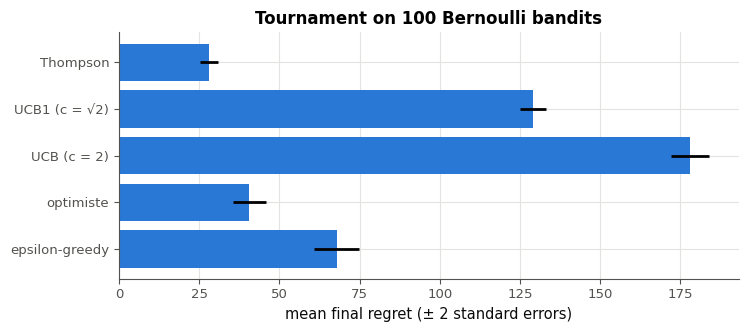

11.26a: 178.01429394028418
11.26b: 129.10076526903367
11.26c: Thompson
11.26d: False


In [55]:
POLICIES_26 = {
    "epsilon-greedy": (lambda q, n, t, g: mylearn.bandit.epsilon_greedy_action(q, 0.1, g), {}),
    "optimiste": (lambda q, n, t, g: mylearn.bandit.argmax_random_tie(q, g), {"initial_value": 1.0, "step_size": 0.1}),
    "UCB (c = 2)": (lambda q, n, t, g: mylearn.bandit.ucb_action(q, n, t, c=2.0), {}),
    "UCB1 (c = √2)": (lambda q, n, t, g: mylearn.bandit.ucb_action(q, n, t, c=math.sqrt(2)), {}),
    "Thompson": (lambda q, n, t, g: mylearn.bandit.thompson_action(np.rint(q * n), n - np.rint(q * n), g), {}),
}


def tournament_26(policies, n_bandits=100, seed=2613, n_steps=1000):
    """{name: (mean, standard error) of the final pseudo-regret} of every policy on make_bench(n_bandits, seed): a new
    bench for each policy, so that they all meet the same bandits and the same reward tapes. The policy receives,
    for bandit number i, the generator np.random.default_rng(i)."""
    scores = {}
    for name, (policy, run_kwargs) in policies.items():
        finals = [mylearn.bandit.run_bandit(bandit, policy, n_steps=n_steps, rng=np.random.default_rng(i),
                                            **run_kwargs)["regret"][-1]
                  for i, bandit in enumerate(make_bench(n_bandits, seed))]
        scores[name] = (float(np.mean(finals)), float(np.std(finals, ddof=1) / np.sqrt(len(finals))))
    return scores


best_26, ucb1_beats_eps_26 = "Thompson", False

if True:
    if filled(POLICIES_26):
        missing_26 = [name for name in NAMES_26 if name not in POLICIES_26]
        verdict("11.26", not missing_26, "les cinq agents du tournoi sont là.", f"il manque {missing_26} dans POLICIES_26.")
        start_26 = time.perf_counter()
        scores_26 = tournament_26(POLICIES_26, **BENCH_26)
        print(f"{BENCH_26['n_bandits']} bandits of 10 arms, 1,000 steps ({time.perf_counter() - start_26:.0f} s):")
        for name_26, (mean_26, se_26) in sorted(scores_26.items(), key=lambda item: item[1][0]):
            print(f"   {name_26:16s} mean final regret {mean_26:7.2f} ± {se_26:.2f}")
        names_26 = [name for name in scores_26 if name in NAMES_26]
        fig_26, ax_26 = plt.subplots(figsize=(8, 3.2))
        ax_26.barh(names_26, [scores_26[name][0] for name in names_26], xerr=[2 * scores_26[name][1] for name in names_26],
                   color="C0")
        ax_26.set(xlabel="mean final regret (± 2 standard errors)", title="Tournament on 100 Bernoulli bandits")
        plt.show()
        if "UCB (c = 2)" in scores_26:
            print_answer("11.26a", scores_26["UCB (c = 2)"][0], computed=True)
        if "UCB1 (c = √2)" in scores_26:
            print_answer("11.26b", scores_26["UCB1 (c = √2)"][0], computed=True)
    print_answer("11.26c", best_26)
    print_answer("11.26d", ucb1_beats_eps_26)

In [56]:
scores_ref_26 = tournament_26(POLICIES_26, **BENCH_26)
wb.record("11.26a", scores_ref_26["UCB (c = 2)"][0], decimals=0, mistakes={"c'est le regret d'UCB1 (c = √2) : on demande celui d'UCB avec c = 2": scores_ref_26["UCB1 (c = √2)"][0]})
wb.record("11.26b", scores_ref_26["UCB1 (c = √2)"][0], decimals=0, mistakes={"c'est le regret d'UCB avec c = 2 : on demande celui d'UCB1 (c = √2)": scores_ref_26["UCB (c = 2)"][0]})
wb.record("11.26c", best_26, mistakes={"UCB1 a une garantie théorique, mais lis le classement : son regret est loin d'être le plus petit": "UCB1 (c = √2)",
                                        "l'agent optimiste fait bien, mais un autre agent fait mieux sur ce banc": "optimiste"})
wb.record("11.26d", ucb1_beats_eps_26, mistakes={"compare les deux regrets moyens du classement : UCB1 explore beaucoup trop à cet horizon": True})

WB_ANSWER {"decimals": 0, "hash": "b7d2eb93739ad3827ea7f6a91895372cbfe5a7dbb12ff307d8b87f8fa7926488", "id": "11.26a", "kind": "float", "magnitude": 2, "mistakes": {"60c24b927887494e1b3e421c01da4b9139eda98a0580bee745b0582d391a79e4": "c'est le regret d'UCB1 (c = √2) : on demande celui d'UCB avec c = 2"}, "sign": 1}
📝 Ex 11.26a : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "hash": "7668e79b1a943f7b5c57d076a5e0d1ac071e80b30fb5846e2e8a1e24cdafcb03", "id": "11.26b", "kind": "float", "magnitude": 2, "mistakes": {"0a7ec9e8cb51d2b85353d3055ec14171e2c1af2c894d0425e6bafd35bd5f345a": "c'est le regret d'UCB avec c = 2 : on demande celui d'UCB1 (c = √2)"}, "sign": 1}
📝 Ex 11.26b : réponse enregistrée (float, 0 décimale(s)).
WB_ANSWER {"hash": "0874eaf06fdc72961c6a5f2741ad9549648ecbcbab1f30241729b8b22b57a5d9", "id": "11.26c", "kind": "str", "mistakes": {"aef923df3e62f0a733f69cc532302aae52eab6a6029beb96b4c285dba63d41fc": "UCB1 a une garantie théorique, mais lis le classement 

💡 Le classement, avec des erreurs types de 1,4 à 3,5 : Thompson (28,1), l'agent optimiste (40,7), ε-greedy (67,9), UCB1 (129,1), UCB avec $c = 2$ (178,0). Les écarts dépassent de loin les erreurs types : le classement est net. UCB1 perd contre ε-greedy parce que sa garantie, valable à tout horizon, est une borne **lâche** et prudente : avec $c = \sqrt{2}$, conçu pour toutes les lois à valeurs dans $[0, 1]$, le bonus $c\sqrt{\ln t / N}$ reste grand pendant des milliers de pas, et UCB1 continue de tirer des bras médiocres. Ce bonus vient d'une borne (l'inégalité de Hoeffding) valable pour toute loi à valeurs dans $[0, 1]$ : il est taillé pour le pire cas, avec une marge de sécurité, alors que beaucoup de bras de ce banc ont une moyenne proche de 0 ou de 1, donc une variance $p(1 - p)$ bien plus petite que le pire cas, 1/4. Sur 100 000 pas, le regret d'ε-greedy continuerait de croître linéairement (environ $\varepsilon \times$ l'écart moyen, 0,1 × 0,4 par pas), celui d'UCB1 seulement comme $\ln t$ : UCB1 finirait par passer devant. Thompson gagne sur tous les tableaux ici, parce que son prior, la loi uniforme, est **exactement** la loi des moyennes du banc. C'est la leçon de Domingos : une garantie théorique est une borne pour le pire cas, pas une prédiction de performance, et No Free Lunch rappelle que le classement dépend du banc.

### Ex 11.27 — Défi : battre UCB1 sur un banc de bandits de Bernoulli 🏆 ★★★ ⏱️ 60 min
**Objectif :** concevoir une stratégie d'exploration qui fait quatre fois moins de regret qu'UCB1, et la valider sans regarder le banc caché.  
**Prérequis :** Ex 11.26 · fiche §11.7 (encadré 🧮) · ch. 4 (posterior Beta) · ch. 8 (règle du test unique) · **Fil rouge :** bandit · **Parcours :** C

Le banc du défi ressemble à celui du tournoi : des bandits de Bernoulli à 10 bras, de moyennes tirées **uniformément** dans $[0, 1]$, joués pendant 1 000 pas. Ton agent est une politique `policy_27(q_values, counts, t, rng)` utilisée par **ta** `run_bandit`, avec les arguments `RUN_KWARGS_27` (par exemple une valeur initiale ou un pas constant). Il peut utiliser tout ce qu'il reçoit, le fait que l'horizon est de 1 000 pas et que les moyennes sont uniformes, mais rien d'autre (pas les moyennes des bras, ni les bandes de récompenses).

1. Écris `random_regret_27(bench)` : le regret final **attendu** d'un agent qui joue au hasard (uniformément) à chaque pas, en moyenne sur les bandits du banc, sans simulation : calcule-le à partir des moyennes de chaque bandit. C'est le niveau à battre : une stratégie qui apprend doit faire bien mieux.
2. Écris ta stratégie. Le point de départ fourni est ε-greedy ($\varepsilon = 0{,}1$).

La vérification contrôle :
a) le regret attendu d'un agent au hasard sur le banc public (100 bandits) ;
puis donne le regret de ta stratégie sur le banc **public**, comparé à celui d'UCB1 (127,25). Le banc **caché** (500 autres bandits) n'est révélé qu'**une fois** par session, quand tu mets `READY_27 = True` ; il faut environ 15 secondes.

**Objectif : sur le banc caché, un regret moyen au plus égal au quart de celui d'UCB1 (132,27), soit au plus 33,1.** 🌟 Palier : au plus un cinquième (26,5). Le point de départ n'y arrive pas. Pistes : la fiche (§11.7), le tournoi de 11.26, Lattimore et Szepesvári (« Pour aller plus loin »).

Dans tes notes : ta méthode, ses scores sur le banc public, puis sur le banc caché. Pourquoi faut-il choisir sa méthode sur le banc public seulement ? Si tu as réglé un paramètre (comme le $c$ d'UCB), comment as-tu évité de surapprendre le banc public ?

In [57]:
PUBLIC_27 = {"n_bandits": 100, "seed": 2701}     # for your trials: as often as you like
HIDDEN_27 = {"n_bandits": 500, "seed": 2799}     # revealed once per session (READY_27 = True)
UCB1_27 = {"public": 127.25, "hidden": 132.27}   # mean final regret of UCB1 (c = √2) on each bench (computed once)


def mean_regret_27(policy, run_kwargs, n_bandits, seed, n_steps=1000):
    """(mean, standard error) of the final pseudo-regret of a policy on make_bench(n_bandits, seed), with YOUR
    run_bandit; for bandit number i, the policy receives np.random.default_rng(i)."""
    finals = [mylearn.bandit.run_bandit(bandit, policy, n_steps=n_steps, rng=np.random.default_rng(i), **run_kwargs)["regret"][-1]
              for i, bandit in enumerate(make_bench(n_bandits, seed))]
    return float(np.mean(finals)), float(np.std(finals, ddof=1) / np.sqrt(len(finals)))


REVEALED_27 = {}


def grade_27(policy, run_kwargs, reveal=False):
    """The public bench at every call; the hidden bench once per session, when reveal is True."""
    mean, se = mean_regret_27(policy, run_kwargs, **PUBLIC_27)
    print(f"public bench (100 bandits): mean final regret {mean:.1f} ± {se:.1f}, "
          f"that is {mean / UCB1_27['public']:.0%} of UCB1's ({UCB1_27['public']})")
    if not reveal:
        print("the hidden bench (500 other bandits) is revealed once per session, when READY_27 = True")
        return
    if "hidden" in REVEALED_27:
        hidden_mean, hidden_se = REVEALED_27["hidden"]
        print(f"hidden bench already revealed in this session: {hidden_mean:.1f} ± {hidden_se:.1f} (frozen)")
        return
    start = time.perf_counter()
    REVEALED_27["hidden"] = hidden_mean, hidden_se = mean_regret_27(policy, run_kwargs, **HIDDEN_27)
    ratio = hidden_mean / UCB1_27["hidden"]
    print(f"hidden bench (500 bandits, {time.perf_counter() - start:.0f} s): mean final regret {hidden_mean:.1f} ± "
          f"{hidden_se:.1f}, that is {ratio:.0%} of UCB1's ({UCB1_27['hidden']})")
    verdict("11.27", ratio <= 0.25, "objectif atteint : au plus un quart du regret d'UCB1 sur le banc caché.",
            "objectif manqué sur le banc caché (au plus 25 % du regret d'UCB1) : retravaille ta méthode sur le banc "
            "public, sans plus regarder le banc caché.")
    if ratio <= 0.20:
        print("🌟 palier atteint : au plus un cinquième du regret d'UCB1.")

In [58]:
def random_regret_27(bench, n_steps=1000):
    """The EXPECTED final regret, averaged over the bandits of `bench`, of an agent that pulls an arm uniformly at
    random at every step (no simulation: use the means of each bandit)."""
    return float(np.mean([n_steps * (bandit.best_mean - np.mean(bandit.means)) for bandit in bench]))


def policy_27(q_values, counts, t, rng):
    """Your agent: (q_values, counts, t, rng) -> arm. Thompson sampling with the uniform prior (Beta(1, 1)), which
    is exactly the distribution of the means of the bench; the successes come back from the sample averages."""
    counts = np.asarray(counts)
    successes = np.rint(np.asarray(q_values) * counts)
    return mylearn.bandit.thompson_action(successes, counts - successes, rng)


RUN_KWARGS_27 = {}     # sample averages (step_size=None): q × n is the number of successes
READY_27 = True

if True:
    expected_random_27 = random_regret_27(make_bench(**PUBLIC_27))
    if returned("11.27", "random_regret_27", expected_random_27):
        print(f"an agent playing at random: expected regret {expected_random_27:.1f} on the public bench")
        print_answer("11.27a", expected_random_27, computed=True)

# your strategy, graded even if a) is not written yet
if True:
    grade_27(policy_27, RUN_KWARGS_27, reveal=READY_27)

an agent playing at random: expected regret 422.0 on the public bench
11.27a: 421.9657179065141


public bench (100 bandits): mean final regret 26.5 ± 1.2, that is 21% of UCB1's (127.25)


hidden bench (500 bandits, 11 s): mean final regret 29.2 ± 0.7, that is 22% of UCB1's (132.27)
✅ Ex 11.27 : objectif atteint : au plus un quart du regret d'UCB1 sur le banc caché.


In [59]:
wb.record("11.27a", random_regret_27(make_bench(**PUBLIC_27)), decimals=4,
          mistakes={"c'est le regret d'un seul pas : multiplie l'écart moyen par les 1 000 pas": random_regret_27(make_bench(**PUBLIC_27)) / 1000})

WB_ANSWER {"decimals": 4, "hash": "895c5c589eae71dcd56105018248ea82e5a7e537a99cb3950ce487cc35868bc0", "hash_coarse": "0dabe101d0e3673fd4c5f37bd00e8bd993cb88a17f5836841a5f2a35f9d816a4", "id": "11.27a", "kind": "float", "magnitude": 2, "mistakes": {"4cde1de8673e5dd4eb1b65d2c729767333e4da6069d6be789481087a9febef81": "c'est le regret d'un seul pas : multiplie l'écart moyen par les 1 000 pas"}, "sign": 1}
📝 Ex 11.27a : réponse enregistrée (float, 4 décimale(s)).


💡 Un agent au hasard perd en moyenne 422 sur le banc public : à chaque pas, l'écart entre le meilleur bras et la moyenne des 10 bras, qui vaut en espérance $10/11 - 1/2 \approx 0{,}409$ (l'espérance du maximum de 10 uniformes, moins 1/2), et 0,422 sur les 100 bandits de ce banc. Le corrigé est l'échantillonnage de Thompson avec le prior uniforme, la loi même des moyennes du banc : 26,5 sur le banc public (21 % d'UCB1) et 29,2 sur le banc caché (22 %) : objectif atteint. Pour le palier 🌟, il faut exploiter davantage : un UCB dont on règle $c$ (environ 0,3, choisi sur le banc public, fait 20,5 en public et 24,9 sur le banc caché, 19 %), ou des variantes bayésiennes comme Bayes-UCB, qui joue le quantile $1 - 1/t$ du posterior. Régler $c$ sur le banc public, c'est l'entraîner : avec 100 bandits, l'erreur type est d'environ 2, et un réglage trop fin colle au bruit du banc. On garde donc un réglage grossier, et le banc caché, comme un jeu de test, ne sert qu'une fois (ch. 8).

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu dire si un raisonnement est une déduction ou une induction, s'il est valide et s'il est solide, et le vérifier par un diagramme de Venn ou par force brute ?
2. Sais-tu repérer un échantillon trop petit ou biaisé, et dire ce que l'erreur type mesure et ce qu'elle ne mesure pas ?
3. Sais-tu programmer ε-greedy, UCB et Thompson, et les comparer équitablement par leur regret ?

**Pour aller plus loin** : le ch. 2 de Sutton et Barto (*Reinforcement Learning: An Introduction*, accès libre), cité dans la fiche, puis le tutoriel de Russo et coll. sur l'échantillonnage de Thompson. La suite : le checkpoint de la partie II, puis la partie III, qui commence au ch. 12 avec la préparation des données ; les bandits reviendront au ch. 26, dans l'apprentissage par renforcement.